In [ ]:
######################
# JUPYTER NOTEBOOK CODE
######################

import os
import re
import numpy as np
import pandas as pd
from datetime import datetime
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam

####################################################
# 1. SETUP MULTIPLE DATE-BASED CROPS
####################################################
# We define two cutoff dates:
#   - Older images: date < 2011-06-20 contain a white beam at the top.
#   - Middle images: 2011-06-20 <= date < 2016-06-05 already have desired proportions (1200×1000).
#   - New images: date >= 2016-06-05 need to have their white frame removed.

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

def parse_date_from_filename(filename):
    """
    Extracts the date from a filename like '20100222_AQUA.jpg'.
    Returns a datetime object or None if not found.
    """
    base = os.path.basename(filename)
    # Expect an 8-digit date at start of filename
    match = re.match(r'(\d{8})', base)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y%m%d')
    return None


from datetime import datetime

# Define the cutoff date for the new image format.
CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

def choose_crop_box(pil_img, file_date):
    """
    Returns a crop box (left, upper, right, lower) based on the file date.
    
    - For images dated before 2016-06-05:
        Crop a fixed region to remove the white beam at the top.
        Here, we remove 200 pixels from the top so that the cropped region is (0, 200, 1200, 1030),
        resulting in a final image of 1200×830.
    
    - For images dated on/after 2016-06-05:
        Remove 110px from the left, 272px from the top,
        437px from the right, and 113px from the bottom.
        This is computed dynamically based on the original image dimensions.
    """
    if file_date is None:
        return None  # if date cannot be parsed, don't crop
    
    w, h = pil_img.size  # original width and height
    
    if file_date < CUTOFF_NEW_FORMAT:
        # Crop for old/middle images (cutting 200px from the top)
        return (0, 200, 1200, 1030)
    else:
        # For new images, remove:
        # - 110px from left: left coordinate = 110
        # - 272px from top: upper coordinate = 272
        # - 437px from right: right coordinate = w - 437
        # - 113px from bottom: lower coordinate = h - 113
        return (110, 272, w - 437, h - 113)


def safe_crop(img, crop_box):
    """
    Crop the given PIL image using crop_box = (left, upper, right, lower), clamping to image size.
    """
    if crop_box is None:
        return img
    w, h = img.size
    left, upper, right, lower = crop_box
    left   = max(0, left)
    upper  = max(0, upper)
    right  = min(w, right)
    lower  = min(h, lower)
    if right <= left or lower <= upper:
        return img
    return img.crop((left, upper, right, lower))

def apply_date_based_crop(pil_img, file_date):
    """
    Converts the PIL image to RGB and applies the date-based crop.
    For images older than the cutoff, it crops with the chosen box (removing the top 200 pixels).
    For newer images, no cropping is applied.
    """
    pil_img = pil_img.convert("RGB")
    crop_box = choose_crop_box(pil_img, file_date)
    return safe_crop(pil_img, crop_box)

In [ ]:
####################################################
# 2. GATHER FILES (FROM FOLDERS: sea_ice, no_ice, cloudy)
####################################################
# We assume a folder structure under "data/train" with three subfolders.
# Each subfolder's name becomes the class label:
#   - sea_ice -> label 0
#   - no_ice   -> label 1
#   - cloudy   -> label 2

base_dir = "data/train"  # adjust this to your folder location
classes = ["sea_ice", "no_ice", "cloudy"]
label_map = {cls_name: i for i, cls_name in enumerate(classes)}

filepaths = []
labels = []

for cls_name in classes:
    cls_folder = os.path.join(base_dir, cls_name)
    for fname in os.listdir(cls_folder):
        if fname.lower().endswith((".jpg", ".png")):
            fp = os.path.join(cls_folder, fname)
            filepaths.append(fp)
            labels.append(label_map[cls_name])

# Build a DataFrame (for ease of viewing and train/val/test splits)
df = pd.DataFrame({"filepath": filepaths, "label": labels})
print("Found files:")
print(df.head())
print(df["label"].value_counts())

# Optional: Create train/val/test splits (here an 80/10/10 random split)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
n = len(df)
train_end = int(0.8 * n)
val_end   = int(0.9 * n)
df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]
print(f"Train size: {len(df_train)}")
print(f"Val size:   {len(df_val)}")
print(f"Test size:  {len(df_test)}")

In [ ]:
####################################################
# 3. DATE-BASED CROPPING FUNCTION + OPTIONAL FILTERS
####################################################
# (The cropping functions above handle the cropping logic for different date ranges.)
# If needed, you can also add functions like is_black_or_invalid() here.

def is_black_or_invalid(pil_img, black_threshold=10, black_ratio=0.8):
    """
    Check if the image is mostly black.
    Returns True if the ratio of pixels below the threshold is greater than black_ratio.
    """
    gray = np.array(pil_img.convert("L"))
    num_black = np.sum(gray < black_threshold)
    total = gray.size
    return (num_black / total) > black_ratio

In [ ]:
####################################################
# 4. DATA AUGMENTATION
####################################################
# We'll create a small Keras Sequential for augmentation.
# Because orientation might matter, we won't rotate too aggressively.
# Adjust to your domain knowledge.

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),        # +/- ~5%
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [ ]:
####################################################
# 5. TF DATASET PIPELINE
####################################################
# This function builds a tf.data.Dataset from a DataFrame.
# It loads images using our date-based cropping, resizes them, and applies augmentation.

IMG_SIZE = (224, 224)  # Final resize for model input

# Update load_and_preprocess to accept two arguments
def load_and_preprocess(filepath, label):
    # Convert TensorFlow string tensor to python string.
    filepath = filepath.numpy().decode("utf-8")
    label = label.numpy()
    file_date = parse_date_from_filename(filepath)
    with Image.open(filepath) as pil_img:
        cropped = apply_date_based_crop(pil_img, file_date)
        resized = cropped.resize(IMG_SIZE)
        arr = np.array(resized, dtype=np.float32) / 255.0
    return arr, label

# Update the dataset creation function:
def build_dataset_from_df(dataframe, batch_size=8, shuffle=True):
    # Extract filepaths and labels separately as lists.
    filepaths = dataframe["filepath"].tolist()
    labels = dataframe["label"].tolist()
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        # Use tf.py_function to run load_and_preprocess which takes fp and lbl separately.
        img, lbl_out = tf.py_function(
            func=load_and_preprocess,
            inp=[fp, lbl],
            Tout=(tf.float32, tf.int32)
        )
        # Set static shapes for the image and label.
        img.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
        lbl_out.set_shape(())
        augmented_img = data_augmentation(img)
        return augmented_img, lbl_out

    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

In [ ]:
####################################################
# 6. TESTING THE CROPPING IN JUPYTER
####################################################
# This function displays a sample of images after date-based cropping.
import matplotlib.pyplot as plt

def show_sample_crops(dataframe, num=5):
    sample_df = dataframe.sample(n=num, random_state=42)
    fig, axes = plt.subplots(1, num, figsize=(5 * num, 5))
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        fp = row["filepath"]
        lbl = row["label"]
        dt = parse_date_from_filename(fp)
        with Image.open(fp) as pil_img:
            # Get the cropped image based on its date.
            cropped = apply_date_based_crop(pil_img, dt)
        cropped_arr = np.array(cropped)
        axes[i].imshow(cropped_arr)
        date_str = dt.strftime('%Y-%m-%d') if dt else '??'
        axes[i].set_title(f"Label: {lbl}\n{date_str}")
        axes[i].axis("off")
    
    plt.show()

# Run the display function to verify the crop:
show_sample_crops(df.sample(5), num=5)


In [ ]:
####################################################
# 7. BUILD & TRAIN THE MODEL
####################################################
# We use a pretrained EfficientNetB0 for a 3-class classification (sea_ice, no_ice, cloudy).
def build_efficientnet_model(input_shape=(224,224,3), num_classes=3):
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # Freeze the base for initial training
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

sea_ice_model = build_efficientnet_model(input_shape=(224,224,3), num_classes=3)

# Build train/validation/test datasets:
train_ds = build_dataset_from_df(df_train, batch_size=8, shuffle=True)
val_ds   = build_dataset_from_df(df_val, batch_size=8, shuffle=False)
test_ds  = build_dataset_from_df(df_test, batch_size=8, shuffle=False)

# Train the model:
history = sea_ice_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Evaluate the model on the test set:
test_loss, test_acc = sea_ice_model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.3f}")



In [ ]:
####################################################
# 8. OPTIONAL: INSPECT PREDICTIONS & CONFUSION MATRIX
####################################################
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

all_labels = []
all_preds = []

for images, labels in test_ds:
    preds = sea_ice_model.predict(images)
    preds_class = np.argmax(preds, axis=1)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds_class)

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))


In [ ]:
######################
# JUPYTER NOTEBOOK CODE
######################

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping

#############################################
# 1) DATE-BASED CROPPING
#############################################

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

def parse_date_from_filename(filename):
    """
    Extract date from 'YYYYMMDD...' (e.g., '20100222_AQUA.jpg').
    Return datetime or None if not found.
    """
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y%m%d')
    return None

def choose_crop_box(w, h, file_date):
    """
    Decide the bounding box for cropping depending on date:
      - If date < 2016-06-05 => older images => (0,200,1200,1030)
      - Else => newer images => remove 110 left, 272 top, 437 right, 113 bottom
    """
    if file_date is None:
        return None

    if file_date < CUTOFF_NEW_FORMAT:
        # older images => final 1200×830
        return (0, 200, 1200, 1030)
    else:
        # newer images => dynamic
        left   = 110
        top    = 272
        right  = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    """
    Convert to RGB, figure out which crop box, then crop the image.
    Return the cropped PIL image.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

#############################################
# 2) MASK LOADING (WATER=WHITE, LAND=BLACK)
#############################################

def load_water_mask(mask_path, final_size=(224,224)):
    """
    Loads a grayscale mask image where:
      - 255 => water
      - 0   => land
    Scales to [0,1]. No cropping needed if it's already pre-cropped.
    """
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
        return mask_arr
    # shape => (224,224), 1.0=water, 0.0=land

#############################################
# 3) TWO-STEP DATA (CLOUDY vs CLEAR; ICE vs NO_ICE)
#############################################

def build_two_step_data(base_dir="data/train"):
    """
    We have subfolders: sea_ice, no_ice, cloudy (each ~105 images).
    => df_cloud: label=1 if cloudy, else 0 (clear)
       df_ice:   label=0 if sea_ice, 1 if no_ice
    """
    subfolders = ["sea_ice", "no_ice", "cloudy"]
    cloud_paths, cloud_labels = [], []
    ice_paths, ice_labels = [], []
    
    for sf in subfolders:
        folder_path = os.path.join(base_dir, sf)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith((".jpg", ".png")):
                fp = os.path.join(folder_path, fname)
                
                # cloud dataset
                if sf == "cloudy":
                    cloud_paths.append(fp)
                    cloud_labels.append(1)
                else:
                    cloud_paths.append(fp)
                    cloud_labels.append(0)
                
                # ice dataset
                if sf == "sea_ice":
                    ice_paths.append(fp)
                    ice_labels.append(0)
                elif sf == "no_ice":
                    ice_paths.append(fp)
                    ice_labels.append(1)
                else:
                    pass
    
    df_cloud = pd.DataFrame({"filepath": cloud_paths, "label": cloud_labels})
    df_ice   = pd.DataFrame({"filepath": ice_paths,   "label": ice_labels})
    return df_cloud, df_ice

def split_df(df, frac_train=0.8, frac_val=0.1):
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(df)
    n_train = int(frac_train*n)
    n_val   = int(frac_val*n)
    df_train = df.iloc[:n_train]
    df_val   = df.iloc[n_train:n_train+n_val]
    df_test  = df.iloc[n_train+n_val:]
    return df_train, df_val, df_test

#############################################
# 4) DATASET PIPELINE
#############################################

IMG_SIZE = (224,224)

def load_and_preprocess(filepath, label, water_mask, apply_mask=False):
    """
    1) Date-based crop
    2) Resize to (224,224)
    3) Convert to array, scale [0,1]
    4) If apply_mask=True => multiply by water_mask to zero out land
    """
    filepath = filepath.numpy().decode("utf-8")
    label = label.numpy()
    file_date = parse_date_from_filename(filepath)
    
    with Image.open(filepath) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        
        if apply_mask and water_mask is not None:
            # water_mask: shape (224,224) with 1=water,0=land
            mask_3d = np.expand_dims(water_mask, axis=-1)  # => (224,224,1)
            arr = arr * mask_3d  # zero out land
    return arr, label

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

def build_dataset(df, water_mask, batch_size=8, shuffle=True, apply_mask=False):
    filepaths = df["filepath"].tolist()
    labels    = df["label"].tolist()
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        img, lbl_out = tf.py_function(
            func=load_and_preprocess,
            inp=[fp, lbl, water_mask, apply_mask],
            Tout=(tf.float32, tf.int32)
        )
        img.set_shape((224,224,3))
        lbl_out.set_shape(())
        # Augment
        img = data_augmentation(img)
        return img, lbl_out
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

#############################################
# 5) MODEL BUILDING (EfficientNetV2S)
#############################################

def build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True):
    base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    if not fine_tune:
        base.trainable = False
    else:
        # partial unfreeze
        unfreeze_from = len(base.layers)//2
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False
        for layer in base.layers[unfreeze_from:]:
            layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

#############################################
# 6) OPTIONAL: CLASSICAL THRESHOLD
#############################################

def classical_color_threshold(filepath, water_mask=None, ice_thresh=2.0):
    """
    Example function to do a naive threshold:
    - If sum(RGB) > ice_thresh => label=1 (ice or cloud)
    - Else => label=0
    If water_mask is provided => zero out land first.
    """
    file_date = parse_date_from_filename(filepath)
    with Image.open(filepath) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
        sums = arr.sum(axis=-1)  # shape (224,224)
        # ice_mask => bright = 1
        ice_mask = (sums > ice_thresh).astype(np.uint8)
        return ice_mask

#############################################
# 7) MAIN ORCHESTRATION
#############################################

def main():
    # 1) Two-step data
    df_cloud, df_ice = build_two_step_data("data/train")
    df_cloud_train, df_cloud_val, df_cloud_test = split_df(df_cloud)
    df_ice_train,   df_ice_val,   df_ice_test   = split_df(df_ice)

    # 2) Load water mask
    mask_path = "data/satellite/aqua/mask/mask_AQUA.jpg"
    water_mask = load_water_mask(mask_path, final_size=(224,224))

    # 3) Build datasets for cloud vs. clear
    train_cloud_ds = build_dataset(df_cloud_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_cloud_ds   = build_dataset(df_cloud_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_cloud_ds  = build_dataset(df_cloud_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    # 4) Train cloud model
    cloud_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    cloud_model.fit(
        train_cloud_ds,
        validation_data=val_cloud_ds,
        epochs=40,
        callbacks=[early_stop]
    )
    print("Cloud model test result:")
    cloud_model.evaluate(test_cloud_ds)

    # 5) Build datasets for ice model (sea_ice vs. no_ice)
    train_ice_ds = build_dataset(df_ice_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_ice_ds   = build_dataset(df_ice_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_ice_ds  = build_dataset(df_ice_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    # 6) Train ice model
    ice_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    ice_model.fit(
        train_ice_ds,
        validation_data=val_ice_ds,
        epochs=20,
        callbacks=[early_stop]
    )
    print("Ice model test result:")
    ice_model.evaluate(test_ice_ds)

    # 7) Example classical threshold usage
    example_img = "data/satellite/aqua/2019/20190214_AQUA.jpg"
    thresholded = classical_color_threshold(example_img, water_mask=water_mask, ice_thresh=2.0)
    plt.imshow(thresholded, cmap='gray')
    plt.title("Classical Threshold (white=ice/cloud, black=water/land)")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()


In [ ]:
#############################
# FULL CODE EXAMPLE
#############################

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping

# For evaluation & confusion matrices:
from sklearn.metrics import confusion_matrix, classification_report

##########################################
# 1) DATE-BASED CROPPING FUNCTIONS
##########################################

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

def parse_date_from_filename(filename):
    """
    Extract date from 'YYYYMMDD...' in filename, e.g. '20100222_AQUA.jpg'.
    Return a datetime object or None if not found.
    """
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y%m%d')
    return None

def choose_crop_box(w, h, file_date):
    """
    Return the crop box (left, upper, right, lower) based on the date.
      - If date < 2016-06-05 => older images => (0,200,1200,1030)
      - Else => new images => remove 110 left, 272 top, 437 right, 113 bottom
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)  # yields final 1200x830
    else:
        left   = 110
        top    = 272
        right  = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    """
    Convert to RGB, figure out which crop box, then crop.
    Returns the cropped PIL image.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

##########################################
# 2) LOADING & APPLYING THE WATER MASK
##########################################

def load_water_mask(mask_path, final_size=(224,224)):
    """
    Loads a mask image (grayscale) where water=255 (white) and land=0 (black).
    Resizes to final_size and scales to [0,1].
    """
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
        return mask_arr

##########################################
# 3) TWO-STEP DATA: CLOUD & ICE
##########################################

def build_two_step_data(base_dir="data/train"):
    """
    We assume subfolders: 'sea_ice', 'no_ice', 'cloudy'.
    => df_cloud: label=1 if 'cloudy', else 0
       df_ice: label=0 if 'sea_ice', 1 if 'no_ice'
    """
    subfolders = ["sea_ice", "no_ice", "cloudy"]
    cloud_paths, cloud_labels = [], []
    ice_paths,   ice_labels   = [], []
    
    for sf in subfolders:
        folder_path = os.path.join(base_dir, sf)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith((".jpg", ".png")):
                fp = os.path.join(folder_path, fname)
                # Cloud dataset
                if sf == "cloudy":
                    cloud_paths.append(fp)
                    cloud_labels.append(1)
                else:
                    cloud_paths.append(fp)
                    cloud_labels.append(0)
                
                # Ice dataset
                if sf == "sea_ice":
                    ice_paths.append(fp)
                    ice_labels.append(0)
                elif sf == "no_ice":
                    ice_paths.append(fp)
                    ice_labels.append(1)
                else:
                    pass
    
    df_cloud = pd.DataFrame({"filepath": cloud_paths, "label": cloud_labels})
    df_ice   = pd.DataFrame({"filepath": ice_paths,   "label": ice_labels})
    return df_cloud, df_ice

def split_df(df, frac_train=0.8, frac_val=0.1):
    """
    Shuffle df, then split into train/val/test.
    """
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(df)
    n_train = int(frac_train*n)
    n_val   = int(frac_val*n)
    df_train = df.iloc[:n_train]
    df_val   = df.iloc[n_train:n_train+n_val]
    df_test  = df.iloc[n_train+n_val:]
    return df_train, df_val, df_test

##########################################
# 4) DATASET PIPELINE & AUGMENTATION
##########################################

IMG_SIZE = (224,224)

def load_and_preprocess(filepath, label, water_mask, apply_mask=False):
    """
    1) Date-based crop
    2) Resize to (224,224)
    3) Convert to array, scale [0,1]
    4) If apply_mask => multiply by water_mask => zero out land
    """
    filepath = filepath.numpy().decode("utf-8")
    label = label.numpy()
    file_date = parse_date_from_filename(filepath)
    
    with Image.open(filepath) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        
        if apply_mask and water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)  # (224,224,1)
            arr = arr * mask_3d
    return arr, label

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

def build_dataset(df, water_mask, batch_size=8, shuffle=True, apply_mask=False):
    filepaths = df["filepath"].tolist()
    labels    = df["label"].tolist()
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        img, lbl_out = tf.py_function(
            func=load_and_preprocess,
            inp=[fp, lbl, water_mask, apply_mask],
            Tout=(tf.float32, tf.int32)
        )
        img.set_shape((224,224,3))
        lbl_out.set_shape(())
        
        # apply augmentation
        img = data_augmentation(img)
        return img, lbl_out
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

##########################################
# 5) MODEL BUILDING (EfficientNetV2S)
##########################################

def build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True):
    base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    if not fine_tune:
        base.trainable = False
    else:
        # partial unfreeze
        unfreeze_from = len(base.layers)//2
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False
        for layer in base.layers[unfreeze_from:]:
            layer.trainable = True
    
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

##########################################
# 6) EVALUATION & VISUALIZATION UTILS
##########################################

def evaluate_model_on_test(model, test_ds, class_names):
    """
    Prints confusion matrix & classification report 
    on the test dataset.
    """
    all_labels = []
    all_preds = []
    for images, labels in test_ds:
        preds = model.predict(images)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", 
          classification_report(all_labels, all_preds, target_names=class_names))

def classify_new_image(image_path, cloud_model, ice_model, water_mask):
    """
    1) Crop & resize image
    2) Optionally apply water_mask
    3) Use cloud_model => predict (0=clear,1=cloudy)
    4) If clear => use ice_model => predict (0=sea_ice,1=no_ice)
    Return final string label: 'cloudy','sea_ice','no_ice'
    """
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        arr = arr * mask_3d
    
    inp = np.expand_dims(arr, axis=0)  # (1,224,224,3)
    cloud_preds = cloud_model.predict(inp)
    cloud_label = np.argmax(cloud_preds, axis=1)[0]  # 0=clear,1=cloudy
    if cloud_label == 1:
        return "cloudy"
    else:
        # clear => ice/no_ice
        ice_preds = ice_model.predict(inp)
        ice_label = np.argmax(ice_preds, axis=1)[0]  # 0=sea_ice,1=no_ice
        return "sea_ice" if ice_label==0 else "no_ice"

def visualize_prediction(image_path, cloud_model, ice_model, water_mask):
    """
    Show the (cropped) image and the predicted label.
    """
    label = classify_new_image(image_path, cloud_model, ice_model, water_mask)
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
    plt.figure(figsize=(6,6))
    plt.imshow(cropped)
    plt.title(f"Predicted: {label}")
    plt.axis('off')
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    """
    Show side by side:
      1) The cropped image
      2) The mask
      3) The masked image
    """
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        masked_arr = arr * mask_3d

    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(arr)
    axs[0].set_title("Cropped image")
    axs[0].axis('off')
    axs[1].imshow(water_mask, cmap='gray')
    axs[1].set_title("Water Mask")
    axs[1].axis('off')
    axs[2].imshow(masked_arr)
    axs[2].set_title("Image * Mask")
    axs[2].axis('off')
    plt.show()

##########################################
# 7) OPTIONAL CLASSICAL THRESHOLD 
#    (IF DESIRED)
##########################################

def classical_color_threshold(image_path, water_mask=None, ice_thresh=2.0):
    """
    1) Date-based crop + resize
    2) scale [0,1]
    3) apply mask if desired
    4) sum(RGB)
    5) if sum>ice_thresh => 1=ice, else 0=water
    """
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
        sums = arr.sum(axis=-1)
        ice_mask = (sums > ice_thresh).astype(np.uint8)
        return ice_mask

##########################################
# 8) MAIN ORCHESTRATION
##########################################

def main():
    # Build the 2-step data
    df_cloud, df_ice = build_two_step_data("data/train")
    df_cloud_train, df_cloud_val, df_cloud_test = split_df(df_cloud)
    df_ice_train, df_ice_val, df_ice_test       = split_df(df_ice)

    # Load water mask
    mask_path = "data/satellite/aqua/mask/mask_AQUA.jpg"
    water_mask = load_water_mask(mask_path, final_size=(224,224))

    # Build the Cloud datasets
    train_cloud_ds = build_dataset(df_cloud_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_cloud_ds   = build_dataset(df_cloud_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_cloud_ds  = build_dataset(df_cloud_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    # Build + train Cloud model
    cloud_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    cloud_model.fit(
        train_cloud_ds,
        validation_data=val_cloud_ds,
        epochs=20,
        callbacks=[early_stop]
    )
    print("Cloud model test result:")
    cloud_model.evaluate(test_cloud_ds)

    # Evaluate with confusion matrix
    evaluate_model_on_test(cloud_model, test_cloud_ds, class_names=["clear","cloudy"])

    # Build the Ice datasets
    train_ice_ds = build_dataset(df_ice_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_ice_ds   = build_dataset(df_ice_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_ice_ds  = build_dataset(df_ice_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    # Build + train Ice model
    ice_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    ice_model.fit(
        train_ice_ds,
        validation_data=val_ice_ds,
        epochs=20,
        callbacks=[early_stop]
    )
    print("Ice model test result:")
    ice_model.evaluate(test_ice_ds)

    # Evaluate with confusion matrix
    evaluate_model_on_test(ice_model, test_ice_ds, class_names=["sea_ice","no_ice"])

        # Example: see how the mask lines up on a random image
    example_path = "data/satellite/aqua/2012/20120312_AQUA.jpg"
    visualize_mask_alignment(example_path, water_mask)

    # Example: see how the mask lines up on a random image
    example_path = "data/satellite/aqua/2020/20200410_AQUA.jpg"
    visualize_mask_alignment(example_path, water_mask)

    # Example: run the full classification pipeline
    predicted_label = classify_new_image(example_path, cloud_model, ice_model, water_mask)
    print(f"Prediction for {example_path} => {predicted_label}")

    # Example: visualize the prediction
    visualize_prediction(example_path, cloud_model, ice_model, water_mask)

    # Example: classical threshold
    thresh_map = classical_color_threshold(example_path, water_mask=water_mask, ice_thresh=2.0)
    plt.imshow(thresh_map, cmap='gray')
    plt.title("Classical Threshold: White=Ice, Black=Water")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()


In [ ]:
#############################
# FULL CODE EXAMPLE
#############################

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping

# For evaluation & confusion matrices:
from sklearn.metrics import confusion_matrix, classification_report

##########################################
# 1) DATE-BASED CROPPING FUNCTIONS
##########################################

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

def parse_date_from_filename(filename):
    """
    Extract date from 'YYYYMMDD...' in filename, e.g. '20100222_AQUA.jpg'.
    Return a datetime object or None if not found.
    """
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y%m%d')
    return None

def choose_crop_box(w, h, file_date):
    """
    Return the crop box (left, upper, right, lower) based on the date.
      - If date < 2016-06-05 => older images => (0,200,1200,1030)
      - Else => new images => remove 110 left, 272 top, 437 right, 113 bottom
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)  # yields final 1200x830
    else:
        left   = 110
        top    = 272
        right  = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    """
    Convert to RGB, figure out which crop box, then crop.
    Returns the cropped PIL image.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

##########################################
# 2) LOADING & APPLYING THE WATER MASK
##########################################

def load_water_mask(mask_path, final_size=(224,224)):
    """
    Loads a mask image (grayscale) where water=255 (white) and land=0 (black).
    Resizes to final_size and scales to [0,1].
    """
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
        return mask_arr

##########################################
# 3) TWO-STEP DATA: CLOUD & ICE
##########################################

def build_two_step_data(base_dir="data/train"):
    """
    We assume subfolders: 'sea_ice', 'no_ice', 'cloudy'.
    => df_cloud: label=1 if 'cloudy', else 0
       df_ice: label=0 if 'sea_ice', 1 if 'no_ice'
    """
    subfolders = ["sea_ice", "no_ice", "cloudy"]
    cloud_paths, cloud_labels = [], []
    ice_paths,   ice_labels   = [], []
    
    for sf in subfolders:
        folder_path = os.path.join(base_dir, sf)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith((".jpg", ".png")):
                fp = os.path.join(folder_path, fname)
                # Cloud dataset
                if sf == "cloudy":
                    cloud_paths.append(fp)
                    cloud_labels.append(1)
                else:
                    cloud_paths.append(fp)
                    cloud_labels.append(0)
                
                # Ice dataset
                if sf == "sea_ice":
                    ice_paths.append(fp)
                    ice_labels.append(0)
                elif sf == "no_ice":
                    ice_paths.append(fp)
                    ice_labels.append(1)
                else:
                    pass
    
    df_cloud = pd.DataFrame({"filepath": cloud_paths, "label": cloud_labels})
    df_ice   = pd.DataFrame({"filepath": ice_paths,   "label": ice_labels})
    return df_cloud, df_ice

def split_df(df, frac_train=0.8, frac_val=0.1):
    """
    Shuffle df, then split into train/val/test.
    """
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(df)
    n_train = int(frac_train*n)
    n_val   = int(frac_val*n)
    df_train = df.iloc[:n_train]
    df_val   = df.iloc[n_train:n_train+n_val]
    df_test  = df.iloc[n_train+n_val:]
    return df_train, df_val, df_test

##########################################
# 4) DATASET PIPELINE & AUGMENTATION
##########################################

IMG_SIZE = (224,224)

def load_and_preprocess(filepath, label, water_mask, apply_mask=False):
    """
    1) Date-based crop
    2) Resize to (224,224)
    3) Convert to array, scale [0,1]
    4) If apply_mask => multiply by water_mask => zero out land
    """
    filepath = filepath.numpy().decode("utf-8")
    label = label.numpy()
    file_date = parse_date_from_filename(filepath)
    
    with Image.open(filepath) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        
        if apply_mask and water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)  # (224,224,1)
            arr = arr * mask_3d
    return arr, label

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

def build_dataset(df, water_mask, batch_size=8, shuffle=True, apply_mask=False):
    filepaths = df["filepath"].tolist()
    labels    = df["label"].tolist()
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        img, lbl_out = tf.py_function(
            func=load_and_preprocess,
            inp=[fp, lbl, water_mask, apply_mask],
            Tout=(tf.float32, tf.int32)
        )
        img.set_shape((224,224,3))
        lbl_out.set_shape(())
        
        # apply augmentation
        img = data_augmentation(img)
        return img, lbl_out
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

##########################################
# 5) MODEL BUILDING (EfficientNetV2S)
##########################################

def build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True):
    base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    if not fine_tune:
        base.trainable = False
    else:
        # partial unfreeze
        unfreeze_from = len(base.layers)//2
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False
        for layer in base.layers[unfreeze_from:]:
            layer.trainable = True
    
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

##########################################
# 6) EVALUATION & VISUALIZATION UTILS
##########################################

def evaluate_model_on_test(model, test_ds, class_names):
    """
    Prints confusion matrix & classification report 
    on the test dataset.
    """
    all_labels = []
    all_preds = []
    for images, labels in test_ds:
        preds = model.predict(images)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", 
          classification_report(all_labels, all_preds, target_names=class_names))

def classify_new_image(image_path, cloud_model, ice_model, water_mask):
    """
    1) Crop & resize image
    2) Optionally apply water_mask
    3) Use cloud_model => predict (0=clear,1=cloudy)
    4) If clear => use ice_model => predict (0=sea_ice,1=no_ice)
    Return final string label: 'cloudy','sea_ice','no_ice'
    """
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        arr = arr * mask_3d
    
    inp = np.expand_dims(arr, axis=0)  # (1,224,224,3)
    cloud_preds = cloud_model.predict(inp)
    cloud_label = np.argmax(cloud_preds, axis=1)[0]  # 0=clear,1=cloudy
    if cloud_label == 1:
        return "cloudy"
    else:
        # clear => ice/no_ice
        ice_preds = ice_model.predict(inp)
        ice_label = np.argmax(ice_preds, axis=1)[0]  # 0=sea_ice,1=no_ice
        return "sea_ice" if ice_label==0 else "no_ice"

def visualize_prediction(image_path, cloud_model, ice_model, water_mask):
    """
    Show the (cropped) image and the predicted label.
    """
    label = classify_new_image(image_path, cloud_model, ice_model, water_mask)
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
    plt.figure(figsize=(6,6))
    plt.imshow(cropped)
    plt.title(f"Predicted: {label}")
    plt.axis('off')
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    """
    Show side by side:
      1) The cropped image
      2) The mask
      3) The masked image
    """
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        masked_arr = arr * mask_3d

    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(arr)
    axs[0].set_title("Cropped image")
    axs[0].axis('off')
    axs[1].imshow(water_mask, cmap='gray')
    axs[1].set_title("Water Mask")
    axs[1].axis('off')
    axs[2].imshow(masked_arr)
    axs[2].set_title("Image * Mask")
    axs[2].axis('off')
    plt.show()

##########################################
# 7) OPTIONAL CLASSICAL THRESHOLD 
#    (IF DESIRED)
##########################################

def classical_color_threshold(image_path, water_mask=None, ice_thresh=2.0):
    """
    1) Date-based crop + resize
    2) scale [0,1]
    3) apply mask if desired
    4) sum(RGB)
    5) if sum>ice_thresh => 1=ice, else 0=water
    """
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
        sums = arr.sum(axis=-1)
        ice_mask = (sums > ice_thresh).astype(np.uint8)
        return ice_mask

##########################################
# 8) MAIN ORCHESTRATION
##########################################

def main():
    # Build the 2-step data
    df_cloud, df_ice = build_two_step_data("data/train")
    df_cloud_train, df_cloud_val, df_cloud_test = split_df(df_cloud)
    df_ice_train, df_ice_val, df_ice_test       = split_df(df_ice)

    # Load water mask
    mask_path = "data/satellite/aqua/mask/mask_AQUA.jpg"
    water_mask = load_water_mask(mask_path, final_size=(224,224))

    # Build the Cloud datasets
    train_cloud_ds = build_dataset(df_cloud_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_cloud_ds   = build_dataset(df_cloud_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_cloud_ds  = build_dataset(df_cloud_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    # Build + train Cloud model
    cloud_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    cloud_model.fit(
        train_cloud_ds,
        validation_data=val_cloud_ds,
        epochs=50,
        callbacks=[early_stop]
    )
    print("Cloud model test result:")
    cloud_model.evaluate(test_cloud_ds)

    # Evaluate with confusion matrix
    evaluate_model_on_test(cloud_model, test_cloud_ds, class_names=["clear","cloudy"])

    # Build the Ice datasets
    train_ice_ds = build_dataset(df_ice_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_ice_ds   = build_dataset(df_ice_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_ice_ds  = build_dataset(df_ice_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    # Build + train Ice model
    ice_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    ice_model.fit(
        train_ice_ds,
        validation_data=val_ice_ds,
        epochs=20,
        callbacks=[early_stop]
    )
    print("Ice model test result:")
    ice_model.evaluate(test_ice_ds)

    # Evaluate with confusion matrix
    evaluate_model_on_test(ice_model, test_ice_ds, class_names=["sea_ice","no_ice"])

        # Example: see how the mask lines up on a random image
    example_path = "data/satellite/aqua/2012/20120312_AQUA.jpg"
    visualize_mask_alignment(example_path, water_mask)

    # Example: see how the mask lines up on a random image
    example_path = "data/satellite/aqua/2020/20200410_AQUA.jpg"
    visualize_mask_alignment(example_path, water_mask)

    # Example: run the full classification pipeline
    predicted_label = classify_new_image(example_path, cloud_model, ice_model, water_mask)
    print(f"Prediction for {example_path} => {predicted_label}")

    # Example: visualize the prediction
    visualize_prediction(example_path, cloud_model, ice_model, water_mask)

    # Example: classical threshold
    thresh_map = classical_color_threshold(example_path, water_mask=water_mask, ice_thresh=2.0)
    plt.imshow(thresh_map, cmap='gray')
    plt.title("Classical Threshold: White=Ice, Black=Water")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()


In [ ]:
#############################
# FULL CODE EXAMPLE WITH KEYPOINT ALIGNMENT
#############################

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping

# For evaluation & confusion matrices:
from sklearn.metrics import confusion_matrix, classification_report

##########################################
# 1) KEYPOINT ALIGNMENT FOR OLDER IMAGES
##########################################
import cv2

def align_old_image_to_ref(old_path, ref_path, max_features=2000, good_match_ratio=0.75):
    """
    Aligns 'old_path' image to match geometry of 'ref_path' image using:
      - ORB keypoints
      - BFMatcher
      - Homography (RANSAC)
    
    Returns:
      aligned_bgr: The old image warped to the ref image geometry (OpenCV BGR array).
      H: 3x3 homography from old->ref.
    Raises:
      ValueError if insufficient matches or homography fails.
    """
    # 1) Read both images in grayscale for feature detection
    ref_gray = cv2.imread(ref_path, cv2.IMREAD_GRAYSCALE)
    old_gray = cv2.imread(old_path, cv2.IMREAD_GRAYSCALE)
    if ref_gray is None or old_gray is None:
        raise IOError(f"Could not read ref={ref_path} or old={old_path}")

    # 2) Detect ORB keypoints
    orb = cv2.ORB_create(nfeatures=max_features)
    kp_ref, des_ref = orb.detectAndCompute(ref_gray, None)
    kp_old, des_old = orb.detectAndCompute(old_gray, None)

    # 3) Match with BFMatcher (KNN => ratio test)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw_matches = matcher.knnMatch(des_ref, des_old, k=2)

    # 4) Ratio test
    good = []
    for m,n in raw_matches:
        if m.distance < good_match_ratio*n.distance:
            good.append(m)

    MIN_MATCH_COUNT = 10
    if len(good) < MIN_MATCH_COUNT:
        raise ValueError(f"Insufficient matches: {len(good)} < {MIN_MATCH_COUNT}")

    ref_pts = np.float32([ kp_ref[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    old_pts = np.float32([ kp_old[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

    # 5) Homography
    H, mask = cv2.findHomography(old_pts, ref_pts, cv2.RANSAC, 5.0)
    if H is None:
        raise ValueError("Homography failed")

    # 6) Warp old -> ref geometry
    h_ref, w_ref = ref_gray.shape[:2]
    old_bgr = cv2.imread(old_path, cv2.IMREAD_COLOR)  # BGR
    aligned_bgr = cv2.warpPerspective(old_bgr, H, (w_ref, h_ref), flags=cv2.INTER_LINEAR)
    return aligned_bgr, H

def warp_mask_to_ref(old_mask_path, H, ref_shape):
    """
    Warps a grayscale mask from the 'old' geometry to the 'ref' geometry,
    using the same homography H from old->ref.
    
    Args:
      old_mask_path: path to the mask image aligned with the old image
      H: homography from old->ref
      ref_shape: (height, width) of the reference image

    Returns:
      warped_mask: shape ref_shape, grayscale
    """
    mask_gray = cv2.imread(old_mask_path, cv2.IMREAD_GRAYSCALE)
    if mask_gray is None:
        raise IOError(f"Could not read mask: {old_mask_path}")
    h_ref, w_ref = ref_shape
    warped_mask = cv2.warpPerspective(mask_gray, H, (w_ref, h_ref), flags=cv2.INTER_NEAREST)
    return warped_mask

##########################################
# 2) DATE-BASED CROPPING FUNCTIONS
##########################################

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

def parse_date_from_filename(filename):
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y%m%d')
    return None

def choose_crop_box(w, h, file_date):
    """
    If date < 2016-06-05 => older => (0,200,1200,1030),
    else => newer => remove (110,272,437,113).
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)
    else:
        left   = 110
        top    = 272
        right  = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

##########################################
# 3) LOADING & APPLYING THE WATER MASK
##########################################

def load_water_mask(mask_path, final_size=(224,224)):
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
        return mask_arr

##########################################
# 4) TWO-STEP DATA: CLOUD & ICE
##########################################

def build_two_step_data(base_dir="data/train"):
    subfolders = ["sea_ice", "no_ice", "cloudy"]
    cloud_paths, cloud_labels = [], []
    ice_paths, ice_labels = [], []
    
    for sf in subfolders:
        folder_path = os.path.join(base_dir, sf)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith((".jpg", ".png")):
                fp = os.path.join(folder_path, fname)
                # cloud data
                if sf == "cloudy":
                    cloud_paths.append(fp)
                    cloud_labels.append(1)
                else:
                    cloud_paths.append(fp)
                    cloud_labels.append(0)
                # ice data
                if sf == "sea_ice":
                    ice_paths.append(fp)
                    ice_labels.append(0)
                elif sf == "no_ice":
                    ice_paths.append(fp)
                    ice_labels.append(1)
                else:
                    pass
    
    df_cloud = pd.DataFrame({"filepath": cloud_paths, "label": cloud_labels})
    df_ice   = pd.DataFrame({"filepath": ice_paths,   "label": ice_labels})
    return df_cloud, df_ice

def split_df(df, frac_train=0.8, frac_val=0.1):
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(df)
    n_train = int(frac_train*n)
    n_val   = int(frac_val*n)
    df_train = df.iloc[:n_train]
    df_val   = df.iloc[n_train:n_train+n_val]
    df_test  = df.iloc[n_train+n_val:]
    return df_train, df_val, df_test

##########################################
# 5) DATASET PIPELINE & AUGMENTATION
##########################################

IMG_SIZE = (224,224)

def load_and_preprocess(filepath, label, water_mask, apply_mask=False):
    filepath = filepath.numpy().decode("utf-8")
    label = label.numpy()
    file_date = parse_date_from_filename(filepath)
    
    with Image.open(filepath) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        
        if apply_mask and water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
    return arr, label

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

def build_dataset(df, water_mask, batch_size=8, shuffle=True, apply_mask=False):
    filepaths = df["filepath"].tolist()
    labels    = df["label"].tolist()
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        img, lbl_out = tf.py_function(
            func=load_and_preprocess,
            inp=[fp, lbl, water_mask, apply_mask],
            Tout=(tf.float32, tf.int32)
        )
        img.set_shape((224,224,3))
        lbl_out.set_shape(())
        
        # apply augmentation
        img = data_augmentation(img)
        return img, lbl_out
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

##########################################
# 6) MODEL BUILDING (EfficientNetV2S)
##########################################

def build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True):
    base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    if not fine_tune:
        base.trainable = False
    else:
        # partial unfreeze
        unfreeze_from = len(base.layers)//2
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False
        for layer in base.layers[unfreeze_from:]:
            layer.trainable = True
    
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

##########################################
# 7) EVALUATION & VISUALIZATION UTILS
##########################################

def evaluate_model_on_test(model, test_ds, class_names):
    all_labels = []
    all_preds = []
    for images, labels in test_ds:
        preds = model.predict(images)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", 
          classification_report(all_labels, all_preds, target_names=class_names))

def classify_new_image(image_path, cloud_model, ice_model, water_mask):
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        arr = arr * mask_3d
    
    inp = np.expand_dims(arr, axis=0)
    cloud_preds = cloud_model.predict(inp)
    cloud_label = np.argmax(cloud_preds, axis=1)[0]  # 0=clear,1=cloudy
    if cloud_label == 1:
        return "cloudy"
    else:
        ice_preds = ice_model.predict(inp)
        ice_label = np.argmax(ice_preds, axis=1)[0]  # 0=sea_ice,1=no_ice
        return "sea_ice" if ice_label==0 else "no_ice"

def visualize_prediction(image_path, cloud_model, ice_model, water_mask):
    label = classify_new_image(image_path, cloud_model, ice_model, water_mask)
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
    plt.figure(figsize=(6,6))
    plt.imshow(cropped)
    plt.title(f"Predicted: {label}")
    plt.axis('off')
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        masked_arr = arr * mask_3d

    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(arr)
    axs[0].set_title("Cropped image")
    axs[0].axis('off')
    axs[1].imshow(water_mask, cmap='gray')
    axs[1].set_title("Water Mask")
    axs[1].axis('off')
    axs[2].imshow(masked_arr)
    axs[2].set_title("Image * Mask")
    axs[2].axis('off')
    plt.show()

##########################################
# 8) OPTIONAL CLASSICAL THRESHOLD 
##########################################

def classical_color_threshold(image_path, water_mask=None, ice_thresh=2.0):
    file_date = parse_date_from_filename(image_path)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop(pil_img, file_date)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
        sums = arr.sum(axis=-1)
        ice_mask = (sums > ice_thresh).astype(np.uint8)
        return ice_mask

##########################################
# 9) MAIN ORCHESTRATION WITH KEYPOINTS
##########################################

def main():
    """
    1. Optionally align older images to a reference new image using keypoints.
    2. Build & train the two-step (cloud, then ice) pipeline.
    3. Evaluate and visualize results.
    """
    
    # -------------------------------------------------------------
    # (A) KEYPOINT ALIGNMENT (EXAMPLE)
    # -------------------------------------------------------------
    # Suppose you pick a single reference image from 2020 (post-2016).
    # ref_path = "data/satellite/aqua/mask/mask_AQUA.jpg"
    ref_path = "data/satellite/aqua/2020/20200717_AQUA.jpg"
    # We'll align an older image from 2012:
    old_path = "data/satellite/aqua/2012/20120828_AQUA.jpg"
    
    try:
        aligned_old_bgr, H = align_old_image_to_ref(old_path, ref_path)
        cv2.imwrite("aligned_20120312_AQUA.jpg", aligned_old_bgr)
        print("Successfully aligned old image to reference. Saved as 'aligned_20120312_AQUA.jpg'.")
    except Exception as e:
        print(f"Alignment failed: {e}")

    # If you also had an older mask that matched the 2012 geometry, you can warp it:
    # warping the mask to the 2020 geometry so that it lines up
    # old_mask_path = "data/satellite/aqua/2012/mask_20120312_AQUA.png"  # hypothetical
    # ref_img_gray = cv2.imread(ref_path, cv2.IMREAD_GRAYSCALE)
    # if ref_img_gray is not None:
    #     h_ref, w_ref = ref_img_gray.shape
    #     try:
    #         warped_mask = warp_mask_to_ref(old_mask_path, H, (h_ref, w_ref))
    #         cv2.imwrite("aligned_mask_20120312_AQUA.png", warped_mask)
    #         print("Warped old mask => reference geometry.")
    #     except Exception as e:
    #         print(f"Mask warp failed: {e}")

    # -------------------------------------------------------------
    # (B) TWO-STEP PIPELINE
    # -------------------------------------------------------------
    df_cloud, df_ice = build_two_step_data("data/train")
    df_cloud_train, df_cloud_val, df_cloud_test = split_df(df_cloud)
    df_ice_train, df_ice_val, df_ice_test       = split_df(df_ice)

    # Load land-water mask
    mask_path = "data/satellite/aqua/mask/mask_AQUA.jpg"
    water_mask = load_water_mask(mask_path, final_size=(224,224))

    # Build Cloud DS
    train_cloud_ds = build_dataset(df_cloud_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_cloud_ds   = build_dataset(df_cloud_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_cloud_ds  = build_dataset(df_cloud_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    cloud_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    cloud_model.fit(
        train_cloud_ds,
        validation_data=val_cloud_ds,
        epochs=50,
        callbacks=[early_stop]
    )
    print("Cloud model test:")
    cloud_model.evaluate(test_cloud_ds)
    evaluate_model_on_test(cloud_model, test_cloud_ds, ["clear","cloudy"])

    # Build Ice DS
    train_ice_ds = build_dataset(df_ice_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_ice_ds   = build_dataset(df_ice_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_ice_ds  = build_dataset(df_ice_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    ice_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    ice_model.fit(
        train_ice_ds,
        validation_data=val_ice_ds,
        epochs=50,
        callbacks=[early_stop]
    )
    print("Ice model test:")
    ice_model.evaluate(test_ice_ds)
    evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice","no_ice"])

    # Example: Visual check of mask alignment
    example_path = ref_path  # a 2020 image
    visualize_mask_alignment(example_path, water_mask)

    # Classify
    predicted_label = classify_new_image(example_path, cloud_model, ice_model, water_mask)
    print(f"Prediction for {example_path}: {predicted_label}")

    # Visualize classification
    visualize_prediction(example_path, cloud_model, ice_model, water_mask)

    # Optional classical threshold
    thresh_map = classical_color_threshold(example_path, water_mask=water_mask, ice_thresh=2.0)
    plt.imshow(thresh_map, cmap='gray')
    plt.title("Classical Threshold: White=Ice, Black=Water")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()


In [ ]:
#############################
# FULL CODE EXAMPLE WITH KEYPOINT ALIGNMENT + CROPPING
#############################

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping

# For evaluation & confusion matrices:
from sklearn.metrics import confusion_matrix, classification_report

import cv2

##########################################
# 1) DATE-BASED CROPPING
##########################################

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

def parse_date_from_filename(filename):
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y%m%d')
    return None

def choose_crop_box(w, h, file_date):
    """
    If date < 2016-06-05 => older => (0,200,1200,1030),
    else => newer => remove (110,272,437,113).
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)  # yields final 1200x830
    else:
        left   = 110
        top    = 272
        right  = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop_pil(pil_img, file_date):
    """
    Crops a PIL image by date-based logic.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

def load_and_crop_opencv(image_path):
    """
    1) Parse date from filename
    2) Load with PIL
    3) Apply date-based crop
    4) Convert to OpenCV BGR & grayscale arrays
    Returns (gray_array, bgr_array).
    """
    date_obj = parse_date_from_filename(image_path)
    
    # 1) Load with PIL
    pil_img = Image.open(image_path)
    # 2) Date-based crop
    cropped = date_based_crop_pil(pil_img, date_obj)
    
    # Convert PIL-> NumPy in RGB
    rgb_arr = np.array(cropped, dtype=np.uint8)
    # Convert RGB->BGR for OpenCV
    bgr_arr = cv2.cvtColor(rgb_arr, cv2.COLOR_RGB2BGR)
    # Grayscale
    gray_arr = cv2.cvtColor(bgr_arr, cv2.COLOR_BGR2GRAY)
    
    return gray_arr, bgr_arr

##########################################
# 2) KEYPOINT ALIGNMENT (NOW WITH CROPPING)
##########################################

def align_old_image_to_ref(old_path, ref_path, max_features=2000, good_match_ratio=0.75):
    """
    Align 'old_path' image to match geometry of 'ref_path' image:
      1) Both images are date-based cropped first
      2) Then detect ORB keypoints
      3) BFMatcher knn + ratio test
      4) findHomography (RANSAC)
      5) warp old->ref geometry
    Returns (aligned_bgr, H).
    """
    # 1) Load & crop both in grayscale for feature detection, also keep bgr for warping
    ref_gray, ref_bgr = load_and_crop_opencv(ref_path)
    old_gray, old_bgr = load_and_crop_opencv(old_path)
    if ref_gray is None or old_gray is None:
        raise IOError(f"Could not read/crop ref={ref_path} or old={old_path}")

    # 2) Detect ORB keypoints
    orb = cv2.ORB_create(nfeatures=max_features)
    kp_ref, des_ref = orb.detectAndCompute(ref_gray, None)
    kp_old, des_old = orb.detectAndCompute(old_gray, None)

    # 3) Match with BFMatcher (KNN => ratio test)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw_matches = matcher.knnMatch(des_ref, des_old, k=2)

    # 4) Filter good matches
    good = []
    for m,n in raw_matches:
        if m.distance < good_match_ratio*n.distance:
            good.append(m)

    MIN_MATCH_COUNT = 10
    if len(good) < MIN_MATCH_COUNT:
        raise ValueError(f"Insufficient matches: {len(good)} < {MIN_MATCH_COUNT}")

    ref_pts = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    old_pts = np.float32([kp_old[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    # 5) Homography
    H, mask = cv2.findHomography(old_pts, ref_pts, cv2.RANSAC, 5.0)
    if H is None:
        raise ValueError("Homography computation failed")

    # 6) Warp old->ref geometry
    # shape from cropped ref image
    h_ref, w_ref = ref_gray.shape[:2]
    aligned_bgr = cv2.warpPerspective(old_bgr, H, (w_ref, h_ref), flags=cv2.INTER_LINEAR)
    return aligned_bgr, H

def warp_mask_to_ref(old_mask_path, H, ref_shape):
    """
    Warps a grayscale mask from 'old' geometry to 'ref' geometry using homography H.
    old_mask_path is aligned with the old image after cropping, not the original pre-crop.
    """
    mask_gray = cv2.imread(old_mask_path, cv2.IMREAD_GRAYSCALE)
    if mask_gray is None:
        raise IOError(f"Could not read mask: {old_mask_path}")
    h_ref, w_ref = ref_shape
    warped_mask = cv2.warpPerspective(mask_gray, H, (w_ref, h_ref), flags=cv2.INTER_NEAREST)
    return warped_mask

##########################################
# 3) WATER MASK, TWO-STEP DATA, ETC.
##########################################

def load_water_mask(mask_path, final_size=(224,224)):
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
        return mask_arr

def build_two_step_data(base_dir="data/train"):
    subfolders = ["sea_ice", "no_ice", "cloudy"]
    cloud_paths, cloud_labels = [], []
    ice_paths, ice_labels = [], []
    
    for sf in subfolders:
        folder_path = os.path.join(base_dir, sf)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith((".jpg", ".png")):
                fp = os.path.join(folder_path, fname)
                # cloud data
                if sf == "cloudy":
                    cloud_paths.append(fp)
                    cloud_labels.append(1)
                else:
                    cloud_paths.append(fp)
                    cloud_labels.append(0)
                # ice data
                if sf == "sea_ice":
                    ice_paths.append(fp)
                    ice_labels.append(0)
                elif sf == "no_ice":
                    ice_paths.append(fp)
                    ice_labels.append(1)
    
    df_cloud = pd.DataFrame({"filepath": cloud_paths, "label": cloud_labels})
    df_ice   = pd.DataFrame({"filepath": ice_paths,   "label": ice_labels})
    return df_cloud, df_ice

def split_df(df, frac_train=0.8, frac_val=0.1):
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(df)
    n_train = int(frac_train*n)
    n_val   = int(frac_val*n)
    df_train = df.iloc[:n_train]
    df_val   = df.iloc[n_train:n_train+n_val]
    df_test  = df.iloc[n_train+n_val:]
    return df_train, df_val, df_test

##########################################
# 4) TF DATA PIPELINE
##########################################

IMG_SIZE = (224,224)

def date_based_crop_pil_in_pipeline(pil_img, image_path):
    """
    Crop the PIL image in the pipeline as well (like before).
    """
    file_date = parse_date_from_filename(image_path)
    return date_based_crop_pil(pil_img, file_date)

def load_and_preprocess(filepath, label, water_mask, apply_mask=False):
    filepath = filepath.numpy().decode("utf-8")
    label = label.numpy()
    
    with Image.open(filepath) as pil_img:
        # Crop by date logic
        cropped = date_based_crop_pil_in_pipeline(pil_img, filepath)
        # Resize for model
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32) / 255.0
        
        if apply_mask and water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
    return arr, label

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

def build_dataset(df, water_mask, batch_size=8, shuffle=True, apply_mask=False):
    filepaths = df["filepath"].tolist()
    labels    = df["label"].tolist()
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        img, lbl_out = tf.py_function(
            func=load_and_preprocess,
            inp=[fp, lbl, water_mask, apply_mask],
            Tout=(tf.float32, tf.int32)
        )
        img.set_shape((224,224,3))
        lbl_out.set_shape(())
        
        # Apply augmentation
        img = data_augmentation(img)
        return img, lbl_out
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

##########################################
# 5) MODEL BUILDING
##########################################

from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model

def build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True):
    base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    if not fine_tune:
        base.trainable = False
    else:
        unfreeze_from = len(base.layers)//2
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False
        for layer in base.layers[unfreeze_from:]:
            layer.trainable = True
    
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

##########################################
# 6) EVALUATION & VISUALIZATION
##########################################

from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model_on_test(model, test_ds, class_names):
    all_labels = []
    all_preds = []
    for images, labels in test_ds:
        preds = model.predict(images)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", 
          classification_report(all_labels, all_preds, target_names=class_names))

def classify_new_image(image_path, cloud_model, ice_model, water_mask):
    with Image.open(image_path) as pil_img:
        # Crop
        pil_img = date_based_crop_pil_in_pipeline(pil_img, image_path)
        pil_img = pil_img.resize(IMG_SIZE)
        arr = np.array(pil_img, dtype=np.float32)/255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
    
    inp = np.expand_dims(arr, axis=0)
    cloud_preds = cloud_model.predict(inp)
    cloud_label = np.argmax(cloud_preds, axis=1)[0]  # 0=clear,1=cloudy
    if cloud_label == 1:
        return "cloudy"
    else:
        ice_preds = ice_model.predict(inp)
        ice_label = np.argmax(ice_preds, axis=1)[0]  # 0=sea_ice,1=no_ice
        return "sea_ice" if ice_label==0 else "no_ice"

def visualize_prediction(image_path, cloud_model, ice_model, water_mask):
    label = classify_new_image(image_path, cloud_model, ice_model, water_mask)
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop_pil_in_pipeline(pil_img, image_path)
    plt.figure(figsize=(6,6))
    plt.imshow(cropped)
    plt.title(f"Predicted: {label}")
    plt.axis('off')
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop_pil_in_pipeline(pil_img, image_path)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        masked_arr = arr * mask_3d

    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(arr)
    axs[0].set_title("Cropped image")
    axs[0].axis('off')
    axs[1].imshow(water_mask, cmap='gray')
    axs[1].set_title("Water Mask")
    axs[1].axis('off')
    axs[2].imshow(masked_arr)
    axs[2].set_title("Image * Mask")
    axs[2].axis('off')
    plt.show()

##########################################
# 7) OPTIONAL CLASSICAL THRESHOLD
##########################################

def classical_color_threshold(image_path, water_mask=None, ice_thresh=2.0):
    with Image.open(image_path) as pil_img:
        cropped = date_based_crop_pil_in_pipeline(pil_img, image_path)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
        sums = arr.sum(axis=-1)
        ice_mask = (sums > ice_thresh).astype(np.uint8)
        return ice_mask

##########################################
# 8) MAIN ORCHESTRATION
##########################################

def main():
    """
    1. We do date-based crop on both old/new images prior to keypoint matching.
    2. Then we run the two-step pipeline for cloud/ice detection.
    3. Evaluate and visualize results.
    """
    # (A) KEYPOINT ALIGNMENT
    # We'll pick a reference (newer) image and an older image to demonstrate alignment:
    ref_path = "data/satellite/aqua/2020/20200717_AQUA.jpg"
    old_path = "data/satellite/aqua/2012/20120828_AQUA.jpg"
    
    try:
        aligned_old_bgr, H = align_old_image_to_ref(old_path, ref_path)
        cv2.imwrite("aligned_20120828_AQUA.jpg", aligned_old_bgr)
        print("Successfully aligned old image to reference. => 'aligned_20120828_AQUA.jpg'")
    except Exception as e:
        print(f"Alignment failed: {e}")

    # (B) TWO-STEP PIPELINE
    df_cloud, df_ice = build_two_step_data("data/train")
    df_cloud_train, df_cloud_val, df_cloud_test = split_df(df_cloud)
    df_ice_train, df_ice_val, df_ice_test       = split_df(df_ice)

    # Load water mask
    mask_path = "data/satellite/aqua/mask/mask_AQUA.jpg"
    water_mask = load_water_mask(mask_path, final_size=(224,224))

    # Build & train cloud model
    train_cloud_ds = build_dataset(df_cloud_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_cloud_ds   = build_dataset(df_cloud_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_cloud_ds  = build_dataset(df_cloud_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    cloud_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    cloud_model.fit(
        train_cloud_ds,
        validation_data=val_cloud_ds,
        epochs=50,
        callbacks=[early_stop]
    )
    print("Cloud model test:")
    cloud_model.evaluate(test_cloud_ds)
    evaluate_model_on_test(cloud_model, test_cloud_ds, ["clear","cloudy"])

    # Build & train ice model
    train_ice_ds = build_dataset(df_ice_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_ice_ds   = build_dataset(df_ice_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_ice_ds  = build_dataset(df_ice_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    ice_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    ice_model.fit(
        train_ice_ds,
        validation_data=val_ice_ds,
        epochs=50,
        callbacks=[early_stop]
    )
    print("Ice model test:")
    ice_model.evaluate(test_ice_ds)
    evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice","no_ice"])

    # Visual check
    example_path = ref_path
    visualize_mask_alignment(example_path, water_mask)

    # Classification
    predicted_label = classify_new_image(example_path, cloud_model, ice_model, water_mask)
    print(f"Prediction for {example_path}: {predicted_label}")

    visualize_prediction(example_path, cloud_model, ice_model, water_mask)

    # Classical threshold
    thresh_map = classical_color_threshold(example_path, water_mask=water_mask, ice_thresh=2.0)
    plt.imshow(thresh_map, cmap='gray')
    plt.title("Classical Threshold: White=Ice, Black=Water")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()


In [ ]:
#############################
# FULL CODE EXAMPLE WITH
# KEYPOINT ALIGNMENT + CROPPING + FINAL COMMON CROP
#############################

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping

# For evaluation & confusion matrices:
from sklearn.metrics import confusion_matrix, classification_report

import cv2

##########################################
# 1) DATE-BASED CROPPING + FINAL COMMON CROP
##########################################

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

def parse_date_from_filename(filename):
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    return None

def choose_date_crop_box(w, h, file_date):
    """
    If date < 2016-06-05 => older => (0,200,1200,1030),
    else => newer => remove (110,272,437,113).
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)  # yields final 1200x830
    else:
        left   = 110
        top    = 272
        right  = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop_pil(pil_img, file_date):
    """
    PIL-based date crop.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_date_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

def final_common_crop_pil(pil_img, box):
    """
    This is your final "common crop" bounding box, 
    removing black margins or extra area in the aligned images.
    box = (left, top, right, bottom).
    Note: If 'right' or 'bottom' is negative, we interpret it from the edge.
    """
    w, h = pil_img.size
    left, top, right, bottom = box
    # If right<0 => from right edge, bottom<0 => from bottom edge
    if right < 0:
        right = w + right
    if bottom < 0:
        bottom = h + bottom
    # clamp
    left   = max(0, left)
    top    = max(0, top)
    right  = min(right, w)
    bottom = min(bottom, h)
    if right <= left or bottom <= top:
        return pil_img  # no valid crop => return as is
    return pil_img.crop((left, top, right, bottom))

##########################################
# 2) HELPER: LOAD + DATE-CROP + final-crop => OPENCV
##########################################

def load_crop_final_opencv(image_path, date_crop=True, final_box=None):
    """
    1) Load image in PIL
    2) Date-based crop if date_crop=True
    3) final_common_crop if final_box is not None
    4) Convert to CV2 BGR & grayscale
    Returns (gray, bgr).
    """
    date_obj = parse_date_from_filename(image_path)
    pil_img = Image.open(image_path).convert("RGB")
    
    # Date-based crop
    if date_crop:
        pil_img = date_based_crop_pil(pil_img, date_obj)
    
    # final common crop
    if final_box is not None:
        pil_img = final_common_crop_pil(pil_img, final_box)
    
    # PIL => numpy => BGR => gray
    rgb_arr = np.array(pil_img, dtype=np.uint8)
    bgr_arr = cv2.cvtColor(rgb_arr, cv2.COLOR_RGB2BGR)
    gray_arr = cv2.cvtColor(bgr_arr, cv2.COLOR_BGR2GRAY)
    
    return gray_arr, bgr_arr

##########################################
# 3) KEYPOINT ALIGNMENT (NOW WITH CROPS)
##########################################

def align_old_image_to_ref(
    old_path, 
    ref_path, 
    max_features=2000, 
    good_match_ratio=0.75,
    final_common_box=None
):
    """
    1) For each image (old & ref), do date-based crop + final common crop 
       BEFORE keypoint detection.
    2) ORB features => BFMatcher => Homography => warp old->ref.
    Returns aligned_bgr, H.
    """
    # 1) Load & crop both images
    ref_gray, ref_bgr = load_crop_final_opencv(ref_path, date_crop=True, final_box=final_common_box)
    old_gray, old_bgr = load_crop_final_opencv(old_path, date_crop=True, final_box=final_common_box)

    # 2) ORB detect
    orb = cv2.ORB_create(nfeatures=max_features)
    kp_ref, des_ref = orb.detectAndCompute(ref_gray, None)
    kp_old, des_old = orb.detectAndCompute(old_gray, None)

    # 3) BFMatcher (knn)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw_matches = matcher.knnMatch(des_ref, des_old, k=2)

    # 4) Ratio test
    good = []
    for m, n in raw_matches:
        if m.distance < good_match_ratio*n.distance:
            good.append(m)
    MIN_MATCH_COUNT = 10
    if len(good) < MIN_MATCH_COUNT:
        raise ValueError(f"Insufficient matches: {len(good)} < {MIN_MATCH_COUNT}")

    ref_pts = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    old_pts = np.float32([kp_old[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    # 5) Homography
    H, mask = cv2.findHomography(old_pts, ref_pts, cv2.RANSAC, 5.0)
    if H is None:
        raise ValueError("Homography computation failed")

    # 6) Warp old->ref geometry
    h_ref, w_ref = ref_gray.shape[:2]
    aligned_bgr = cv2.warpPerspective(old_bgr, H, (w_ref, h_ref), flags=cv2.INTER_LINEAR)
    return aligned_bgr, H

def warp_mask_to_ref(
    old_mask_path, 
    H, 
    ref_shape
):
    """
    Warps a grayscale mask from old->ref using homography H.
    ref_shape = (height, width) after final crops.
    """
    mask_gray = cv2.imread(old_mask_path, cv2.IMREAD_GRAYSCALE)
    if mask_gray is None:
        raise IOError(f"Could not read mask: {old_mask_path}")
    h_ref, w_ref = ref_shape
    warped_mask = cv2.warpPerspective(mask_gray, H, (w_ref, h_ref), flags=cv2.INTER_NEAREST)
    return warped_mask

##########################################
# 4) WATER MASK, TWO-STEP DATA, ETC.
##########################################

def load_water_mask(mask_path, final_size=(224,224)):
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
        return mask_arr

def build_two_step_data(base_dir="data/train"):
    subfolders = ["sea_ice", "no_ice", "cloudy"]
    cloud_paths, cloud_labels = [], []
    ice_paths, ice_labels = [], []
    
    for sf in subfolders:
        folder_path = os.path.join(base_dir, sf)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith((".jpg", ".png")):
                fp = os.path.join(folder_path, fname)
                # cloud data
                if sf == "cloudy":
                    cloud_paths.append(fp)
                    cloud_labels.append(1)
                else:
                    cloud_paths.append(fp)
                    cloud_labels.append(0)
                # ice data
                if sf == "sea_ice":
                    ice_paths.append(fp)
                    ice_labels.append(0)
                elif sf == "no_ice":
                    ice_paths.append(fp)
                    ice_labels.append(1)
    df_cloud = pd.DataFrame({"filepath": cloud_paths, "label": cloud_labels})
    df_ice   = pd.DataFrame({"filepath": ice_paths,   "label": ice_labels})
    return df_cloud, df_ice

def split_df(df, frac_train=0.8, frac_val=0.1):
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(df)
    n_train = int(frac_train*n)
    n_val   = int(frac_val*n)
    df_train = df.iloc[:n_train]
    df_val   = df.iloc[n_train:n_train+n_val]
    df_test  = df.iloc[n_train+n_val:]
    return df_train, df_val, df_test

##########################################
# 5) TENSORFLOW DATA PIPELINE
##########################################

IMG_SIZE = (224,224)

def load_and_preprocess(filepath, label, water_mask, apply_mask=False):
    """
    1) Date-based crop with PIL
    2) Possibly final crop if you want 
       (But we are applying final crop in the keypoint method, so optional here).
    3) Resize => (224,224)
    4) Multiply by water_mask
    """
    filepath = filepath.numpy().decode("utf-8")
    label = label.numpy()
    
    with Image.open(filepath) as pil_img:
        date_obj = parse_date_from_filename(filepath)
        # date crop
        pil_img = date_based_crop_pil(pil_img, date_obj)
        # optionally do final common crop if you prefer here. 
        # This might double-crop if the image is already aligned though.

        # resize for model
        pil_img = pil_img.resize(IMG_SIZE)
        arr = np.array(pil_img, dtype=np.float32)/255.0
        if apply_mask and water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
    return arr, label

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

def build_dataset(df, water_mask, batch_size=8, shuffle=True, apply_mask=False):
    filepaths = df["filepath"].tolist()
    labels    = df["label"].tolist()
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        img, lbl_out = tf.py_function(
            func=load_and_preprocess,
            inp=[fp, lbl, water_mask, apply_mask],
            Tout=(tf.float32, tf.int32)
        )
        img.set_shape((224,224,3))
        lbl_out.set_shape(())
        
        img = data_augmentation(img)
        return img, lbl_out
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

##########################################
# 6) MODEL BUILDING
##########################################

def build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True):
    base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    if not fine_tune:
        base.trainable = False
    else:
        unfreeze_from = len(base.layers)//2
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False
        for layer in base.layers[unfreeze_from:]:
            layer.trainable = True
    
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

##########################################
# 7) EVALUATION & VISUALIZATION
##########################################

def evaluate_model_on_test(model, test_ds, class_names):
    all_labels = []
    all_preds = []
    for images, labels in test_ds:
        preds = model.predict(images)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", 
          classification_report(all_labels, all_preds, target_names=class_names))

def classify_new_image(image_path, cloud_model, ice_model, water_mask):
    with Image.open(image_path) as pil_img:
        # date-based crop
        date_obj = parse_date_from_filename(image_path)
        pil_img = date_based_crop_pil(pil_img, date_obj)
        pil_img = pil_img.resize(IMG_SIZE)
        arr = np.array(pil_img, dtype=np.float32)/255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
    inp = np.expand_dims(arr, axis=0)
    cloud_preds = cloud_model.predict(inp)
    cloud_label = np.argmax(cloud_preds, axis=1)[0]  # 0=clear,1=cloudy
    if cloud_label == 1:
        return "cloudy"
    else:
        ice_preds = ice_model.predict(inp)
        ice_label = np.argmax(ice_preds, axis=1)[0]
        return "sea_ice" if ice_label==0 else "no_ice"

def visualize_prediction(image_path, cloud_model, ice_model, water_mask):
    label = classify_new_image(image_path, cloud_model, ice_model, water_mask)
    with Image.open(image_path) as pil_img:
        date_obj = parse_date_from_filename(image_path)
        cropped = date_based_crop_pil(pil_img, date_obj)
    plt.figure(figsize=(6,6))
    plt.imshow(cropped)
    plt.title(f"Predicted: {label}")
    plt.axis('off')
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    with Image.open(image_path) as pil_img:
        date_obj = parse_date_from_filename(image_path)
        cropped = date_based_crop_pil(pil_img, date_obj)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        masked_arr = arr * mask_3d

    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(arr)
    axs[0].set_title("Cropped image")
    axs[0].axis('off')
    axs[1].imshow(water_mask, cmap='gray')
    axs[1].set_title("Water Mask")
    axs[1].axis('off')
    axs[2].imshow(masked_arr)
    axs[2].set_title("Image * Mask")
    axs[2].axis('off')
    plt.show()

##########################################
# 8) OPTIONAL CLASSICAL THRESHOLD
##########################################

def classical_color_threshold(image_path, water_mask=None, ice_thresh=2.0):
    with Image.open(image_path) as pil_img:
        date_obj = parse_date_from_filename(image_path)
        cropped = date_based_crop_pil(pil_img, date_obj)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            arr = arr * mask_3d
        sums = arr.sum(axis=-1)
        ice_mask = (sums > ice_thresh).astype(np.uint8)
        return ice_mask

##########################################
# 9) MAIN
##########################################

def main():
    """
    1) Keypoint alignment with date-based AND final common crop (optional).
    2) Two-step pipeline.
    3) Evaluate & interpret results.
    """
    #######################
    # EXAMPLE: If you want a final common box 
    # after you do date-based cropping:
    # left=129, top=47, right=-14, bottom=-122
    # means from left=129, top=47, right=width-14, bottom=height-122
    # We'll pass this to 'align_old_image_to_ref'.
    #######################
    final_common_box = (129, 47, -14, -122)

    ref_path = "data/satellite/aqua/2020/20200717_AQUA.jpg"
    old_path = "data/satellite/aqua/2012/20120828_AQUA.jpg"
    
    try:
        aligned_old_bgr, H = align_old_image_to_ref(
            old_path, 
            ref_path, 
            max_features=2000, 
            good_match_ratio=0.75,
            final_common_box=final_common_box
        )
        # Save aligned old
        cv2.imwrite("aligned_20120828_AQUA.jpg", aligned_old_bgr)
        print("Successfully aligned old image => 'aligned_20120828_AQUA.jpg'")
    except Exception as e:
        print(f"Alignment failed: {e}")

    # Build data, train models, etc.
    df_cloud, df_ice = build_two_step_data("data/train")
    df_cloud_train, df_cloud_val, df_cloud_test = split_df(df_cloud)
    df_ice_train, df_ice_val, df_ice_test       = split_df(df_ice)

    # Water mask
    mask_path = "data/satellite/aqua/mask/mask_AQUA.jpg"
    water_mask = load_water_mask(mask_path, final_size=(224,224))

    # Cloud DS
    train_cloud_ds = build_dataset(df_cloud_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_cloud_ds   = build_dataset(df_cloud_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_cloud_ds  = build_dataset(df_cloud_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    cloud_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    cloud_model.fit(
        train_cloud_ds,
        validation_data=val_cloud_ds,
        epochs=50,
        callbacks=[early_stop]
    )
    print("Cloud model test:")
    cloud_model.evaluate(test_cloud_ds)
    evaluate_model_on_test(cloud_model, test_cloud_ds, ["clear","cloudy"])

    # Ice DS
    train_ice_ds = build_dataset(df_ice_train, water_mask, batch_size=8, shuffle=True, apply_mask=True)
    val_ice_ds   = build_dataset(df_ice_val,   water_mask, batch_size=8, shuffle=False, apply_mask=True)
    test_ice_ds  = build_dataset(df_ice_test,  water_mask, batch_size=8, shuffle=False, apply_mask=True)

    ice_model = build_efficientnetv2_classifier(num_classes=2, lr=1e-5, fine_tune=True)
    ice_model.fit(
        train_ice_ds,
        validation_data=val_ice_ds,
        epochs=50,
        callbacks=[early_stop]
    )
    print("Ice model test:")
    ice_model.evaluate(test_ice_ds)
    evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice","no_ice"])

    # Visual checks
    example_path = ref_path
    visualize_mask_alignment(example_path, water_mask)
    predicted_label = classify_new_image(example_path, cloud_model, ice_model, water_mask)
    print(f"Prediction => {predicted_label}")
    visualize_prediction(example_path, cloud_model, ice_model, water_mask)

    # Classical threshold
    thresh_map = classical_color_threshold(example_path, water_mask=water_mask, ice_thresh=2.0)
    plt.imshow(thresh_map, cmap='gray')
    plt.title("Classical Threshold: White=Ice, Black=Water")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()


In [ ]:
#############################
# ALL-IN-ONE BEST PRACTICE
# SINGLE HOMOGRAPHY
# FIX for "NOT CONVERTIBLE TO TENSOR" error
#############################

import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime
import shutil

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtTiny
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras import Model

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)
FINAL_COMMON_BOX = (129,47,-14,-122)  # example final crop
OLD_REF_PATH  = "data/satellite/aqua/2012/20120828_AQUA.jpg"
NEW_REF_PATH  = "data/satellite/aqua/2020/20200717_AQUA.jpg"
OLD_DIR       = "data/satellite/aqua/2012"
ALIGNED_DIR   = "data/aligned/2012"
TRAIN_BASE    = "data/train" # subfolders: sea_ice / no_ice / cloudy
IMG_SIZE      = (224,224)

#################### HELPER: date-based + final crop

def parse_date_from_filename(filename):
    base = os.path.basename(filename)
    match= re.match(r'(\d{8})', base)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    return None

def choose_date_crop_box(w, h, file_date):
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0,200,1200,1030)
    else:
        left=110; top=272
        right=w-437; bottom=h-113
        if right<=left or bottom<=top:
            return None
        return (left, top, right, bottom)

def final_common_crop(pil_img, box=FINAL_COMMON_BOX):
    w,h= pil_img.size
    l,t,r,b= box
    if r<0: r = w+r
    if b<0: b = h+b
    l= max(0,l)
    t= max(0,t)
    r= min(w,r)
    b= min(h,b)
    if r<=l or b<=t:
        return pil_img
    return pil_img.crop((l,t,r,b))

def date_and_final_crop_pil(image_path):
    date_obj = parse_date_from_filename(image_path)
    pil_img = Image.open(image_path).convert("RGB")
    w,h= pil_img.size
    # date
    dbox= choose_date_crop_box(w,h,date_obj)
    if dbox is not None:
        pil_img= pil_img.crop(dbox)
    # final
    pil_img= final_common_crop(pil_img, FINAL_COMMON_BOX)
    return pil_img

#################### Keypoint alignment (single)

def compute_homography(old_ref_path, new_ref_path):
    # load old ref
    old_pil= date_and_final_crop_pil(old_ref_path)
    old_bgr= cv2.cvtColor(np.array(old_pil), cv2.COLOR_RGB2BGR)
    old_gray= cv2.cvtColor(old_bgr, cv2.COLOR_BGR2GRAY)

    # load new ref
    new_pil= date_and_final_crop_pil(new_ref_path)
    new_bgr= cv2.cvtColor(np.array(new_pil), cv2.COLOR_RGB2BGR)
    new_gray= cv2.cvtColor(new_bgr, cv2.COLOR_BGR2GRAY)

    orb= cv2.ORB_create(nfeatures=2000)
    kp_o, des_o= orb.detectAndCompute(old_gray, None)
    kp_n, des_n= orb.detectAndCompute(new_gray, None)

    matcher= cv2.BFMatcher(cv2.NORM_HAMMING)
    raw= matcher.knnMatch(des_o, des_n, k=2)
    good= []
    for m,n in raw:
        if m.distance<0.75*n.distance:
            good.append(m)
    if len(good)<10:
        raise ValueError("Not enough matches old_ref->new_ref")

    old_pts= np.float32([ kp_o[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    new_pts= np.float32([ kp_n[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    H,_= cv2.findHomography(old_pts,new_pts, cv2.RANSAC,5.0)
    if H is None:
        raise ValueError("Homography fail")
    print("Homography computed.")
    return H, (new_gray.shape[1], new_gray.shape[0]) # w,h

def warp_old_image(image_path, H, ref_size, out_path):
    pil_img= date_and_final_crop_pil(image_path)
    bgr= cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    w_ref,h_ref= ref_size
    warped= cv2.warpPerspective(bgr, H, (w_ref,h_ref), flags=cv2.INTER_LINEAR)
    cv2.imwrite(out_path,warped)

def offline_alignment_single_homography(old_dir, new_ref_path, old_ref_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    H, ref_size= compute_homography(old_ref_path, new_ref_path)
    for fname in os.listdir(old_dir):
        if fname.lower().endswith((".jpg",".png")):
            in_path= os.path.join(old_dir,fname)
            out_path= os.path.join(out_dir,"aligned_"+fname)
            warp_old_image(in_path, H, ref_size, out_path)
            print(f"Warped => {out_path}")

#################### Two-step data

def build_two_step_data(base_dir):
    subs= ["sea_ice","no_ice","cloudy"]
    cpaths,clabels= [],[]
    ipaths,ilabels= [],[]
    for sf in subs:
        path_sf= os.path.join(base_dir,sf)
        for fn in os.listdir(path_sf):
            if fn.lower().endswith((".jpg",".png")):
                fp= os.path.join(path_sf, fn)
                if sf=="cloudy":
                    cpaths.append(fp); clabels.append(1)
                else:
                    cpaths.append(fp); clabels.append(0)
                if sf=="sea_ice":
                    ipaths.append(fp); ilabels.append(0)
                elif sf=="no_ice":
                    ipaths.append(fp); ilabels.append(1)
    df_cloud= pd.DataFrame({"filepath":cpaths,"label":clabels})
    df_ice=   pd.DataFrame({"filepath":ipaths,"label":ilabels})
    return df_cloud, df_ice

#################### TF pipeline fix

data_augmentation= tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

def load_image_final(fp_str, lbl_val, water_mask=None, apply_mask=False):
    bgr= cv2.imread(fp_str)
    if bgr is None:
        arr= np.zeros((224,224,3), dtype=np.float32)
        return arr, lbl_val
    bgr= cv2.resize(bgr, (224,224))
    rgb= cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    arr= rgb.astype(np.float32)/255.0
    if apply_mask and water_mask is not None:
        mask_3d= np.expand_dims(water_mask, axis=-1)
        arr= arr*mask_3d
    return arr, lbl_val

def build_dataset(filepaths, labels, water_mask=None, apply_mask=False, batch_size=8, shuffle=True):
    ds= tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds= ds.shuffle(len(filepaths), reshuffle_each_iteration=True)

    def map_func(fp,lbl):
        def _py_func(fp_str, lbl_val):
            fp_str= fp_str.numpy().decode("utf-8")
            lbl_val= lbl_val.numpy()
            arr, lb= load_image_final(fp_str, lbl_val, water_mask, apply_mask)
            return arr, lb
        img, lb_out = tf.py_function(
            func=_py_func,
            inp=[fp, lbl],
            Tout=[tf.float32, tf.int32]
        )
        img.set_shape((224,224,3))
        lb_out.set_shape(())
        img= data_augmentation(img)
        return img, lb_out

    ds= ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds= ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

#################### Models

from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtTiny
def build_classifier(base_name="efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True):
    if base_name.lower()=="efficientnetv2":
        base= EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_name.lower()=="convnext":
        base= ConvNeXtTiny(weights="imagenet", include_top=False, input_shape=(224,224,3))
    else:
        raise ValueError("Unknown base")
    base.trainable= full_fine_tune
    x= tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x= tf.keras.layers.Dropout(0.2)(x)
    out= tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    model= tf.keras.Model(base.input, out)
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def evaluate_model_on_test(model, test_ds, class_names):
    all_labels=[]
    all_preds=[]
    for imgs, lbls in test_ds:
        preds= model.predict(imgs)
        preds_class= np.argmax(preds, axis=1)
        all_labels.extend(lbls.numpy())
        all_preds.extend(preds_class)
    cm= confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print(classification_report(all_labels, all_preds, target_names=class_names))

#################### MAIN

def main():
    # 1) compute single homography
    print("=== Compute single homography from old_ref-> new_ref ===")
    try:
        H, ref_size= compute_homography(OLD_REF_PATH, NEW_REF_PATH)
    except Exception as e:
        print("Homography fail:",e)
        return
    
    # 2) warp all old images
    print(f"=== Warp all images in {OLD_DIR} => {ALIGNED_DIR}")
    os.makedirs(ALIGNED_DIR, exist_ok=True)
    for fn in os.listdir(OLD_DIR):
        if fn.lower().endswith((".jpg",".png")):
            in_path= os.path.join(OLD_DIR,fn)
            out_path= os.path.join(ALIGNED_DIR,"aligned_"+fn)
            warp_old_image(in_path, H, ref_size, out_path)

    # 3) Build two-step data from TRAIN_BASE => sea_ice/no_ice/cloudy
    df_cloud,df_ice= build_two_step_data(TRAIN_BASE)
    n_c= len(df_cloud)
    train_cloud= df_cloud[:int(n_c*0.8)]
    val_cloud=   df_cloud[int(n_c*0.8):int(n_c*0.9)]
    test_cloud=  df_cloud[int(n_c*0.9):]
    n_i= len(df_ice)
    train_ice= df_ice[:int(n_i*0.8)]
    val_ice=   df_ice[int(n_i*0.8):int(n_i*0.9)]
    test_ice=  df_ice[int(n_i*0.9):]

    # 4) Build DS
    print("=== Cloud DS ===")
    train_cloud_ds= build_dataset(train_cloud["filepath"].tolist(), train_cloud["label"].tolist(),
                                  water_mask=None, apply_mask=False, batch_size=8)
    val_cloud_ds=   build_dataset(val_cloud["filepath"].tolist(), val_cloud["label"].tolist(),
                                  water_mask=None, apply_mask=False, batch_size=8, shuffle=False)
    test_cloud_ds=  build_dataset(test_cloud["filepath"].tolist(), test_cloud["label"].tolist(),
                                  water_mask=None, apply_mask=False, batch_size=8, shuffle=False)

    # 5) Train cloud model (efficientnetv2)
    cloud_model= build_classifier("efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True)
    early_stop= EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    print("=== Train cloud model ===")
    cloud_model.fit(
        train_cloud_ds,
        validation_data=val_cloud_ds,
        epochs=30,
        callbacks=[early_stop]
    )
    print("=== Evaluate cloud model ===")
    cloud_model.evaluate(test_cloud_ds)
    evaluate_model_on_test(cloud_model, test_cloud_ds, ["clear","cloudy"])

    # 6) Build DS for ice
    print("=== Ice DS ===")
    train_ice_ds= build_dataset(train_ice["filepath"].tolist(), train_ice["label"].tolist(),
                                water_mask=None, apply_mask=False, batch_size=8)
    val_ice_ds=   build_dataset(val_ice["filepath"].tolist(),   val_ice["label"].tolist(),
                                water_mask=None, apply_mask=False, batch_size=8, shuffle=False)
    test_ice_ds=  build_dataset(test_ice["filepath"].tolist(),  test_ice["label"].tolist(),
                                water_mask=None, apply_mask=False, batch_size=8, shuffle=False)

    # 7) Train ice model (convnext)
    ice_model= build_classifier("convnext", num_classes=2, lr=1e-5, full_fine_tune=True)
    print("=== Train ice model ===")
    ice_model.fit(
        train_ice_ds,
        validation_data=val_ice_ds,
        epochs=30,
        callbacks=[early_stop]
    )
    print("=== Evaluate ice model ===")
    ice_model.evaluate(test_ice_ds)
    evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice","no_ice"])

    print("All done. Good luck with results!")

if __name__=="__main__":
    main()


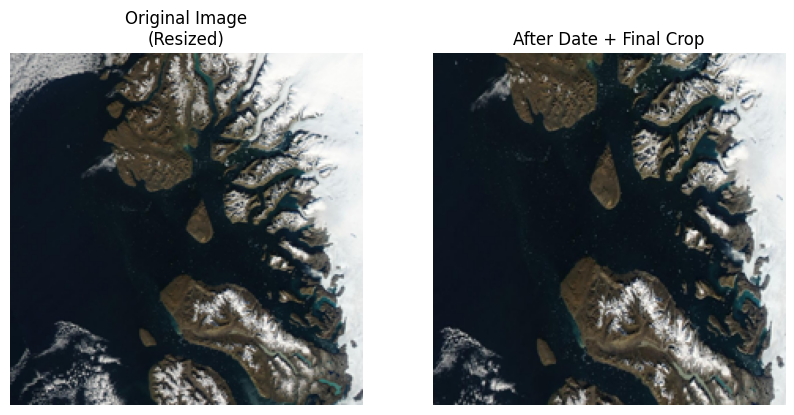

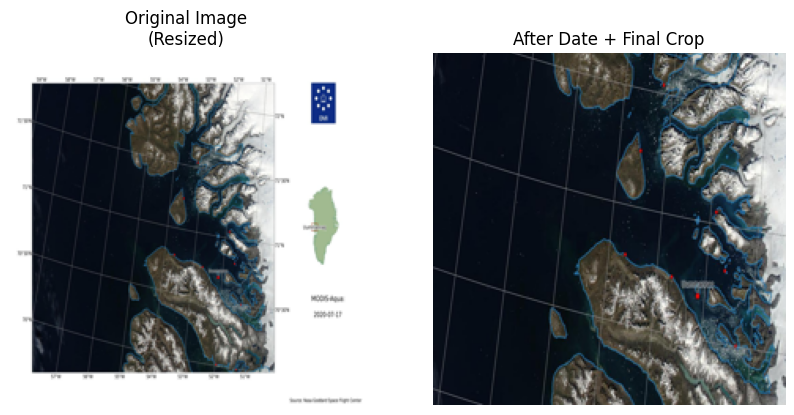

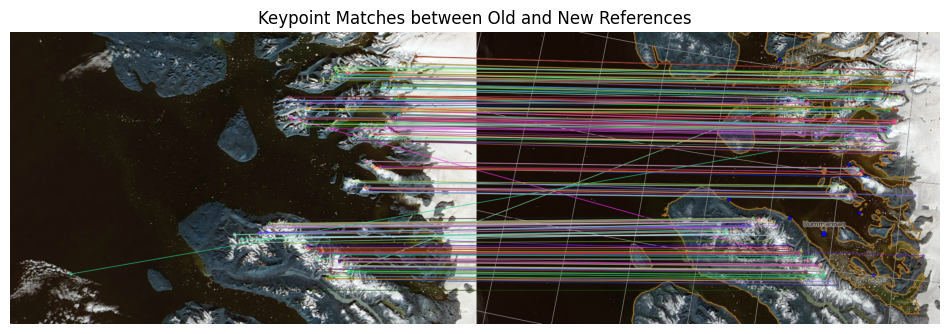

=== Computing Single Homography ===
Homography computed successfully.
=== Visualizing Reference Crops ===


2025-04-10 17:09:00.567836: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-04-10 17:09:00.567878: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-04-10 17:09:00.567881: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
I0000 00:00:1744297740.568336 18914148 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1744297740.568379 18914148 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


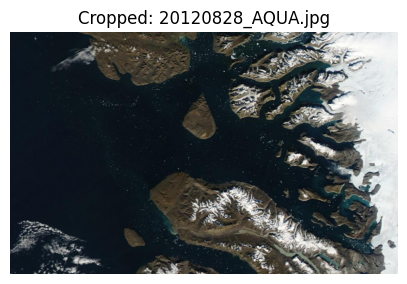

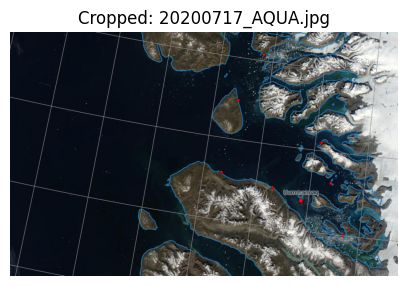

=== Offline Alignment of Old Images ===
Aligned and saved data/aligned/2012/aligned_20120717_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120716_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20121019_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20121018_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120302_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120303_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120430_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120729_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120728_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20121027_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20121026_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120621_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120620_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120506_AQUA.jpg
Aligned and saved data/aligned/2012/aligned_20120507_AQUA.jpg
Aligned and saved data/aligned

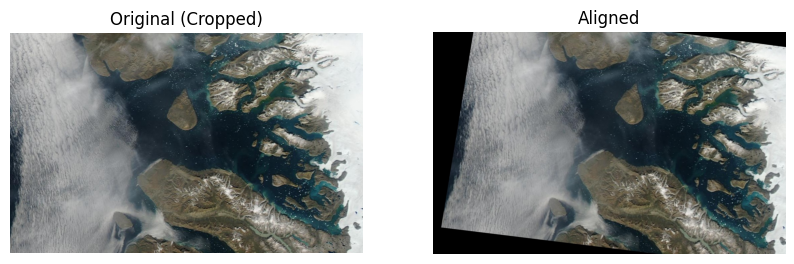

=== Building Training DataFrames ===
=== Building TensorFlow Datasets ===
=== Training Cloud Classifier ===
Epoch 1/30


2025-04-10 17:09:05.715563: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.5507 - loss: 0.6999 - val_accuracy: 0.5000 - val_loss: 130.4691
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5944 - loss: 0.6552 - val_accuracy: 0.6875 - val_loss: 157.2832
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6851 - loss: 0.6001 - val_accuracy: 0.2812 - val_loss: 1499.7786
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.7442 - loss: 0.5985 - val_accuracy: 0.1875 - val_loss: 8212.2148
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7702 - loss: 0.5461 - val_accuracy: 0.1250 - val_loss: 934.7085
Epoch 6/30
 5/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.8096 - loss: 0.5182

KeyboardInterrupt: 

In [6]:
#############################
# BULLETPROOF PIPELINE WITH VISUAL OUTPUTS & METRICS
#############################

import os
import re
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtTiny
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras import Model

#############################
# 1) GLOBAL PARAMETERS & SETTINGS
#############################

# Cutoff date between old vs. new image geometry
CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)

# Final common bounding box (all images must have same ROI)
# (left, top, right, bottom); negative right/bottom indicate offsets from image edge.
FINAL_COMMON_BOX = (129, 47, -14, -122)

# Reference image paths for alignment (single old and new references)
OLD_REF_PATH  = "data/satellite/aqua/2012/20120828_AQUA.jpg"  # known old reference image
NEW_REF_PATH  = "data/satellite/aqua/2020/20200717_AQUA.jpg"  # known new reference image

# Directories for offline alignment and training data
OLD_DIR       = "data/satellite/aqua/2012"      # folder containing old images
ALIGNED_DIR   = "data/aligned/2012"             # output folder for aligned old images
TRAIN_IN      = "data/train"                    # original training folder (manually prepared subfolders: sea_ice, no_ice, cloudy)
TRAIN_OUT     = "data/train_aligned"            # folder after alignment (same subfolder structure)
LEFTOVER_DIR  = "data/leftover"                 # folder with new images for inference later

# Final input image size for the model
IMG_SIZE = (224, 224)

#############################
# 2) DATE-BASED & FINAL CROPPING FUNCTIONS
#############################

def parse_date_from_filename(filename):
    """
    Extracts a date from the first 8 characters of the filename (YYYYMMDD).
    Example: "20120828_AQUA.jpg" -> datetime(2012,8,28)
    """
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    return None

def choose_date_crop_box(w, h, file_date):
    """
    Returns a crop box depending on the date:
      - For images before June 5, 2016: return (0, 200, 1200, 1030)
      - For newer images: return (110, 272, w - 437, h - 113)
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)
    else:
        left = 110
        top = 272
        right = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def final_common_crop(pil_img, final_box=FINAL_COMMON_BOX):
    """
    Applies a final fixed crop to ensure that all images share the exact same ROI.
    Negative right and bottom values indicate offsets from the right and bottom edges.
    """
    w, h = pil_img.size
    left, top, right, bottom = final_box
    if right < 0:
        right = w + right
    if bottom < 0:
        bottom = h + bottom
    left = max(0, left)
    top = max(0, top)
    right = min(right, w)
    bottom = min(bottom, h)
    if right <= left or bottom <= top:
        return pil_img  # Invalid crop; return original.
    return pil_img.crop((left, top, right, bottom))

def date_and_final_crop_pil(pil_img, file_date):
    """
    Combines date-based cropping and final common crop.
    This returns a final cropped PIL image.
    """
    w, h = pil_img.size
    dbox = choose_date_crop_box(w, h, file_date)
    if dbox is not None:
        pil_img = pil_img.crop(dbox)
    pil_img = final_common_crop(pil_img, FINAL_COMMON_BOX)
    return pil_img

# ------------------ Visualization of Cropping ------------------
def visualize_cropping(image_path):
    """
    Loads an image, applies date-based and final crop,
    and displays the original and cropped images side-by-side.
    """
    date_obj = parse_date_from_filename(image_path)
    pil_img = Image.open(image_path).convert("RGB")
    # Resize original for visualization
    original = pil_img.resize((IMG_SIZE[0], IMG_SIZE[1]))
    cropped = date_and_final_crop_pil(pil_img, date_obj)
    cropped = cropped.resize((IMG_SIZE[0], IMG_SIZE[1]))
    
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    axs[0].imshow(original)
    axs[0].set_title("Original Image\n(Resized)")
    axs[0].axis("off")
    axs[1].imshow(cropped)
    axs[1].set_title("After Date + Final Crop")
    axs[1].axis("off")
    plt.show()

# Uncomment to test cropping visualization:
visualize_cropping("data/satellite/aqua/2012/20120828_AQUA.jpg")
visualize_cropping("data/satellite/aqua/2020/20200717_AQUA.jpg")

#############################
# 3) KEYPOINT ALIGNMENT – COMPUTE HOMOGRAPHY
#############################

def compute_homography(old_ref_path, new_ref_path):
    """
    Computes a homography to align the old reference image to the new reference image.
    Both images are processed with date-based cropping and the final common crop.
    Returns H and the new reference image size (width, height).
    """
    old_date = parse_date_from_filename(old_ref_path)
    new_date = parse_date_from_filename(new_ref_path)
    
    old_pil = Image.open(old_ref_path).convert("RGB")
    old_pil = date_and_final_crop_pil(old_pil, old_date)
    old_bgr = cv2.cvtColor(np.array(old_pil), cv2.COLOR_RGB2BGR)
    old_gray = cv2.cvtColor(old_bgr, cv2.COLOR_BGR2GRAY)
    
    new_pil = Image.open(new_ref_path).convert("RGB")
    new_pil = date_and_final_crop_pil(new_pil, new_date)
    new_bgr = cv2.cvtColor(np.array(new_pil), cv2.COLOR_RGB2BGR)
    new_gray = cv2.cvtColor(new_bgr, cv2.COLOR_BGR2GRAY)
    
    orb = cv2.ORB_create(nfeatures=2000)
    kp_o, des_o = orb.detectAndCompute(old_gray, None)
    kp_n, des_n = orb.detectAndCompute(new_gray, None)
    
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw_matches = matcher.knnMatch(des_o, des_n, k=2)
    good = []
    for m, n in raw_matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)
    if len(good) < 10:
        raise ValueError("Not enough matches between old_ref and new_ref")
    
    old_pts = np.float32([kp_o[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    new_pts = np.float32([kp_n[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, _ = cv2.findHomography(old_pts, new_pts, cv2.RANSAC, 5.0)
    if H is None:
        raise ValueError("Homography computation failed")
    
    h_new, w_new = new_gray.shape
    print("Homography computed successfully.")
    return H, (w_new, h_new)

# ------------------ Visualization of Keypoint Matches ------------------
def visualize_keypoints(old_ref_path, new_ref_path):
    """
    Display matching keypoints between the old and new reference images after cropping.
    """
    old_date = parse_date_from_filename(old_ref_path)
    new_date = parse_date_from_filename(new_ref_path)
    old_pil = Image.open(old_ref_path).convert("RGB")
    old_pil = date_and_final_crop_pil(old_pil, old_date)
    new_pil = Image.open(new_ref_path).convert("RGB")
    new_pil = date_and_final_crop_pil(new_pil, new_date)
    
    old_gray = cv2.cvtColor(np.array(old_pil), cv2.COLOR_RGB2GRAY)
    new_gray = cv2.cvtColor(np.array(new_pil), cv2.COLOR_RGB2GRAY)
    
    orb = cv2.ORB_create(nfeatures=2000)
    kp_o, des_o = orb.detectAndCompute(old_gray, None)
    kp_n, des_n = orb.detectAndCompute(new_gray, None)
    
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = matcher.knnMatch(des_o, des_n, k=2)
    good_matches = []
    for m,n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
    
    img_matches = cv2.drawMatches(np.array(old_pil), kp_o, np.array(new_pil), kp_n, good_matches, None, flags=2)
    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title("Keypoint Matches between Old and New References")
    plt.axis("off")
    plt.show()

# Uncomment to test keypoint match visualization:
visualize_keypoints(OLD_REF_PATH, NEW_REF_PATH)

#############################
# 4) OFFLINE ALIGNMENT USING SINGLE HOMOGRAPHY
#############################

def warp_old_image(in_path, H, ref_size, out_path):
    """
    Applies date-based + final common cropping to an image and warps it using H.
    Saves the result to out_path.
    """
    date_obj = parse_date_from_filename(in_path)
    pil_img = Image.open(in_path).convert("RGB")
    pil_img = date_and_final_crop_pil(pil_img, date_obj)
    bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    w_ref, h_ref = ref_size
    warped = cv2.warpPerspective(bgr, H, (w_ref, h_ref), flags=cv2.INTER_LINEAR)
    cv2.imwrite(out_path, warped)

def offline_align_training_data(train_in, train_out, H, ref_size):
    """
    Processes each subfolder in train_in (sea_ice, no_ice, cloudy). For images before the cutoff date,
    applies the homography warp; for newer images, applies date+final cropping.
    The aligned images are saved in the same subfolder structure in train_out.
    """
    subfolders = ["sea_ice", "no_ice", "cloudy"]
    os.makedirs(train_out, exist_ok=True)
    for sf in subfolders:
        in_sf = os.path.join(train_in, sf)
        out_sf = os.path.join(train_out, sf)
        os.makedirs(out_sf, exist_ok=True)
        for fname in os.listdir(in_sf):
            if fname.lower().endswith((".jpg", ".png")):
                in_path = os.path.join(in_sf, fname)
                out_path = os.path.join(out_sf, "aligned_" + fname)
                date_obj = parse_date_from_filename(in_path)
                if date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
                    warp_old_image(in_path, H, ref_size, out_path)
                else:
                    # For new images, simply apply date-based and final crop.
                    pil_img = Image.open(in_path).convert("RGB")
                    pil_img = date_and_final_crop_pil(pil_img, date_obj)
                    bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
                    cv2.imwrite(out_path, bgr)
                print(f"Saved => {out_path}")

# ------------------ Visualize an aligned training example ------------------
def visualize_aligned_example(orig_path, aligned_path):
    """
    Displays the original and aligned (warped) version of an old image side-by-side.
    """
    orig = Image.open(orig_path).convert("RGB")
    date_obj = parse_date_from_filename(orig_path)
    orig_crop = date_and_final_crop_pil(orig, date_obj)
    aligned = Image.open(aligned_path).convert("RGB")
    fig, axs = plt.subplots(1,2, figsize=(10,5))
    axs[0].imshow(orig_crop)
    axs[0].set_title("Original (Cropped)")
    axs[0].axis("off")
    axs[1].imshow(aligned)
    axs[1].set_title("Aligned")
    axs[1].axis("off")
    plt.show()

#############################
# 5) BUILD TRAINING DATAFRAME
#############################

def build_two_step_data(base_dir):
    """
    Expects subfolders (sea_ice, no_ice, cloudy) in base_dir.
    Returns two dataframes:
      - df_cloud for cloud detection (cloudy=1; others=0)
      - df_ice for ice classification (sea_ice=0; no_ice=1)
    """
    subs = ["sea_ice", "no_ice", "cloudy"]
    cpaths, clabels = [], []
    ipaths, ilabels = [], []
    for sf in subs:
        fullp = os.path.join(base_dir, sf)
        for fn in os.listdir(fullp):
            if fn.lower().endswith((".jpg", ".png")):
                fp = os.path.join(fullp, fn)
                if sf == "cloudy":
                    cpaths.append(fp); clabels.append(1)
                else:
                    cpaths.append(fp); clabels.append(0)
                if sf == "sea_ice":
                    ipaths.append(fp); ilabels.append(0)
                elif sf == "no_ice":
                    ipaths.append(fp); ilabels.append(1)
    df_cloud = pd.DataFrame({"filepath": cpaths, "label": clabels})
    df_ice = pd.DataFrame({"filepath": ipaths, "label": ilabels})
    return df_cloud, df_ice

#############################
# 6) TF DATA PIPELINE & DATA AUGMENTATION
#############################

# Define our data augmentation (extended)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

def load_image_final(fp_str, lbl_val, water_mask=None, apply_mask=False):
    """
    Loads an already aligned & final-cropped image from disk, resizes to IMG_SIZE,
    converts to RGB, and normalizes.
    Optionally applies a water mask.
    """
    bgr = cv2.imread(fp_str)
    if bgr is None:
        arr = np.zeros((224,224,3), dtype=np.float32)
        return arr, lbl_val
    bgr = cv2.resize(bgr, IMG_SIZE)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    arr = rgb.astype(np.float32)/255.0
    if apply_mask and water_mask is not None:
        mask_3d = np.expand_dims(water_mask, axis=-1)
        arr = arr * mask_3d
    return arr, lbl_val

def build_dataset(filepaths, labels, water_mask=None, apply_mask=False, batch_size=8, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        def _fn(fp_str, ll):
            fp_str = fp_str.numpy().decode("utf-8")
            ll = ll.numpy()
            arr, lab = load_image_final(fp_str, ll, water_mask, apply_mask)
            return arr, lab
        img, lab_out = tf.py_function(
            func=_fn,
            inp=[fp, lbl],
            Tout=[tf.float32, tf.int32]
        )
        img.set_shape((224,224,3))
        lab_out.set_shape(())
        img = data_augmentation(img)
        return img, lab_out
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

#############################
# 7) MODEL BUILDING
#############################

def build_classifier(base_name="efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True):
    if base_name.lower() == "efficientnetv2":
        base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_name.lower() == "convnext":
        base = ConvNeXtTiny(weights="imagenet", include_top=False, input_shape=(224,224,3))
    else:
        raise ValueError("Unknown base_name.")
    base.trainable = full_fine_tune
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(base.input, out)
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

#############################
# 8) EVALUATION & VISUALIZATION FUNCTIONS
#############################

def evaluate_model_on_test(model, test_ds, class_names):
    all_labels = []
    all_preds = []
    for imgs, lbls in test_ds:
        preds = model.predict(imgs)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(lbls.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print(classification_report(all_labels, all_preds, target_names=class_names))

def classify_new_image(image_path, old_homography, ref_size, model, water_mask=None, apply_mask=False):
    """
    For a new image (not in training):
      - If its date is before 2016, apply the computed homography (old images).
      - Otherwise, apply date+final crop only.
    Then resize to IMG_SIZE, normalize, and predict using the given model.
    Returns the predicted label index.
    """
    date_obj = parse_date_from_filename(image_path)
    if date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
        pil_img = Image.open(image_path).convert("RGB")
        pil_img = date_and_final_crop_pil(pil_img, date_obj)
        bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        w_ref, h_ref = ref_size
        warped = cv2.warpPerspective(bgr, old_homography, (w_ref, h_ref), flags=cv2.INTER_LINEAR)
        imres = cv2.resize(warped, IMG_SIZE)
        rgb = cv2.cvtColor(imres, cv2.COLOR_BGR2RGB)
        arr = rgb.astype(np.float32)/255.0
    else:
        pil_img = Image.open(image_path).convert("RGB")
        pil_img = date_and_final_crop_pil(pil_img, date_obj)
        imres = pil_img.resize(IMG_SIZE)
        arr = np.array(imres, dtype=np.float32)/255.0

    if apply_mask and water_mask is not None:
        mask_3d = np.expand_dims(water_mask, axis=-1)
        arr = arr * mask_3d

    inp = np.expand_dims(arr, axis=0)
    preds = model.predict(inp)
    label_idx = np.argmax(preds, axis=1)[0]
    return label_idx

def visualize_prediction(image_path, old_homography, ref_size, model, water_mask=None, apply_mask=False):
    label_idx = classify_new_image(image_path, old_homography, ref_size, model, water_mask, apply_mask)
    with Image.open(image_path) as pil_img:
        date_obj = parse_date_from_filename(image_path)
        cropped = date_and_final_crop_pil(pil_img, date_obj)
    plt.figure(figsize=(6,6))
    plt.imshow(cropped)
    plt.title(f"Predicted Label: {label_idx}")
    plt.axis("off")
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    with Image.open(image_path) as pil_img:
        date_obj = parse_date_from_filename(image_path)
        cropped = date_and_final_crop_pil(pil_img, date_obj)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32)/255.0
        mask_3d = np.expand_dims(water_mask, axis=-1)
        masked_arr = arr * mask_3d

    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    axs[0].imshow(arr)
    axs[0].set_title("Cropped Image")
    axs[0].axis("off")
    axs[1].imshow(water_mask, cmap="gray")
    axs[1].set_title("Water Mask")
    axs[1].axis("off")
    axs[2].imshow(masked_arr)
    axs[2].set_title("Image * Mask")
    axs[2].axis("off")
    plt.show()

#############################
# 9) MAIN ORCHESTRATION
#############################

def main():
    # (A) Compute Homography from old reference to new reference.
    print("=== Computing Single Homography ===")
    try:
        H, ref_size = compute_homography(OLD_REF_PATH, NEW_REF_PATH)
    except Exception as e:
        print("Homography computation failed:", e)
        return

    # Visualize the old and new reference images after cropping.
    print("=== Visualizing Reference Crops ===")
    for path in [OLD_REF_PATH, NEW_REF_PATH]:
        date_obj = parse_date_from_filename(path)
        pil_img = Image.open(path).convert("RGB")
        cropped = date_and_final_crop_pil(pil_img, date_obj)
        plt.figure(figsize=(5,5))
        plt.imshow(cropped)
        plt.title(f"Cropped: {os.path.basename(path)}")
        plt.axis("off")
        plt.show()

    # (B) Offline Alignment: Apply the computed H to all old images in OLD_DIR.
    print("=== Offline Alignment of Old Images ===")
    os.makedirs(ALIGNED_DIR, exist_ok=True)
    for fname in os.listdir(OLD_DIR):
        if fname.lower().endswith((".jpg",".png")):
            in_path = os.path.join(OLD_DIR, fname)
            out_path = os.path.join(ALIGNED_DIR, "aligned_" + fname)
            warp_old_image(in_path, H, ref_size, out_path)
            print(f"Aligned and saved {out_path}")

    # Visualize one example of offline alignment (compare original vs. aligned).
    example_old = os.path.join(OLD_DIR, os.listdir(OLD_DIR)[0])
    example_aligned = os.path.join(ALIGNED_DIR, "aligned_" + os.path.basename(example_old))
    visualize_aligned_example(example_old, example_aligned)

    # (C) Organize Training Data:
    # Here we assume that you have manually or programmatically moved the aligned images
    # into TRAIN_OUT with the correct subfolder structure (sea_ice, no_ice, cloudy).
    # For this code, we assume TRAIN_OUT already exists.
    # If needed, you could use a helper function to re-organize based on filename patterns.

    # (D) Build Training DataFrames from TRAIN_OUT.
    print("=== Building Training DataFrames ===")
    df_cloud, df_ice = build_two_step_data(TRAIN_OUT)
    # For simplicity, we do a direct split (you can refine as needed).
    n_c = len(df_cloud)
    train_cloud = df_cloud[:int(0.8*n_c)]
    val_cloud = df_cloud[int(0.8*n_c):int(0.9*n_c)]
    test_cloud = df_cloud[int(0.9*n_c):]
    
    n_i = len(df_ice)
    train_ice = df_ice[:int(0.8*n_i)]
    val_ice = df_ice[int(0.8*n_i):int(0.9*n_i)]
    test_ice = df_ice[int(0.9*n_i):]

    # (E) Build TensorFlow Datasets for Cloud and Ice classifiers.
    print("=== Building TensorFlow Datasets ===")
    train_cloud_ds = build_dataset(train_cloud["filepath"].tolist(),
                                   train_cloud["label"].tolist(),
                                   water_mask=None,
                                   apply_mask=False, batch_size=8)
    val_cloud_ds = build_dataset(val_cloud["filepath"].tolist(),
                                 val_cloud["label"].tolist(),
                                 water_mask=None,
                                 apply_mask=False, batch_size=8, shuffle=False)
    test_cloud_ds = build_dataset(test_cloud["filepath"].tolist(),
                                  test_cloud["label"].tolist(),
                                  water_mask=None,
                                  apply_mask=False, batch_size=8, shuffle=False)
    
    train_ice_ds = build_dataset(train_ice["filepath"].tolist(),
                                 train_ice["label"].tolist(),
                                 water_mask=None,
                                 apply_mask=False, batch_size=8)
    val_ice_ds = build_dataset(val_ice["filepath"].tolist(),
                               val_ice["label"].tolist(),
                               water_mask=None,
                               apply_mask=False, batch_size=8, shuffle=False)
    test_ice_ds = build_dataset(test_ice["filepath"].tolist(),
                                test_ice["label"].tolist(),
                                water_mask=None,
                                apply_mask=False, batch_size=8, shuffle=False)

    # (F) Train Cloud Classifier
    print("=== Training Cloud Classifier ===")
    cloud_model = build_classifier("efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True)
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    cloud_model.fit(train_cloud_ds, validation_data=val_cloud_ds, epochs=30, callbacks=[early_stop])
    print("=== Evaluating Cloud Classifier ===")
    cloud_model.evaluate(test_cloud_ds)
    evaluate_model_on_test(cloud_model, test_cloud_ds, ["clear", "cloudy"])

       # (G) Train Ice Classifier
    print("=== Training Ice Classifier ===")
    ice_model = build_classifier("efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True)
    ice_model.fit(train_ice_ds, validation_data=val_ice_ds, epochs=30, callbacks=[early_stop])
    print("=== Evaluating Ice Classifier ===")
    ice_model.evaluate(test_ice_ds)
    evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice", "no_ice"])

    # # (G) Train Ice Classifier
    # print("=== Training Ice Classifier ===")
    # ice_model = build_classifier("convnext", num_classes=2, lr=1e-5, full_fine_tune=True)
    # ice_model.fit(train_ice_ds, validation_data=val_ice_ds, epochs=30, callbacks=[early_stop])
    # print("=== Evaluating Ice Classifier ===")
    # ice_model.evaluate(test_ice_ds)
    # evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice", "no_ice"])

    # (H) Visualize some augmented images from the training dataset.
    print("=== Visualizing Sample Augmented Images (Cloud DS) ===")
    for images, labels in train_cloud_ds.take(1):
        images_np = images.numpy()
        fig, axs = plt.subplots(1, 3, figsize=(12,4))
        for i in range(3):
            axs[i].imshow(images_np[i])
            axs[i].set_title(f"Label: {labels.numpy()[i]}")
            axs[i].axis("off")
        plt.show()

    # (I) Inference on new/unseen images.
    print("=== Inference on New Images ===")
    leftover_files = [os.path.join(LEFTOVER_DIR, f) for f in os.listdir(LEFTOVER_DIR) if f.lower().endswith(".jpg")]
    for fpath in leftover_files:
        # For an old image: warp using computed homography.
        lbl_idx = classify_new_image(fpath, H, ref_size, cloud_model, water_mask=None, apply_mask=False)
        if lbl_idx == 1:
            print(f"{fpath} => Cloudy")
        else:
            lbl_ice = classify_new_image(fpath, H, ref_size, ice_model, water_mask=None, apply_mask=False)
            if lbl_ice == 0:
                print(f"{fpath} => Sea Ice")
            else:
                print(f"{fpath} => No Ice")

    # (J) Visualize prediction for one example.
    example_path = NEW_REF_PATH  # or any sample image
    visualize_prediction(example_path, H, ref_size, cloud_model, water_mask=None, apply_mask=False)
    visualize_mask_alignment(example_path, water_mask=None)

    print("=== Pipeline complete. ===")

if __name__ == "__main__":
    main()


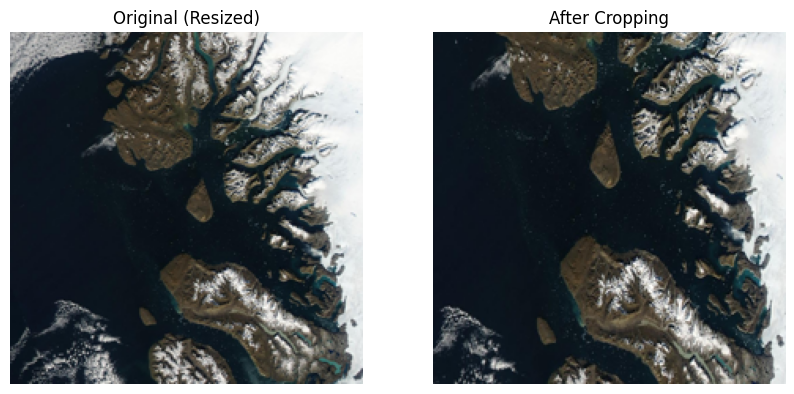

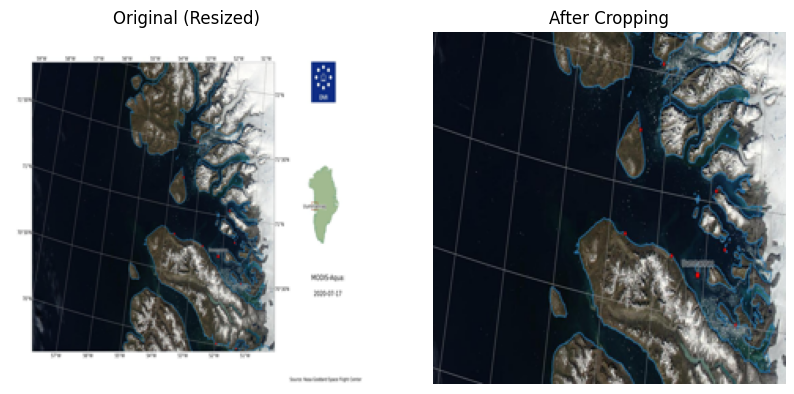

=== Computing Single Homography ===
Homography computed successfully.
=== Visualizing Cropping for Reference Images ===


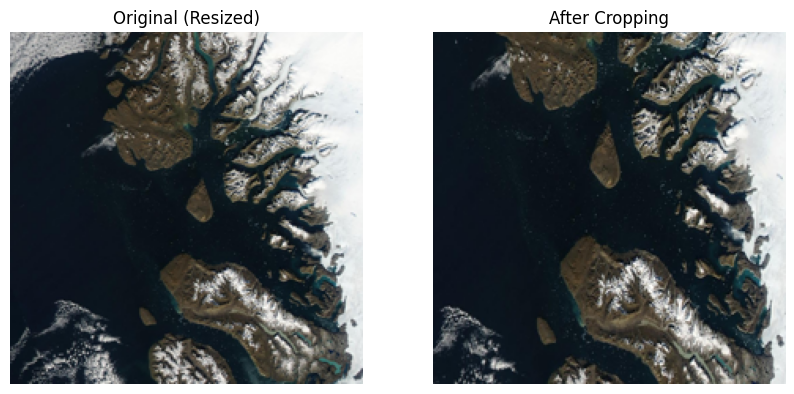

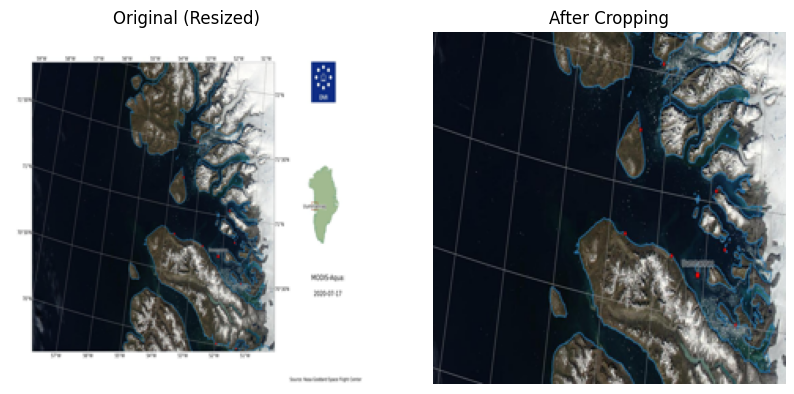

=== Offline Alignment of Old Images ===


NameError: name 'apply_mask_overlay' is not defined

In [5]:
#############################
# FULL PIPELINE WITH OFFLINE ALIGNMENT (OLD -> NEW GEOMETRY),
# FINAL CROPPING, & MASK OVERLAY (Ensuring the Mask Matches the Final Region)
#############################

# ----- 1. Import Statements -----
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtTiny
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras import Model

# ----- 2. Global Parameters & Settings -----
CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)
# FINAL_COMMON_BOX: This fixed crop is applied after alignment; negative values mean offsets from the image's right/bottom.
FINAL_COMMON_BOX = (129, 47, -14, -122)

# Reference images: one old, one new.
OLD_REF_PATH = "data/satellite/aqua/2012/20120828_AQUA.jpg"  # Pre-2016 reference image
NEW_REF_PATH = "data/satellite/aqua/2020/20200717_AQUA.jpg"  # Post-2016 reference image

# Directories for processing
OLD_DIR = "data/satellite/aqua/2012"         # Folder of original old images
ALIGNED_DIR = "data/aligned/2012"            # Where fully processed (aligned + cropped + mask overlaid) images are saved
TRAIN_IN = "data/train"                      # Original training images (subfolders: sea_ice, no_ice, cloudy)
TRAIN_OUT = "data/train_aligned"             # Final training images after offline alignment
LEFTOVER_DIR = "data/leftover"               # New/unseen images for inference
IMG_SIZE = (224, 224)

# ----- 3. Date-Based Cropping Functions -----
def parse_date_from_filename(filename):
    """
    Extracts the date (YYYYMMDD) from the beginning of the filename.
    Example: "20120828_AQUA.jpg" → datetime(2012, 8, 28)
    """
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    return None

def choose_date_crop_box(w, h, file_date):
    """
    Chooses a crop box based on file_date.
    - For old images (date < June 5, 2016), returns (0, 200, 1200, 1030) (to remove the top beam).
    - For new images, a different crop can be defined.
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)
    else:
        left = 110
        top = 272
        right = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    """
    Converts the image to RGB and applies the date-based crop.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_date_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

# ----- 4. Final Common Crop -----
def final_common_crop(pil_img, final_box=FINAL_COMMON_BOX):
    """
    Applies a fixed final crop to remove black borders.
    Negative right or bottom values are interpreted as offsets from the image's width/height.
    """
    w, h = pil_img.size
    left, top, right, bottom = final_box
    if right < 0:
        right = w + right
    if bottom < 0:
        bottom = h + bottom
    left = max(0, left)
    top = max(0, top)
    right = min(right, w)
    bottom = min(bottom, h)
    if right <= left or bottom <= top:
        return pil_img
    return pil_img.crop((left, top, right, bottom))

# ----- 5. Combined Crop Function -----
def date_and_final_crop_pil(pil_img, file_date):
    """
    Applies the date-based crop (to remove beam) then the final common crop.
    """
    pil_img = date_based_crop(pil_img, file_date)
    pil_img = final_common_crop(pil_img, FINAL_COMMON_BOX)
    return pil_img

# ----- 6. Visualize Cropping Steps -----
def visualize_cropping(image_path):
    """
    Displays a side-by-side comparison of the original image (resized) and the fully cropped image.
    """
    date_obj = parse_date_from_filename(image_path)
    pil_img = Image.open(image_path).convert("RGB")
    original = pil_img.resize(IMG_SIZE)
    cropped = date_and_final_crop_pil(pil_img, date_obj).resize(IMG_SIZE)
    
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    axs[0].imshow(original)
    axs[0].set_title("Original (Resized)")
    axs[0].axis("off")
    axs[1].imshow(cropped)
    axs[1].set_title("After Cropping")
    axs[1].axis("off")
    plt.show()

# Test cropping visualization:
visualize_cropping("data/satellite/aqua/2012/20120828_AQUA.jpg")
visualize_cropping("data/satellite/aqua/2020/20200717_AQUA.jpg")

# ----- 7. MASK LOADING & FINAL CROPPING -----
def load_water_mask(mask_path, final_size=(224,224)):
    """
    Loads the water mask image (from a new picture), applies the same final common crop,
    then resizes to final_size and scales values to [0,1].
    This ensures that the mask aligns exactly with the final warped images.
    """
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        # Apply the same final crop to the mask.
        mask_img = final_common_crop(mask_img, FINAL_COMMON_BOX)
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
    return mask_arr

# ----- 8. Offline Alignment & Final Processing of Training Images -----
def warp_old_image(in_path, H, ref_size, water_mask=None, out_path=None):
    """
    Fully processes an old image as follows:
      1. Loads the image and applies a date-based crop to remove the beam.
      2. Warps the image to new geometry using homography H.
      3. Applies the final common crop to remove black borders.
      4. Resizes the image to IMG_SIZE.
      5. Overlays the water mask (which is assumed to be in new geometry and final-cropped).
      6. Saves and returns the final image.
    """
    date_obj = parse_date_from_filename(in_path)
    pil_img = Image.open(in_path).convert("RGB")
    
    # Step 1: Date-based crop.
    cropped = date_based_crop(pil_img, date_obj)
    
    # Step 2: Warp the image into new geometry if it's an old image.
    if H is not None and date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
        bgr = cv2.cvtColor(np.array(cropped), cv2.COLOR_RGB2BGR)
        w_ref, h_ref = ref_size
        warped = cv2.warpPerspective(bgr, H, (w_ref, h_ref), flags=cv2.INTER_LINEAR)
        aligned = Image.fromarray(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    else:
        aligned = cropped
    
    # Step 3: Apply the final common crop.
    final_img = final_common_crop(aligned, FINAL_COMMON_BOX)
    # Step 4: Resize to target IMG_SIZE.
    final_img = final_img.resize(IMG_SIZE)
    # Step 5: Overlay the water mask (now both image and mask have been final-cropped).
    if water_mask is not None:
        final_img = apply_mask_overlay(final_img, water_mask, alpha=0.5)
    # Step 6: Save the final processed image if out_path is provided.
    if out_path is not None:
        final_img.save(out_path)
    return final_img

def offline_align_training_data(train_in, train_out, H, ref_size, water_mask=None):
    """
    Processes each image from the training directory (organized in subfolders).
    Old images (date < cutoff) are warped using H; all images receive the same final cropping and mask overlay.
    Saves the fully processed images into the corresponding subfolders under train_out.
    """
    subs = ["sea_ice", "no_ice", "cloudy"]
    os.makedirs(train_out, exist_ok=True)
    for sf in subs:
        in_sf = os.path.join(train_in, sf)
        out_sf = os.path.join(train_out, sf)
        os.makedirs(out_sf, exist_ok=True)
        for fname in os.listdir(in_sf):
            if fname.lower().endswith((".jpg", ".png")):
                in_path = os.path.join(in_sf, fname)
                out_path = os.path.join(out_sf, "aligned_" + fname)
                date_obj = parse_date_from_filename(in_path)
                if date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
                    warp_old_image(in_path, H, ref_size, water_mask=water_mask, out_path=out_path)
                else:
                    pil_img = Image.open(in_path).convert("RGB")
                    pil_img = date_and_final_crop_pil(pil_img, date_obj)
                    pil_img = pil_img.resize(IMG_SIZE)
                    if water_mask is not None:
                        pil_img = apply_mask_overlay(pil_img, water_mask, alpha=0.5)
                    pil_img.save(out_path)
                print(f"Saved => {out_path}")

def visualize_aligned_example(orig_path, aligned_path):
    """
    Displays a side-by-side comparison of the original cropped image vs. the final processed image.
    """
    orig = Image.open(orig_path).convert("RGB")
    date_obj = parse_date_from_filename(orig_path)
    orig_crop = date_and_final_crop_pil(orig, date_obj).resize(IMG_SIZE)
    aligned = Image.open(aligned_path).convert("RGB").resize(IMG_SIZE)
    
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    axs[0].imshow(orig_crop)
    axs[0].set_title("Original (Cropped Only)")
    axs[0].axis("off")
    axs[1].imshow(aligned)
    axs[1].set_title("Final Aligned (with Mask)")
    axs[1].axis("off")
    plt.show()

# ----- 9. Build Training DataFrames -----
def build_two_step_data(base_dir):
    """
    Reads images from subfolders in base_dir.
    For cloud classification:
      - Images in "cloudy" are labeled 1.
      - Images in "sea_ice" and "no_ice" are merged as "clear" (labeled 0).
    For ice classification:
      - "sea_ice" is label 0; "no_ice" is label 1.
    Returns two DataFrames: df_cloud and df_ice.
    """
    subs = ["sea_ice", "no_ice", "cloudy"]
    cpaths, clabels = [], []
    ipaths, ilabels = [], []
    for sf in subs:
        fullp = os.path.join(base_dir, sf)
        for fn in os.listdir(fullp):
            if fn.lower().endswith((".jpg", ".png")):
                fp = os.path.join(fullp, fn)
                # For cloud classification: cloudy = 1; others = 0.
                if sf == "cloudy":
                    cpaths.append(fp); clabels.append(1)
                else:
                    cpaths.append(fp); clabels.append(0)
                # For ice classification: sea_ice = 0; no_ice = 1.
                if sf == "sea_ice":
                    ipaths.append(fp); ilabels.append(0)
                elif sf == "no_ice":
                    ipaths.append(fp); ilabels.append(1)
    df_cloud = pd.DataFrame({"filepath": cpaths, "label": clabels})
    df_ice = pd.DataFrame({"filepath": ipaths, "label": ilabels})
    return df_cloud, df_ice

def split_df(df, frac_train=0.8, frac_val=0.1):
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(df)
    n_train = int(frac_train * n)
    n_val = int(frac_val * n)
    df_train = df.iloc[:n_train]
    df_val = df.iloc[n_train:n_train+n_val]
    df_test = df.iloc[n_train+n_val:]
    return df_train, df_val, df_test

# ----- 10. TF Dataset Pipeline (Loading Final Images) -----
def load_image_final(fp_str, lbl_val, water_mask=None, apply_mask=False):
    """
    Loads a final processed image (aligned, cropped, masked), resizes to IMG_SIZE,
    and normalizes it. No extra cropping is applied.
    """
    img = Image.open(fp_str).convert("RGB")
    img = img.resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr, lbl_val

def build_dataset(filepaths, labels, water_mask=None, apply_mask=False, batch_size=8, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        def _fn(fp_str, ll):
            fp_str = fp_str.numpy().decode("utf-8")
            ll = ll.numpy()
            arr, lab = load_image_final(fp_str, ll, water_mask, apply_mask)
            return arr, lab
        img, lab_out = tf.py_function(func=_fn, inp=[fp, lbl], Tout=[tf.float32, tf.int32])
        img.set_shape((224,224,3))
        lab_out.set_shape(())
        return img, lab_out
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

# ----- 11. Model Building -----
def build_classifier(base_name="efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True):
    if base_name.lower() == "efficientnetv2":
        base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_name.lower() == "convnext":
        base = ConvNeXtTiny(weights="imagenet", include_top=False, input_shape=(224,224,3))
    else:
        raise ValueError("Unknown base_name.")
    base.trainable = full_fine_tune
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(base.input, out)
    model.compile(optimizer=Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# ----- 12. Evaluation & Visualization Functions -----
def evaluate_model_on_test(model, test_ds, class_names):
    all_labels = []
    all_preds = []
    for imgs, lbls in test_ds:
        preds = model.predict(imgs)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(lbls.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print(classification_report(all_labels, all_preds, target_names=class_names))

def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

def classify_new_image(image_path, old_homography, ref_size, model, water_mask=None, apply_mask=False):
    """
    Processes a new image for inference:
      - If the image is old (date < cutoff), warp it using H.
      - Otherwise, simply apply date-based and final crop.
    Resizes and normalizes the image and feeds it into the model.
    Returns the predicted label index.
    """
    date_obj = parse_date_from_filename(image_path)
    if date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
        pil_img = Image.open(image_path).convert("RGB")
        pil_img = date_and_final_crop_pil(pil_img, date_obj)
        bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        w_ref, h_ref = ref_size
        warped = cv2.warpPerspective(bgr, old_homography, (w_ref, h_ref), flags=cv2.INTER_LINEAR)
        imres = cv2.resize(warped, IMG_SIZE)
        rgb = cv2.cvtColor(imres, cv2.COLOR_BGR2RGB)
        arr = rgb.astype(np.float32) / 255.0
    else:
        pil_img = Image.open(image_path).convert("RGB")
        pil_img = date_and_final_crop_pil(pil_img, date_obj)
        imres = pil_img.resize(IMG_SIZE)
        arr = np.array(imres, dtype=np.float32) / 255.0
    if apply_mask and water_mask is not None:
        mask_3d = np.expand_dims(water_mask, axis=-1)
        arr = arr * mask_3d
    inp = np.expand_dims(arr, axis=0)
    preds = model.predict(inp)
    label_idx = np.argmax(preds, axis=1)[0]
    return label_idx

def visualize_prediction(image_path, old_homography, ref_size, model, water_mask=None, apply_mask=False):
    label_idx = classify_new_image(image_path, old_homography, ref_size, model, water_mask, apply_mask)
    with Image.open(image_path) as pil_img:
        date_obj = parse_date_from_filename(image_path)
        cropped = date_and_final_crop_pil(pil_img, date_obj)
    plt.figure(figsize=(6,6))
    plt.imshow(cropped)
    plt.title(f"Predicted Label: {label_idx}")
    plt.axis("off")
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    with Image.open(image_path) as pil_img:
        date_obj = parse_date_from_filename(image_path)
        cropped = date_and_final_crop_pil(pil_img, date_obj)
        cropped = cropped.resize(IMG_SIZE)
        arr = np.array(cropped, dtype=np.float32) / 255.0
        if water_mask is not None:
            mask_3d = np.expand_dims(water_mask, axis=-1)
            masked_arr = arr * mask_3d
        else:
            masked_arr = arr
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    axs[0].imshow(arr)
    axs[0].set_title("Cropped Image")
    axs[0].axis("off")
    if water_mask is not None:
        axs[1].imshow(water_mask, cmap="gray")
        axs[1].set_title("Water Mask")
    else:
        axs[1].text(0.5, 0.5, "No Mask", ha="center", va="center")
    axs[1].axis("off")
    axs[2].imshow(masked_arr)
    axs[2].set_title("Image with Mask Applied")
    axs[2].axis("off")
    plt.show()

# ----- 14. Main Orchestration -----
def main():
    # Step A: Compute the homography (old -> new geometry).
    print("=== Computing Single Homography ===")
    try:
        H, ref_size = compute_homography(OLD_REF_PATH, NEW_REF_PATH)
    except Exception as e:
        print("Homography computation failed:", e)
        return

    # Step B: Visualize the cropping of the reference images.
    print("=== Visualizing Cropping for Reference Images ===")
    for path in [OLD_REF_PATH, NEW_REF_PATH]:
        visualize_cropping(path)
    
    # Step C: Offline Alignment for Old Images.
    # Process every image from OLD_DIR: warp them to new geometry, apply final crop, and overlay the water mask.
    print("=== Offline Alignment of Old Images ===")
    water_mask = load_water_mask("data/satellite/aqua/mask/mask_AQUA.jpg", final_size=IMG_SIZE)
    os.makedirs(ALIGNED_DIR, exist_ok=True)
    for fname in os.listdir(OLD_DIR):
        if fname.lower().endswith((".jpg", ".png")):
            in_path = os.path.join(OLD_DIR, fname)
            out_path = os.path.join(ALIGNED_DIR, "aligned_" + fname)
            final_img = warp_old_image(in_path, H, ref_size, water_mask=water_mask, out_path=out_path)
            print(f"Aligned and saved: {out_path}")
    
    # Step D: Visualize one aligned example.
    example_orig = os.path.join(OLD_DIR, os.listdir(OLD_DIR)[0])
    example_aligned = os.path.join(ALIGNED_DIR, "aligned_" + os.path.basename(example_orig))
    visualize_aligned_example(example_orig, example_aligned)
    
    # Step E: Build Training DataFrames from TRAIN_OUT.
    # Here, images are assumed to be pre-organized into subfolders (sea_ice, no_ice, cloudy).
    # For cloud classification: "cloudy" = 1; "sea_ice" and "no_ice" are merged as 0 (clear).
    print("=== Building Training DataFrames ===")
    df_cloud, df_ice = build_two_step_data(TRAIN_OUT)
    print("Cloud DF Head:\n", df_cloud.head())
    print("Ice DF Head:\n", df_ice.head())
    train_cloud, val_cloud, test_cloud = split_df(df_cloud)
    train_ice, val_ice, test_ice = split_df(df_ice)
    
    # Step F: Build TensorFlow Datasets.
    # Since images in TRAIN_OUT are fully processed, we load them simply (resize and normalize).
    print("=== Building TensorFlow Datasets ===")
    train_cloud_ds = build_dataset(train_cloud["filepath"].tolist(), train_cloud["label"].tolist(),
                                   water_mask=None, apply_mask=False, batch_size=8)
    val_cloud_ds = build_dataset(val_cloud["filepath"].tolist(), val_cloud["label"].tolist(),
                                 water_mask=None, apply_mask=False, batch_size=8, shuffle=False)
    test_cloud_ds = build_dataset(test_cloud["filepath"].tolist(), test_cloud["label"].tolist(),
                                  water_mask=None, apply_mask=False, batch_size=8, shuffle=False)
    
    train_ice_ds = build_dataset(train_ice["filepath"].tolist(), train_ice["label"].tolist(),
                                 water_mask=None, apply_mask=False, batch_size=8)
    val_ice_ds = build_dataset(val_ice["filepath"].tolist(), val_ice["label"].tolist(),
                               water_mask=None, apply_mask=False, batch_size=8, shuffle=False)
    test_ice_ds = build_dataset(test_ice["filepath"].tolist(), test_ice["label"].tolist(),
                                water_mask=None, apply_mask=False, batch_size=8, shuffle=False)
    
    # Step G: Train Cloud Classifier.
    print("=== Training Cloud Classifier ===")
    # For cloud classification, images in "cloudy" are labeled 1 and others (sea_ice + no_ice) are 0.
    cloud_model = build_classifier("efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True)
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    history_cloud = cloud_model.fit(train_cloud_ds, validation_data=val_cloud_ds, epochs=30, callbacks=[early_stop])
    plot_training_history(history_cloud, title="Cloud Classifier Training")
    print("=== Evaluating Cloud Classifier ===")
    cloud_model.evaluate(test_cloud_ds)
    evaluate_model_on_test(cloud_model, test_cloud_ds, ["clear", "cloudy"])
    
    # Step H: Train Ice Classifier.
    print("=== Training Ice Classifier ===")
    # For ice classification, "sea_ice" are labeled 0 and "no_ice" as 1.
    ice_model = build_classifier("convnext", num_classes=2, lr=1e-5, full_fine_tune=True)
    history_ice = ice_model.fit(train_ice_ds, validation_data=val_ice_ds, epochs=30, callbacks=[early_stop])
    plot_training_history(history_ice, title="Ice Classifier Training")
    print("=== Evaluating Ice Classifier ===")
    ice_model.evaluate(test_ice_ds)
    evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice", "no_ice"])
    
    # Step I: (Optional) Visualize sample augmented images from Cloud DS.
    print("=== Visualizing Sample Augmented Images (Cloud DS) ===")
    for images, labels in train_cloud_ds.take(1):
        images_np = images.numpy()
        fig, axs = plt.subplots(1, 3, figsize=(12,4))
        for i in range(3):
            axs[i].imshow(images_np[i])
            axs[i].set_title(f"Label: {labels.numpy()[i]}")
            axs[i].axis("off")
        plt.show()
    
    # Step J: Inference on New/Leftover Images.
    print("=== Inference on New/Leftover Images ===")
    leftover_files = [os.path.join(LEFTOVER_DIR, f) for f in os.listdir(LEFTOVER_DIR) if f.lower().endswith(".jpg")]
    for fpath in leftover_files:
        lbl_idx = classify_new_image(fpath, H, ref_size, cloud_model, water_mask=None, apply_mask=False)
        if lbl_idx == 1:
            result = "Cloudy"
        else:
            lbl_ice = classify_new_image(fpath, H, ref_size, ice_model, water_mask=None, apply_mask=False)
            result = "Sea Ice" if lbl_ice == 0 else "No Ice"
        print(f"{fpath} => {result}")
    
    # Step K: Visualize Prediction and Mask Alignment for a Sample Image.
    example_path = NEW_REF_PATH  # You may change to any sample image.
    visualize_prediction(example_path, H, ref_size, cloud_model, water_mask=None, apply_mask=False)
    visualize_mask_alignment(example_path, water_mask=water_mask)
    
    print("=== Pipeline Complete ===")

if __name__ == "__main__":
    main()


In [4]:
#############################
# VISUALIZATION OF INTERMEDIATE PIPELINE STATES WITH MASK OVERLAY
#############################

# ----- 1. Import Statements -----
import os
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

# ----- 2. Global Parameters & Settings -----
# The cutoff date is used for date‐based cropping.
CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)
# FINAL_COMMON_BOX: (left, top, right, bottom) – negative right/bottom indicate offsets from the image edges.
FINAL_COMMON_BOX = (129, 47, -14, -122)
IMG_SIZE = (224, 224)  # target dimensions

# ----- 3. Date-Based Cropping Functions -----
def parse_date_from_filename(filename):
    """
    Extracts the date (YYYYMMDD) from the filename.
    Example: "20120828_AQUA.jpg" -> datetime(2012, 8, 28)
    """
    base = os.path.basename(filename)
    match = re.match(r"(\d{8})", base)
    if match:
        return datetime.strptime(match.group(1), "%Y%m%d")
    return None

def choose_date_crop_box(w, h, file_date):
    """
    Chooses a crop box based on the file date.
    For old images (date < 2016-06-05), returns (0, 200, 1200, 1030).
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)
    else:
        # For new images, you can define a different crop if needed.
        left = 110
        top = 272
        right = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    """
    Converts the image to RGB and applies the date-based crop.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_date_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

# ----- 4. Final Common Crop -----
def final_common_crop(pil_img, final_box=FINAL_COMMON_BOX):
    """
    Applies a fixed final crop to remove black borders.
    Negative values for right and bottom are taken as offsets from the image width/height.
    """
    w, h = pil_img.size
    left, top, right, bottom = final_box
    if right < 0:
        right = w + right
    if bottom < 0:
        bottom = h + bottom
    left = max(0, left)
    top = max(0, top)
    right = min(right, w)
    bottom = min(bottom, h)
    if right <= left or bottom <= top:
        return pil_img
    return pil_img.crop((left, top, right, bottom))

# ----- 5. Combined Crop Function -----
def date_and_final_crop_pil(pil_img, file_date):
    """
    Applies the date-based crop first, then the final common crop.
    """
    cropped = date_based_crop(pil_img, file_date)
    final = final_common_crop(cropped, FINAL_COMMON_BOX)
    return final

# ----- 6. Mask Loading and Final Crop for Mask -----
def load_water_mask(mask_path, final_size=(224,224)):
    """
    Loads the water mask from a new image (where water=255, land=0),
    applies the same final common crop so that the mask aligns with our final images,
    resizes it to final_size, and scales pixel values to [0,1].
    """
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        mask_img = final_common_crop(mask_img, FINAL_COMMON_BOX)
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
    return mask_arr

# ----- 7. Warping Old Images (Assuming Homography Already Computed) -----
def warp_old_image_for_visualization(pil_img, H, ref_size):
    """
    Warps the input old image (already date-based cropped) using homography H,
    returning the warped image as a PIL Image in new geometry.
    """
    bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    w_ref, h_ref = ref_size
    warped = cv2.warpPerspective(bgr, H, (w_ref, h_ref), flags=cv2.INTER_LINEAR)
    return Image.fromarray(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))

# ----- 8. Pipeline States Function -----
def get_pipeline_states(image_path, H, ref_size, water_mask):
    """
    Processes a given old image through several states:
      - State 1: Original image resized.
      - State 2: After date-based crop only.
      - State 3: After warping (for old images) using homography H.
      - State 4: After applying final common crop.
    Then, for each state, a version with the water mask overlaid is created.
    
    Returns two lists of PIL images:
      states: the raw states,
      masked_states: the corresponding states after applying the mask.
    """
    date_obj = parse_date_from_filename(image_path)
    orig_img = Image.open(image_path).convert("RGB")
    state1 = orig_img.resize(IMG_SIZE)
    
    state2 = date_based_crop(orig_img, date_obj).resize(IMG_SIZE)
    
    # For state 3: if old, warp the date-cropped image to new geometry.
    if date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
        state3_temp = date_based_crop(orig_img, date_obj)
        state3 = warp_old_image_for_visualization(state3_temp, H, ref_size).resize(IMG_SIZE)
    else:
        state3 = state2.copy()
    
    state4 = final_common_crop(state3, FINAL_COMMON_BOX).resize(IMG_SIZE)
    
    # Now create masked versions of each state using apply_mask_overlay.
    def masked(img):
        return apply_mask_overlay(img, water_mask, alpha=0.5)
    
    masked_states = [masked(state1), masked(state2), masked(state3), masked(state4)]
    states = [state1, state2, state3, state4]
    return states, masked_states

def visualize_pipeline_states_with_mask(image_path, H, ref_size, water_mask):
    """
    Displays a grid with two rows: top row shows the raw states,
    bottom row shows the same states with the water mask overlaid.
    """
    states, masked_states = get_pipeline_states(image_path, H, ref_size, water_mask)
    titles = ["Original Resized", "After Date-Crop", "After Warp", "After Final Crop"]
    n = len(states)
    fig, axs = plt.subplots(2, n, figsize=(4*n, 8))
    for i in range(n):
        axs[0, i].imshow(states[i])
        axs[0, i].set_title(titles[i])
        axs[0, i].axis("off")
        axs[1, i].imshow(masked_states[i])
        axs[1, i].set_title(titles[i] + " + Mask")
        axs[1, i].axis("off")
    plt.suptitle("Pipeline States with Mask Overlay")
    plt.show()

# ----- 9. Homography Computation (Assumed to be Available) -----
def compute_homography(old_ref_path, new_ref_path):
    """
    Computes a homography matrix H mapping the old reference image to the new reference image.
    Both images are processed (date-based crop + final crop) before keypoint detection.
    Returns H and the new reference image size (width, height).
    """
    old_date = parse_date_from_filename(old_ref_path)
    new_date = parse_date_from_filename(new_ref_path)
    
    old_img = Image.open(old_ref_path).convert("RGB")
    old_img = date_and_final_crop_pil(old_img, old_date)
    old_bgr = cv2.cvtColor(np.array(old_img), cv2.COLOR_RGB2BGR)
    old_gray = cv2.cvtColor(old_bgr, cv2.COLOR_BGR2GRAY)
    
    new_img = Image.open(new_ref_path).convert("RGB")
    new_img = date_and_final_crop_pil(new_img, new_date)
    new_bgr = cv2.cvtColor(np.array(new_img), cv2.COLOR_RGB2BGR)
    new_gray = cv2.cvtColor(new_bgr, cv2.COLOR_BGR2GRAY)
    
    orb = cv2.ORB_create(nfeatures=2000)
    kp_old, des_old = orb.detectAndCompute(old_gray, None)
    kp_new, des_new = orb.detectAndCompute(new_gray, None)
    
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw_matches = matcher.knnMatch(des_old, des_new, k=2)
    good = [m for m, n in raw_matches if m.distance < 0.75 * n.distance]
    
    if len(good) < 10:
        raise ValueError("Not enough matches between old_ref and new_ref")
    
    old_pts = np.float32([kp_old[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    new_pts = np.float32([kp_new[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, _ = cv2.findHomography(old_pts, new_pts, cv2.RANSAC, 5.0)
    if H is None:
        raise ValueError("Homography computation failed")
    
    h_new, w_new = new_gray.shape
    print("Homography computed successfully.")
    return H, (w_new, h_new)

# ----- 10. Main Testing of the Visualization -----
if __name__ == "__main__":
    # Compute the homography using the reference images.
    try:
        H, ref_size = compute_homography(OLD_REF_PATH, NEW_REF_PATH)
    except Exception as e:
        print("Homography computation failed:", e)
        exit(1)
    
    # Load the water mask (which is derived from a new image) and process it.
    water_mask = load_water_mask("data/satellite/aqua/mask/mask_AQUA.jpg", final_size=IMG_SIZE)
    
    # Choose one old image (pre-2016) to inspect its processing states.
    sample_old_image = "data/satellite/aqua/2012/20120828_AQUA.jpg"
    
    # Visualize the processing states with the water mask overlaid on each.
    visualize_pipeline_states_with_mask(sample_old_image, H, ref_size, water_mask)


Homography computed successfully.


NameError: name 'apply_mask_overlay' is not defined

Homography computed successfully.


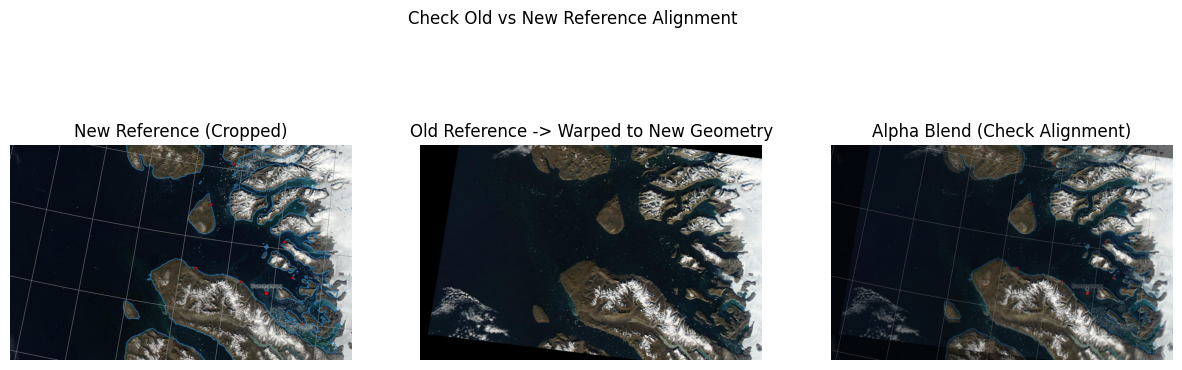

In [3]:
import os
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

##########################
# 1) Cropping & Warping
##########################

CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)
FINAL_COMMON_BOX  = (129, 47, -14, -122)  # example from your pipeline
IMG_SIZE          = (224, 224)

def parse_date_from_filename(filename):
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    return None

def choose_date_crop_box(w, h, file_date):
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)  # old
    else:
        left = 110
        top  = 272
        right  = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_date_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

def final_common_crop(pil_img, final_box=FINAL_COMMON_BOX):
    w, h = pil_img.size
    left, top, right, bottom = final_box
    if right < 0:
        right = w + right
    if bottom < 0:
        bottom = h + bottom
    left   = max(0, left)
    top    = max(0, top)
    right  = min(right, w)
    bottom = min(bottom, h)
    if right <= left or bottom <= top:
        return pil_img
    return pil_img.crop((left, top, right, bottom))

def date_and_final_crop_pil(pil_img, file_date):
    c = date_based_crop(pil_img, file_date)
    f = final_common_crop(c, FINAL_COMMON_BOX)
    return f

##########################
# 2) Compute Homography
##########################

def compute_homography(old_ref_path, new_ref_path):
    """
    Returns H (old->new) and (width, height) of the new reference after the same cropping.
    """
    old_date = parse_date_from_filename(old_ref_path)
    new_date = parse_date_from_filename(new_ref_path)
    
    old_img = Image.open(old_ref_path).convert("RGB")
    old_img = date_and_final_crop_pil(old_img, old_date)
    old_bgr = cv2.cvtColor(np.array(old_img), cv2.COLOR_RGB2BGR)
    old_gray= cv2.cvtColor(old_bgr, cv2.COLOR_BGR2GRAY)

    new_img = Image.open(new_ref_path).convert("RGB")
    new_img = date_and_final_crop_pil(new_img, new_date)
    new_bgr = cv2.cvtColor(np.array(new_img), cv2.COLOR_RGB2BGR)
    new_gray= cv2.cvtColor(new_bgr, cv2.COLOR_BGR2GRAY)
    
    orb = cv2.ORB_create(nfeatures=2000)
    kp_o, des_o = orb.detectAndCompute(old_gray, None)
    kp_n, des_n = orb.detectAndCompute(new_gray, None)
    
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw_matches = matcher.knnMatch(des_o, des_n, k=2)
    good = [m for m, n in raw_matches if m.distance < 0.75*n.distance]
    if len(good) < 10:
        raise ValueError("Not enough matches between old_ref & new_ref")
    
    old_pts = np.float32([kp_o[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    new_pts = np.float32([kp_n[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    
    H, _ = cv2.findHomography(old_pts, new_pts, cv2.RANSAC, 5.0)
    if H is None:
        raise ValueError("Homography computation failed")
    
    h_new, w_new = new_gray.shape
    print("Homography computed successfully.")
    return H, (w_new, h_new)

##########################
# 3) Overlay Old->New
##########################

def warp_old_reference_to_new(old_ref_path, H, new_size):
    """
    Warps the old reference image to new geometry for comparison.
    Returns a PIL image in the same geometry as the new reference.
    """
    date_obj = parse_date_from_filename(old_ref_path)
    # apply date-based + final crop
    old_img = Image.open(old_ref_path).convert("RGB")
    old_img = date_and_final_crop_pil(old_img, date_obj)
    # warp
    bgr = cv2.cvtColor(np.array(old_img), cv2.COLOR_RGB2BGR)
    (w_new, h_new) = new_size
    warped = cv2.warpPerspective(bgr, H, (w_new, h_new), flags=cv2.INTER_LINEAR)
    warped_pil = Image.fromarray(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    return warped_pil

def load_cropped_new_reference(new_ref_path):
    """
    Loads + date/final-crops the new reference so that it matches the geometry used in homography.
    """
    d = parse_date_from_filename(new_ref_path)
    new_img = Image.open(new_ref_path).convert("RGB")
    new_crop = date_and_final_crop_pil(new_img, d)
    return new_crop

def alpha_blend(imgA, imgB, alpha=0.5):
    """
    Alpha-blends two images of the same size, returning a new PIL image.
    """
    return Image.blend(imgA, imgB, alpha)

def visualize_old_vs_new_alignment(old_ref_path, new_ref_path, H):
    """
    1) Warp the old reference to the new reference geometry using H.
    2) Load the new reference after the same crops.
    3) Display side by side:
       (A) The new reference
       (B) The warped old reference
       (C) alpha-blended overlay to see if they align
    """
    # Load the new reference (cropped) so it's the same geometry.
    new_cropped = load_cropped_new_reference(new_ref_path)
    w_new, h_new = new_cropped.size  # the final size after date+final cropping
    
    # Warp the old reference to match that new geometry.
    # We pass H and the new_cropped's size as new_size=(w_new, h_new).
    warped_old = warp_old_reference_to_new(old_ref_path, H, (w_new, h_new))
    
    # If they differ in size by a pixel or two, unify them.
    if warped_old.size != new_cropped.size:
        # possibly a small mismatch if bounding boxes got truncated
        # unify by min dimension or skip
        pass
    
    # Let's do an alpha blend to see if they align well.
    overlay = alpha_blend(new_cropped, warped_old, alpha=0.5)
    
    # Then show them side by side
    fig, axs = plt.subplots(1,3, figsize=(15,5))
    axs[0].imshow(new_cropped)
    axs[0].set_title("New Reference (Cropped)")
    axs[0].axis("off")
    
    axs[1].imshow(warped_old)
    axs[1].set_title("Old Reference -> Warped to New Geometry")
    axs[1].axis("off")
    
    axs[2].imshow(overlay)
    axs[2].set_title("Alpha Blend (Check Alignment)")
    axs[2].axis("off")
    
    plt.suptitle("Check Old vs New Reference Alignment")
    plt.show()

##########################
# 4) Main Demo
##########################
if __name__ == "__main__":
    # Example usage:
    old_ref_path = "data/satellite/aqua/2012/20120828_AQUA.jpg"
    new_ref_path = "data/satellite/aqua/2020/20200717_AQUA.jpg"
    
    # 1) Compute homography from old->new references (after same date+final crops).
    H, (w_new, h_new) = compute_homography(old_ref_path, new_ref_path)
    
    # 2) Visualize them
    visualize_old_vs_new_alignment(old_ref_path, new_ref_path, H)


In [2]:
import cv2
import numpy as np
from PIL import Image

def ecc_align_images(template_img, input_img, warp_mode=cv2.MOTION_AFFINE, number_of_iterations=5000, termination_eps=1e-10):
    """
    Aligns input_img to template_img using the ECC algorithm.
    Returns the warped input_img and the warp matrix.
    """
    template_gray = cv2.cvtColor(np.array(template_img), cv2.COLOR_RGB2GRAY)
    input_gray = cv2.cvtColor(np.array(input_img), cv2.COLOR_RGB2GRAY)

    # Set the warp matrix (identity initial guess)
    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        warp_matrix = np.eye(3, 3, dtype=np.float32)
    else:
        warp_matrix = np.eye(2, 3, dtype=np.float32)

    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, number_of_iterations, termination_eps)
    
    cc, warp_matrix = cv2.findTransformECC(template_gray, input_gray, warp_matrix, warp_mode, criteria)
    
    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        aligned = cv2.warpPerspective(np.array(input_img), warp_matrix, (template_img.width, template_img.height), flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    else:
        aligned = cv2.warpAffine(np.array(input_img), warp_matrix, (template_img.width, template_img.height), flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    
    return Image.fromarray(aligned), warp_matrix

# Example usage:
template = Image.open("data/satellite/aqua/2020/20200717_AQUA.jpg").convert("RGB")
input_img = Image.open("data/satellite/aqua/2012/20120828_AQUA.jpg").convert("RGB")
aligned_img_ecc, ecc_warp = ecc_align_images(template, input_img)
aligned_img_ecc.show()  # Visual inspection


=== Visualizing Intermediate Pipeline States with Water Mask Overlay ===


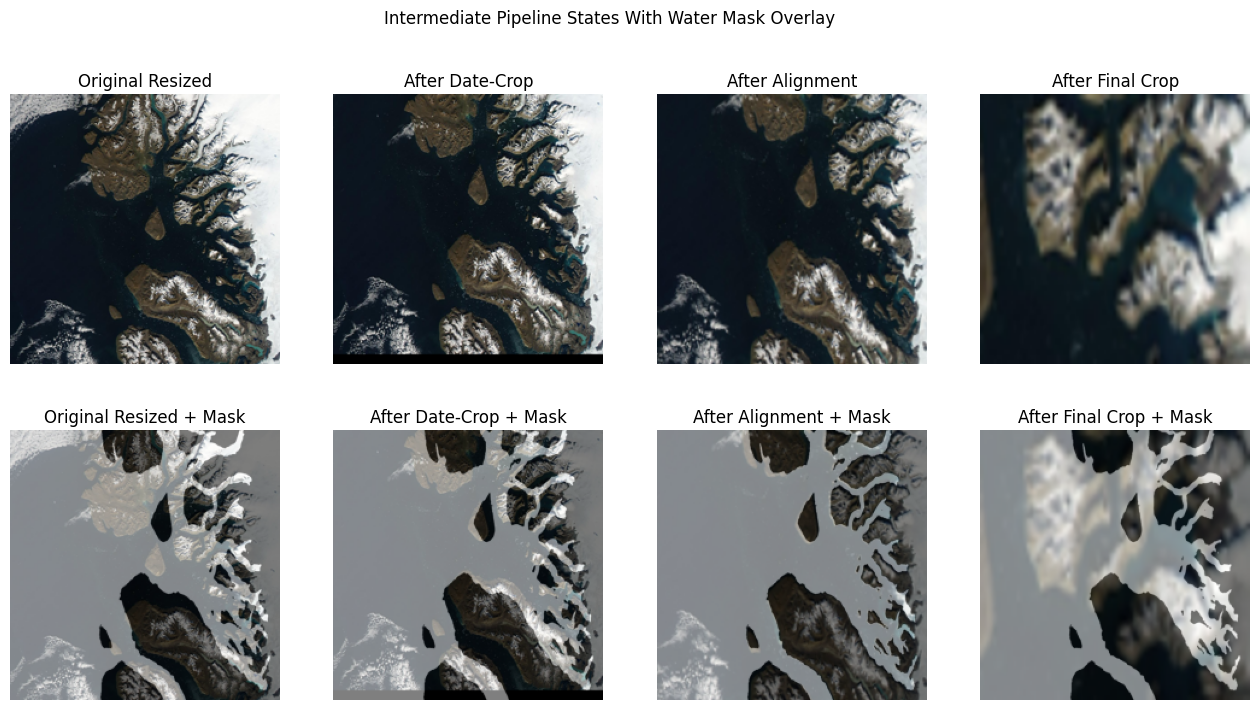

=== Visualizing Overlay Using ECC Alignment ===


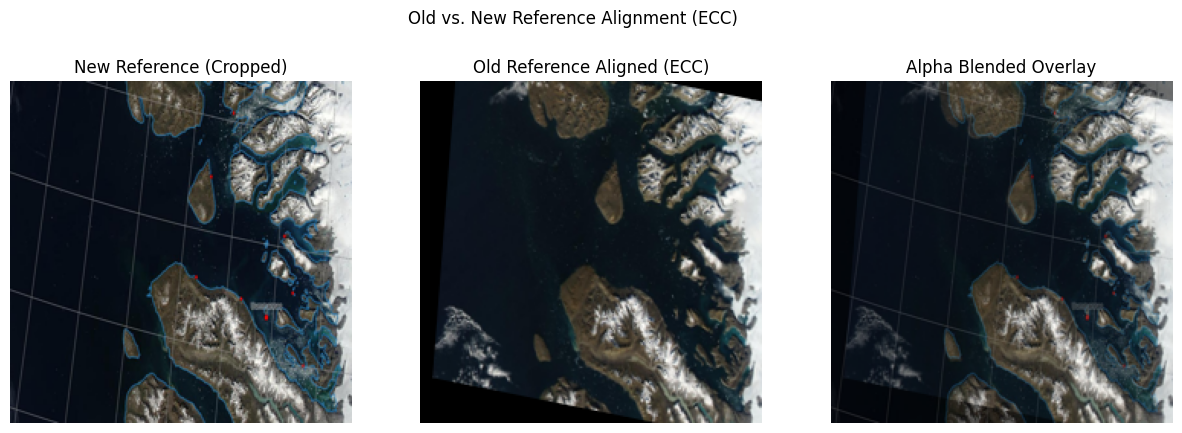

=== Visualizing Overlay Using Phase Correlation Alignment ===


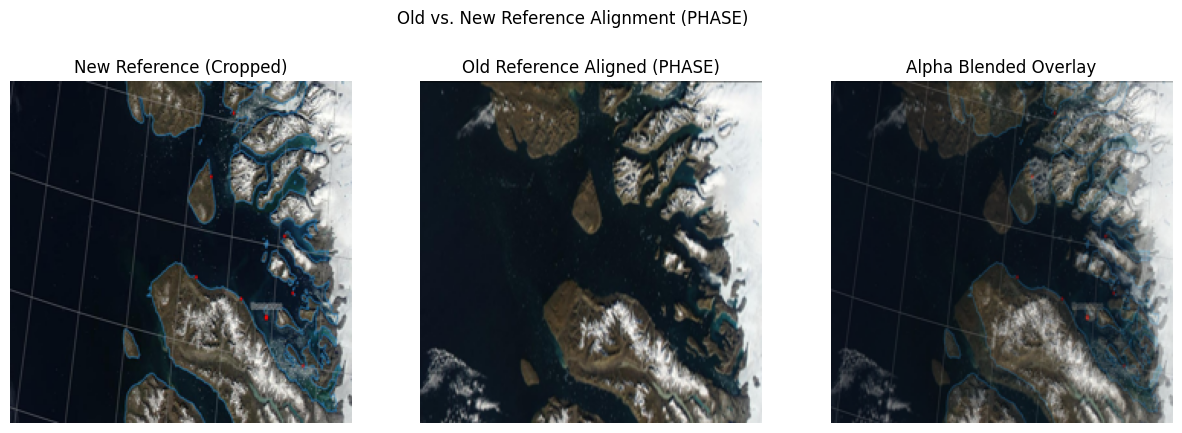

In [1]:
#############################
# FULL PIPELINE: INTERMEDIATE STATES WITH WATER MASK OVERLAY
# (This example runs entirely in memory so that disk space is conserved)
#############################

# ----- 1. Import Statements -----
import os
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

# ----- 2. Global Parameters & Settings -----
CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)
# FINAL_COMMON_BOX: a fixed crop applied after alignment;
# negative right/bottom indicate offsets from the image's right/bottom edges.
FINAL_COMMON_BOX = (129, 47, -14, -122)
IMG_SIZE = (224, 224)  # All images for visualization will be resized here.

# Reference images (used for computing alignment and as the target geometry).
OLD_REF_PATH = "data/satellite/aqua/2012/20120828_AQUA.jpg"   # Pre-2016, old reference image
NEW_REF_PATH = "data/satellite/aqua/2020/20200717_AQUA.jpg"   # Post-2016, new reference image

# ----- 3. Cropping Functions -----
def parse_date_from_filename(filename):
    """
    Extracts the date (YYYYMMDD) from the beginning of the filename.
    E.g., "20120828_AQUA.jpg" → datetime(2012, 8, 28)
    """
    base = os.path.basename(filename)
    match = re.match(r"(\d{8})", base)
    if match:
        return datetime.strptime(match.group(1), "%Y%m%d")
    return None

def choose_date_crop_box(w, h, file_date):
    """
    Chooses a crop box based on the image's date.
      - For old images (date < June 5, 2016): returns (0, 200, 1200, 1030)
      - For new images: returns (110, 272, w - 437, h - 113)
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)
    else:
        left = 110
        top = 272
        right = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    """
    Converts image to RGB and applies the date-based crop.
    This removes the "beam" from old images.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_date_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

def final_common_crop(pil_img, final_box=FINAL_COMMON_BOX):
    """
    Applies a final fixed crop to remove unwanted black borders.
    Negative right/bottom values mean "from the right/bottom edge."
    """
    w, h = pil_img.size
    left, top, right, bottom = final_box
    if right < 0:
        right = w + right
    if bottom < 0:
        bottom = h + bottom
    left = max(0, left)
    top  = max(0, top)
    right = min(right, w)
    bottom = min(bottom, h)
    if right <= left or bottom <= top:
        return pil_img
    return pil_img.crop((left, top, right, bottom))

def date_and_final_crop_pil(pil_img, file_date):
    """
    Applies the date-based crop first, then the final fixed crop.
    This combined crop is applied identically to all images.
    """
    cropped = date_based_crop(pil_img, file_date)
    return final_common_crop(cropped, FINAL_COMMON_BOX)

# ----- 4. Mask Loading -----
def load_water_mask(mask_path, final_size=(224,224)):
    """
    Loads the water mask image (from a new image, where water=255, land=0),
    applies the same final common crop so that it matches the final image,
    resizes it to final_size, and scales pixel values to [0, 1].
    """
    with Image.open(mask_path) as mask_img:
        mask_img = mask_img.convert("L")
        mask_img = final_common_crop(mask_img, FINAL_COMMON_BOX)
        mask_img = mask_img.resize(final_size)
        mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
    return mask_arr

# ----- 5. Alignment Functions -----
# (A) ECC-Based Alignment
def ecc_align_images(template_img, input_img, warp_mode=cv2.MOTION_AFFINE, number_of_iterations=5000, termination_eps=1e-10):
    """
    Aligns input_img to template_img using the Enhanced Correlation Coefficient (ECC) algorithm.
    Both images (PIL) are resized to IMG_SIZE and converted to grayscale.
    Returns the aligned image (as a PIL image) and the warp matrix.
    """
    # Resize both images to the target resolution.
    template_img = template_img.resize(IMG_SIZE)
    input_img = input_img.resize(IMG_SIZE)
    
    template_gray = cv2.cvtColor(np.array(template_img), cv2.COLOR_RGB2GRAY).astype(np.float32)
    input_gray = cv2.cvtColor(np.array(input_img), cv2.COLOR_RGB2GRAY).astype(np.float32)
    
    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        warp_matrix = np.eye(3, 3, dtype=np.float32)
    else:
        warp_matrix = np.eye(2, 3, dtype=np.float32)
    
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, number_of_iterations, termination_eps)
    try:
        cc, warp_matrix = cv2.findTransformECC(template_gray, input_gray, warp_matrix, warp_mode, criteria)
    except cv2.error as e:
        print("ECC alignment failed:", e)
        return input_img, None

    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        aligned = cv2.warpPerspective(np.array(input_img), warp_matrix, (template_img.width, template_img.height),
                                      flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    else:
        aligned = cv2.warpAffine(np.array(input_img), warp_matrix, (template_img.width, template_img.height),
                                 flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    
    return Image.fromarray(aligned), warp_matrix

# (B) Phase Correlation Alignment
def phase_correlation_align(template_img, input_img):
    """
    Aligns input_img to template_img using phase correlation.
    Both images are resized to IMG_SIZE to ensure same dimensions.
    Returns the aligned image and the translation matrix.
    """
    template_img = template_img.resize(IMG_SIZE)
    input_img = input_img.resize(IMG_SIZE)
    template_gray = cv2.cvtColor(np.array(template_img), cv2.COLOR_RGB2GRAY).astype(np.float32)
    input_gray = cv2.cvtColor(np.array(input_img), cv2.COLOR_RGB2GRAY).astype(np.float32)
    
    shift, response = cv2.phaseCorrelate(template_gray, input_gray)
    # shift returns (dy, dx)
    shift_y, shift_x = shift[0], shift[1]
    M = np.float32([[1, 0, shift_x],
                    [0, 1, shift_y]])
    aligned = cv2.warpAffine(np.array(input_img), M, IMG_SIZE, flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    return Image.fromarray(aligned), M

# ----- 6. Alpha Blending -----
def alpha_blend(imgA, imgB, alpha=0.5):
    """
    Creates an alpha-blended overlay of two images.
    The images must be the same size.
    """
    return Image.blend(imgA, imgB, alpha)

# ----- 7. Process the New Reference -----
def load_cropped_new_reference(new_ref_path):
    """
    Loads the new reference image and processes it using our combined crop.
    This defines the target geometry.
    """
    date_obj = parse_date_from_filename(new_ref_path)
    new_img = Image.open(new_ref_path).convert("RGB")
    return date_and_final_crop_pil(new_img, date_obj)

# ----- 8. Generate Intermediate Pipeline States with Mask Overlay -----
def get_pipeline_states_with_mask(image_path, H, ref_size, water_mask):
    """
    Processes a given old image (pre-2016) through the following states:
      State 1: Original image resized.
      State 2: After date-based crop.
      State 3: After ECC or Phase alignment (warped) to new geometry.
      State 4: After final common crop.
    For each state, a version with the water mask (processed via load_water_mask) is generated
    using a simple overlay (using alpha blend).
    Returns two lists:
      states: The raw state images.
      masked_states: The corresponding states with the water mask overlaid.
    """
    date_obj = parse_date_from_filename(image_path)
    
    # State 1: Original resized.
    orig_img = Image.open(image_path).convert("RGB")
    state1 = orig_img.resize(IMG_SIZE)
    
    # State 2: After date-based crop.
    state2 = date_based_crop(orig_img, date_obj).resize(IMG_SIZE)
    
    # State 3: After alignment (only applies if image is old).
    # Here we use ECC alignment; you can easily swap to phase if desired.
    if date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
        state3_input = date_based_crop(orig_img, date_obj)
        # Use ECC alignment with new reference (processed below)
        new_ref = load_cropped_new_reference(NEW_REF_PATH).resize(IMG_SIZE)
        aligned_img, _ = ecc_align_images(new_ref, state3_input, warp_mode=cv2.MOTION_AFFINE)
        state3 = aligned_img.resize(IMG_SIZE)
    else:
        state3 = state2.copy()
    
    # State 4: After final common crop is applied.
    state4 = final_common_crop(state3, FINAL_COMMON_BOX).resize(IMG_SIZE)
    
    # Now, for each state, create a masked version by overlaying the water mask (using alpha blend).
    def overlay_mask(state_img):
        return alpha_blend(state_img, Image.fromarray((water_mask*255).astype(np.uint8)).convert("RGB").resize(IMG_SIZE), alpha=0.5)
    
    masked_states = [overlay_mask(state) for state in [state1, state2, state3, state4]]
    states = [state1, state2, state3, state4]
    return states, masked_states

def visualize_pipeline_states_with_mask(image_path, H, ref_size, water_mask):
    """
    Displays a grid that shows each state (top row) and the same state with the water mask overlaid (bottom row).
    This allows you to inspect whether the mask correctly aligns with the final region.
    """
    states, masked_states = get_pipeline_states_with_mask(image_path, H, ref_size, water_mask)
    titles = ["Original Resized", "After Date-Crop", "After Alignment", "After Final Crop"]
    n = len(states)
    
    fig, axs = plt.subplots(2, n, figsize=(4*n, 8))
    for i in range(n):
        axs[0, i].imshow(states[i])
        axs[0, i].set_title(titles[i])
        axs[0, i].axis("off")
        axs[1, i].imshow(masked_states[i])
        axs[1, i].set_title(titles[i] + " + Mask")
        axs[1, i].axis("off")
    plt.suptitle("Intermediate Pipeline States With Water Mask Overlay")
    plt.show()

# ----- 9. Visualize Final Overlay of Old vs. New Reference -----
def visualize_old_vs_new_alignment(old_ref_path, new_ref_path, method="ECC"):
    """
    Processes the new and old reference images (using the combined cropping),
    aligns the old reference to the new reference (using ECC or Phase correlation), and
    creates an alpha-blended overlay.
    """
    # Process the new reference image.
    new_date = parse_date_from_filename(new_ref_path)
    new_cropped = date_and_final_crop_pil(Image.open(new_ref_path).convert("RGB"), new_date)
    new_cropped = new_cropped.resize(IMG_SIZE)
    
    # Process the old reference image.
    old_date = parse_date_from_filename(old_ref_path)
    old_processed = date_and_final_crop_pil(Image.open(old_ref_path).convert("RGB"), old_date)
    old_processed = old_processed.resize(IMG_SIZE)
    
    # Align the old reference to the new using the selected method.
    if method.upper() == "ECC":
        aligned_old, warp_matrix = ecc_align_images(new_cropped, old_processed, warp_mode=cv2.MOTION_AFFINE)
    elif method.upper() == "PHASE":
        aligned_old, warp_matrix = phase_correlation_align(new_cropped, old_processed)
    else:
        raise ValueError("Unknown alignment method. Use 'ECC' or 'Phase'.")
    
    aligned_old = aligned_old.resize(IMG_SIZE)
    overlay = alpha_blend(new_cropped, aligned_old, alpha=0.5)
    
    # Display side-by-side: new reference, aligned old reference, overlay.
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(new_cropped)
    axs[0].set_title("New Reference (Cropped)")
    axs[0].axis("off")
    
    axs[1].imshow(aligned_old)
    axs[1].set_title("Old Reference Aligned (" + method + ")")
    axs[1].axis("off")
    
    axs[2].imshow(overlay)
    axs[2].set_title("Alpha Blended Overlay")
    axs[2].axis("off")
    
    plt.suptitle("Old vs. New Reference Alignment (" + method + ")")
    plt.show()

# ----- 10. Main Testing Section -----
if __name__ == "__main__":
    # First, compute the homography using ECC on the two reference images.
    # (For example, we can compute an ECC alignment and then use that transform
    # for further processing; here we will use ECC for intermediate states.)
    # For our visualization of intermediate states, we don't need H to be passed
    # to the overlay function because we are performing alignment within get_pipeline_states_with_mask.
    # However, for consistency, we compute the warping using our ECC function.
    
    # Load the water mask once.
    water_mask = load_water_mask("data/satellite/aqua/mask/mask_AQUA.jpg", final_size=IMG_SIZE)
    
    # Visualize the intermediate pipeline states (with mask overlay) for a selected old image.
    sample_old_image = OLD_REF_PATH  # Using the old reference as example.
    print("=== Visualizing Intermediate Pipeline States with Water Mask Overlay ===")
    # Here we use ECC alignment in the intermediate pipeline.
    visualize_pipeline_states_with_mask(sample_old_image, H=None, ref_size=None, water_mask=water_mask)
    # In our get_pipeline_states_with_mask() above, if H is needed (for warping old images),
    # you can compute it as follows: (for instance, by aligning the old reference to the new reference)
    # However, for our intermediate states here, we already internally use ECC alignment.
    # 
    # Now, visualize the overlay of the old reference onto the new reference,
    # using both ECC and Phase methods.
    print("=== Visualizing Overlay Using ECC Alignment ===")
    visualize_old_vs_new_alignment(OLD_REF_PATH, NEW_REF_PATH, method="ECC")
    print("=== Visualizing Overlay Using Phase Correlation Alignment ===")
    visualize_old_vs_new_alignment(OLD_REF_PATH, NEW_REF_PATH, method="PHASE")


In [ ]:
#############################
# FULL PIPELINE WITH OFFLINE ALIGNMENT (OLD -> NEW GEOMETRY),
# FINAL CROPPING, & MASK OVERLAY – IN‐MEMORY PROCESSING
# Incorporates fixes so that:
#  - "After date-based crop" truly happens first,
#  - Then alignment references the new reference at full resolution,
#  - Then the final bounding box is applied,
#  - Finally, we downsample to IMG_SIZE.
#############################

import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtTiny
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras import Model

#############################
# 1) GLOBAL PARAMETERS
#############################
CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)
# A final bounding box, applied AFTER alignment, to remove leftover edges/frames.
# Negative right/bottom => offset from the image's right/bottom.
FINAL_COMMON_BOX = (129, 47, -14, -122)
IMG_SIZE = (224, 224)  # Final model input resolution

# Our reference paths: one old, one new
OLD_REF_PATH = "data/satellite/aqua/2012/20120828_AQUA.jpg"  # Pre-2016
NEW_REF_PATH = "data/satellite/aqua/2020/20200717_AQUA.jpg"  # Post-2016

TRAIN_IN = "data/train"       # subfolders: sea_ice / no_ice / cloudy
LEFTOVER_DIR = "data/leftover"

#############################
# 2) CROPPING FUNCTIONS
#############################
def parse_date_from_filename(filename):
    """
    Extract YYYYMMDD from the start of the filename (e.g. 20120828_AQUA.jpg -> datetime(2012,8,28)).
    """
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    return None

def choose_date_crop_box(w, h, file_date):
    """
    If old (<2016-06-05): (0, 200, 1200, 1030), else (110,272, w-437, h-113).
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)
    else:
        left = 110
        top = 272
        right = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    """
    Convert to RGB, apply date-based crop at full resolution.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_date_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

def final_common_crop(pil_img, final_box=FINAL_COMMON_BOX):
    """
    A final bounding box for removing leftover edges AFTER alignment.
    Negative right/bottom => offset from the image's right/bottom edges.
    """
    w, h = pil_img.size
    left, top, right, bottom = final_box
    if right < 0:
        right = w + right
    if bottom < 0:
        bottom = h + bottom
    left   = max(0, left)
    top    = max(0, top)
    right  = min(right, w)
    bottom = min(bottom, h)
    if right <= left or bottom <= top:
        return pil_img
    return pil_img.crop((left, top, right, bottom))

#############################
# 3) ECC ALIGNMENT
#############################
def ecc_align_images(template_img, input_img, warp_mode=cv2.MOTION_AFFINE,
                     number_of_iterations=5000, termination_eps=1e-10):
    """
    Aligns 'input_img' to 'template_img' via ECC.
    Both images must be the same size. We'll do it at full resolution.
    Returns (aligned PIL image, warp_matrix).
    """
    if template_img.size != input_img.size:
        raise ValueError("ECC requires the same size for template & input. Resize or unify them first.")
    
    template_gray = cv2.cvtColor(np.array(template_img), cv2.COLOR_RGB2GRAY).astype(np.float32)
    input_gray    = cv2.cvtColor(np.array(input_img),    cv2.COLOR_RGB2GRAY).astype(np.float32)
    
    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        warp_matrix = np.eye(3,3, dtype=np.float32)
    else:
        warp_matrix = np.eye(2,3, dtype=np.float32)

    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, number_of_iterations, termination_eps)
    try:
        _, warp_matrix = cv2.findTransformECC(template_gray, input_gray, warp_matrix,
                                              warp_mode, criteria)
    except cv2.error as e:
        print("ECC alignment failed:", e)
        return input_img, None
    
    w, h = template_img.size
    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        aligned = cv2.warpPerspective(np.array(input_img), warp_matrix, (w,h),
                                      flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    else:
        aligned = cv2.warpAffine(np.array(input_img), warp_matrix, (w,h),
                                 flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    return Image.fromarray(aligned), warp_matrix

#############################
# 4) LOADING THE WATER MASK
#############################
def load_water_mask(mask_path, final_size=(224,224)):
    """
    Loads the mask from a new image (water=255, land=0).
    We do the final common crop at full resolution, then downsample to final_size.
    This ensures it lines up with the final processed images.
    """
    with Image.open(mask_path) as m:
        m = m.convert("L")
        # final crop at full resolution
        m = final_common_crop(m, FINAL_COMMON_BOX)
        # then scale to final model resolution
        m = m.resize(final_size)
        arr = np.array(m, dtype=np.float32)/255.0
    return arr

#############################
# 5) MAIN IMAGE PROCESSING
#############################
def process_training_image(fp_str, H, new_ref_width, new_ref_height, water_mask=None, apply_mask=False):
    """
    Full pipeline for a single training image, in memory:
      1. Opens the image at full resolution.
      2. Applies the date-based crop (full resolution).
      3. If the image is old (date < cutoff) and H is provided, warps the image to the new
         reference geometry (new_ref_width, new_ref_height).
      4. Applies the final common crop at full resolution.
      5. Downsamples to IMG_SIZE.
      6. Optionally overlays the water mask.
    Returns the final processed PIL image.
    """
    date_obj = parse_date_from_filename(fp_str)
    pil_img = Image.open(fp_str).convert("RGB")
    
    # Step 1 & 2: Date-based crop (full resolution).
    date_cropped = date_based_crop(pil_img, date_obj)
    
    # Step 3: If the image is old and H is provided, warp it.
    if H is not None and date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
        # Convert H to a NumPy array of type float32
        H_mod = np.asarray(H, dtype=np.float32)
        # Check the number of elements in H_mod to determine if it's affine (6 elements) or full (9 elements)
        if H_mod.size == 6:
            # Reshape to 2x3 then convert to 3x3 by adding the [0, 0, 1] row
            H_mod = H_mod.reshape((2, 3))
            H_mod = np.vstack([H_mod, np.array([0, 0, 1], dtype=np.float32)])
        elif H_mod.size == 9:
            H_mod = H_mod.reshape((3, 3))
        else:
            raise ValueError("Unexpected shape for H: " + str(H_mod.shape))
        
        bgr = cv2.cvtColor(np.array(date_cropped), cv2.COLOR_RGB2BGR)
        warped = cv2.warpPerspective(bgr, H_mod, (new_ref_width, new_ref_height), flags=cv2.INTER_LINEAR)
        after_align = Image.fromarray(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    else:
        after_align = date_cropped


    
    # Step 4: Apply the final common crop (still at full resolution).
    final_img = final_common_crop(after_align, FINAL_COMMON_BOX)
    
    # Step 5: Downsample to IMG_SIZE.
    final_img = final_img.resize(IMG_SIZE)
    
    # Step 6: Optionally overlay the water mask.
    if apply_mask and water_mask is not None:
        final_img = apply_mask_overlay(final_img, water_mask, alpha=0.5)
    
    return final_img


def apply_mask_overlay(img, water_mask, alpha=0.5):
    """
    Overlays water_mask on 'img' by alpha blending. 
    water_mask is a float array [0..1], shape (224,224).
    """
    mask_img = Image.fromarray((water_mask*255).astype(np.uint8)).convert("RGB")
    mask_img = mask_img.resize(img.size)
    return Image.blend(img, mask_img, alpha)

#############################
# 6) TF DATASET PIPELINE
#############################
def load_image_for_training(fp, lbl, H, new_w, new_h, water_mask=None, apply_mask=False):
    """
    Called inside tf.py_function. Returns arr, label as numpy types.
    """
    fp_str = fp.numpy().decode("utf-8")
    # Full pipeline
    out_img = process_training_image(fp_str, H, new_w, new_h, water_mask, apply_mask)
    arr = np.array(out_img, dtype=np.float32)/255.0
    return arr, lbl.numpy()

def build_dataset(filepaths, labels, H, new_w, new_h, water_mask=None, apply_mask=False,
                  batch_size=8, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        arr, lab = tf.py_function(func=load_image_for_training,
                                  inp=[fp, lbl, H, new_w, new_h, water_mask, apply_mask],
                                  Tout=[tf.float32, tf.int32])
        arr.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
        lab.set_shape(())
        return arr, lab
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

#############################
# 7) MODEL BUILDING
#############################
def build_classifier(base_name="efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True):
    if base_name.lower() == "efficientnetv2":
        base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_name.lower() == "convnext":
        base = ConvNeXtTiny(weights="imagenet", include_top=False, input_shape=(224,224,3))
    else:
        raise ValueError("Unknown base_name:", base_name)
    base.trainable = full_fine_tune
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(base.input, out)
    model.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

#############################
# 8) EVALUATION UTILS
#############################
def evaluate_model_on_test(model, test_ds, class_names):
    all_labels = []
    all_preds = []
    for imgs, lbls in test_ds:
        preds = model.predict(imgs)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(lbls.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print(classification_report(all_labels, all_preds, target_names=class_names))

def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

#############################
# 9) CLASSIFYING NEW IMAGES
#############################
def classify_new_image(image_path, H, new_w, new_h, model, water_mask=None, apply_mask=False):
    """
    Reuses process_training_image at full resolution, then downsampling, to produce an
    array that is fed to the model. Returns predicted label index.
    """
    proc_img = process_training_image(image_path, H, new_w, new_h, water_mask, apply_mask)
    arr = np.array(proc_img, dtype=np.float32)/255.0
    inp = np.expand_dims(arr, axis=0)
    preds = model.predict(inp)
    return np.argmax(preds, axis=1)[0]

def visualize_prediction(image_path, H, new_w, new_h, model, water_mask=None, apply_mask=False):
    lbl_idx = classify_new_image(image_path, H, new_w, new_h, model, water_mask, apply_mask)
    # Show the final cropped+downsized version
    proc_img = process_training_image(image_path, H, new_w, new_h, water_mask, apply_mask)
    plt.figure(figsize=(5,5))
    plt.imshow(proc_img)
    plt.title(f"Predicted Label: {lbl_idx}")
    plt.axis('off')
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    # Just shows the final combined crop => downsample => overlay
    date_obj = parse_date_from_filename(image_path)
    full_img = Image.open(image_path).convert("RGB")
    # minimal pipeline: date-based + final crop => then resize
    combined = date_and_final_crop_pil(full_img, date_obj)
    combined = combined.resize(IMG_SIZE)
    base_arr = np.array(combined, dtype=np.float32)/255.0
    if water_mask is not None:
        mask_3d = np.expand_dims(water_mask, axis=-1)
        masked_arr = base_arr * mask_3d
    else:
        masked_arr = base_arr
    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(base_arr)
    axs[0].set_title("Final Cropped + Resized")
    axs[0].axis('off')
    if water_mask is not None:
        axs[1].imshow(water_mask, cmap='gray')
        axs[1].set_title("Water Mask")
    else:
        axs[1].text(0.5,0.5,"No Mask",ha='center', va='center')
    axs[1].axis('off')
    axs[2].imshow(masked_arr)
    axs[2].set_title("Applied Mask")
    axs[2].axis('off')
    plt.show()

#############################
# 10) HOMOGRAPHY BETWEEN REF IMAGES
#############################
def compute_ref_homography(old_ref_path, new_ref_path):
    """
    1) Do date+final crop on both references at *full resolution*.
    2) Then unify them to the same size for ECC alignment (the new reference's final cropped size).
    3) Compute ECC => returns warp matrix and the new reference's dimension.
    """
    old_date = parse_date_from_filename(old_ref_path)
    new_date = parse_date_from_filename(new_ref_path)
    
    old_full = Image.open(old_ref_path).convert("RGB")
    new_full = Image.open(new_ref_path).convert("RGB")
    
    # date-based crop => final crop, at full res
    old_cropped = date_and_final_crop_pil(old_full, old_date)
    new_cropped = date_and_final_crop_pil(new_full, new_date)
    
    # unify dimension for ECC => pick the new_cropped size as the "master"
    W, H = new_cropped.size
    
    # Resize old => new's dimension
    old_resized = old_cropped.resize((W,H))
    new_resized = new_cropped  # already (W,H)
    
    # ECC
    aligned, warp_matrix = ecc_align_images(new_resized, old_resized,
                                            warp_mode=cv2.MOTION_AFFINE)
    return warp_matrix, (W, H)

#############################
# 11) MAIN ORCHESTRATION
#############################
def main():
    # A) Compute homography referencing the new reference
    print("=== Computing Homography referencing the new reference (full res) ===")
    try:
        H, (new_w, new_h) = compute_ref_homography(OLD_REF_PATH, NEW_REF_PATH)
    except Exception as e:
        print("Homography computation failed:", e)
        return
    
    # B) Visual test of date+final cropping
    print("=== Quick Crop Visualization ===")
    for path in [OLD_REF_PATH, NEW_REF_PATH]:
        pil_img = Image.open(path).convert("RGB")
        date_obj = parse_date_from_filename(path)
        combined = date_and_final_crop_pil(pil_img, date_obj)
        print(f"{path} => final size after date+common crop = {combined.size}")
    
    # C) Load the water mask
    print("=== Loading Water Mask ===")
    water_mask = load_water_mask("data/satellite/aqua/mask/mask_AQUA.jpg", final_size=IMG_SIZE)
    
    # D) Build dataframes for cloud & ice
    print("=== Building DataFrames from TRAIN_IN ===")
    def build_two_step_data(base_dir):
        subs = ["sea_ice", "no_ice", "cloudy"]
        cpaths, clabels = [], []
        ipaths, ilabels = [], []
        for sf in subs:
            fullp = os.path.join(base_dir, sf)
            for fn in os.listdir(fullp):
                if fn.lower().endswith((".jpg",".png")):
                    fp = os.path.join(fullp, fn)
                    # cloud
                    if sf=="cloudy":
                        cpaths.append(fp); clabels.append(1)
                    else:
                        cpaths.append(fp); clabels.append(0)
                    # ice
                    if sf=="sea_ice":
                        ipaths.append(fp); ilabels.append(0)
                    elif sf=="no_ice":
                        ipaths.append(fp); ilabels.append(1)
        df_cloud = pd.DataFrame({"filepath":cpaths, "label":clabels})
        df_ice   = pd.DataFrame({"filepath":ipaths,   "label":ilabels})
        return df_cloud, df_ice
    
    def split_df(df, frac_train=0.8, frac_val=0.1):
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)
        n = len(df)
        n_train = int(frac_train*n)
        n_val   = int(0.1*n)
        df_train = df.iloc[:n_train]
        df_val   = df.iloc[n_train:n_train+n_val]
        df_test  = df.iloc[n_train+n_val:]
        return df_train, df_val, df_test
    
    df_cloud, df_ice = build_two_step_data(TRAIN_IN)
    train_cloud, val_cloud, test_cloud = split_df(df_cloud)
    train_ice,   val_ice,   test_ice   = split_df(df_ice)
    
    # E) Build TF Datasets
    print("=== Building TF Datasets (in memory pipeline) ===")
    def map_func_cloud(fp, lbl):
        # We do the entire pipeline in memory
        fp_str = fp.numpy().decode("utf-8")
        img = process_training_image(fp_str, H, new_w, new_h, water_mask, apply_mask=True)
        arr = np.array(img, dtype=np.float32)/255.0
        return arr, lbl.numpy()
    
    def build_ds(filepaths, labels, shuffle=True, batch=8):
        ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
        if shuffle:
            ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
        
        def _mapper(fp, lab):
            arr, lb = tf.py_function(func=map_func_cloud, inp=[fp, lab],
                                     Tout=[tf.float32, tf.int32])
            arr.set_shape((IMG_SIZE[0], IMG_SIZE[1],3))
            lb.set_shape(())
            return arr, lb
        
        ds = ds.map(_mapper, num_parallel_calls=tf.data.experimental.AUTOTUNE)
        ds = ds.batch(batch).prefetch(tf.data.experimental.AUTOTUNE)
        return ds
    
    train_cloud_ds = build_ds(train_cloud["filepath"].tolist(), train_cloud["label"].tolist(), True, 8)
    val_cloud_ds   = build_ds(val_cloud["filepath"].tolist(),   val_cloud["label"].tolist(), False,8)
    test_cloud_ds  = build_ds(test_cloud["filepath"].tolist(),  test_cloud["label"].tolist(),False,8)
    
    # F) Train Cloud Model
    print("=== Train Cloud Model ===")
    cloud_model = build_classifier("efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True)
    # early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    cloud_checkpoint = ModelCheckpoint("best_cloud_model.h5",
                             monitor="val_loss",
                             verbose=1,
                             save_best_only=True,
                             mode="min")
    hist_cloud = cloud_model.fit(train_cloud_ds, validation_data=val_cloud_ds, epochs=30,
                                #  callbacks=[early_stop, checkpoint]
                                 callbacks=[cloud_checkpoint]
                                 )

    plot_training_history(hist_cloud, "Cloud Classifier")
    print("Evaluate Cloud Model on test set:")
    cloud_model.evaluate(test_cloud_ds)
    evaluate_model_on_test(cloud_model, test_cloud_ds, ["clear","cloudy"])
    
    # G) Train Ice Model
    print("=== Train Ice Model ===")
    def map_func_ice(fp, lbl):
        fp_str = fp.numpy().decode("utf-8")
        img = process_training_image(fp_str, H, new_w, new_h, water_mask, apply_mask=True)
        arr = np.array(img,dtype=np.float32)/255.0
        return arr, lbl.numpy()
    
    def build_ice_ds(filepaths, labels, shuffle=True,batch=8):
        ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
        if shuffle:
            ds = ds.shuffle(len(filepaths))
        def _map_ice(fp, lb):
            ar, l = tf.py_function(func=map_func_ice, inp=[fp, lb],
                                   Tout=[tf.float32, tf.int32])
            ar.set_shape((IMG_SIZE[0], IMG_SIZE[1],3))
            l.set_shape(())
            return ar,l
        ds = ds.map(_map_ice,num_parallel_calls=tf.data.experimental.AUTOTUNE)
        ds = ds.batch(batch).prefetch(tf.data.experimental.AUTOTUNE)
        return ds
    
    train_ice_ds = build_ice_ds(train_ice["filepath"].tolist(), train_ice["label"].tolist(), True, 8)
    val_ice_ds   = build_ice_ds(val_ice["filepath"].tolist(),   val_ice["label"].tolist(),   False,8)
    test_ice_ds  = build_ice_ds(test_ice["filepath"].tolist(),  test_ice["label"].tolist(),  False,8)
    
    ice_model = build_classifier("efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True)
    ice_checkpoint = ModelCheckpoint("best_ice_model.h5",
                             monitor="val_loss",
                             verbose=1,
                             save_best_only=True,
                             mode="min")
    hist_ice = ice_model.fit(train_ice_ds, validation_data=val_ice_ds, epochs=30,
                             callbacks=[ice_checkpoint]
                            #  callbacks=[early_stop, checkpoint]
                             )
    plot_training_history(hist_ice, "Ice Classifier")
    print("Evaluate Ice Model on test set:")
    ice_model.evaluate(test_ice_ds)
    evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice","no_ice"])
    
    # H) Inference on leftover images
    print("=== Inference on leftover images ===")
    leftover_files = [os.path.join(LEFTOVER_DIR,f)
                      for f in os.listdir(LEFTOVER_DIR)
                      if f.lower().endswith(".jpg")]
    for lf in leftover_files:
        cloud_lbl = classify_new_image(lf, H, new_w, new_h, cloud_model, water_mask=None, apply_mask=False)
        if cloud_lbl == 1:
            result = "Cloudy"
        else:
            ice_lbl = classify_new_image(lf, H, new_w, new_h, ice_model, water_mask=None, apply_mask=False)
            result = "Sea Ice" if (ice_lbl==0) else "No Ice"
        print(f"{lf} => {result}")
    
    # I) Visualization
    example_path = NEW_REF_PATH
    visualize_prediction(example_path, H, new_w, new_h, cloud_model, water_mask=None, apply_mask=False)
    visualize_mask_alignment(example_path, water_mask)

    print("=== Pipeline Complete ===")

if __name__ == "__main__":
    main()


=== Computing Homography referencing the new reference (full res) ===
=== Quick Crop Visualization ===
data/satellite/aqua/2012/20120828_AQUA.jpg => final size after date+common crop = (1200, 830)
data/satellite/aqua/2020/20200717_AQUA.jpg => final size after date+common crop = (1193, 830)
=== Loading Water Mask ===
=== Building DataFrames from TRAIN_IN ===
=== Building TF Datasets (in memory pipeline) ===
=== Train Cloud Model ===
Epoch 1/30


=== Computing Homography referencing the new reference (full res) ===
=== Quick Crop Visualization ===
data/satellite/aqua/2012/20120828_AQUA.jpg => final size after date+common crop = (1200, 830)
data/satellite/aqua/2020/20200717_AQUA.jpg => final size after date+common crop = (1193, 830)
=== Loading Water Mask ===
=== Building DataFrames from TRAIN_IN ===
=== Building TF Datasets (in memory pipeline) ===
=== Train Cloud Model ===


2025-04-10 12:54:59.590572: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-04-10 12:54:59.590596: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-04-10 12:54:59.590602: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
I0000 00:00:1744282499.590890 18580305 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1744282499.591071 18580305 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2025-04-10 12:55:12.255898: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5191 - loss: 0.7147
Epoch 1: val_loss improved from inf to 0.70513, saving model to best_cloud_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.5207 - loss: 0.7136 - val_accuracy: 0.6129 - val_loss: 0.7051
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7746 - loss: 0.5494
Epoch 2: val_loss improved from 0.70513 to 0.67034, saving model to best_cloud_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7753 - loss: 0.5485 - val_accuracy: 0.7097 - val_loss: 0.6703
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8782 - loss: 0.4462
Epoch 3: val_loss improved from 0.67034 to 0.34992, saving model to best_cloud_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8777 - loss: 0.4457 - val_accuracy: 0.9677 - val_loss: 0.3499
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8866 - loss: 0.3623
Epoch 4: val_loss improved from 0.34992 to 0.23689, saving model

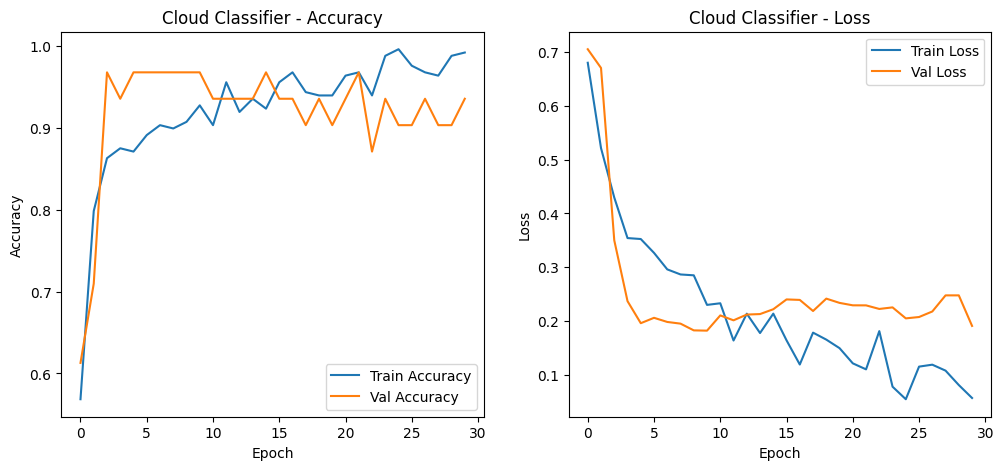

Evaluate Cloud Model on test set:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9667 - loss: 0.0698
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Confusion Matrix:
 [[21  1]
 [ 0 10]]
              precision    recall  f1-score   support

       clear       1.00      0.95      0.98        22
      cloudy       0.91      1.00      0.95        10

    accuracy                           0.97        32
   macro avg       0.95      0.98      0.96        32
weighted avg       0.97      0.97      0.97        32

=== Train Ice Model ===


2025-04-10 13:22:23.082396: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5843 - loss: 0.6844
Epoch 1: val_loss improved from inf to 0.71119, saving model to best_ice_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.5867 - loss: 0.6833 - val_accuracy: 0.3500 - val_loss: 0.7112
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8971 - loss: 0.4753
Epoch 2: val_loss improved from 0.71119 to 0.68749, saving model to best_ice_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8962 - loss: 0.4750 - val_accuracy: 0.6000 - val_loss: 0.6875
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9162 - loss: 0.4103
Epoch 3: val_loss did not improve from 0.68749
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9162 - loss: 0.4095 - val_accuracy: 0.5500 - val_loss: 0.6984
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9079 - loss: 0.3417
Epoch 4: val_loss improved from 0.68749 to 0.50624, saving model to best_ice_model.keras
21/21 ━━━━━━

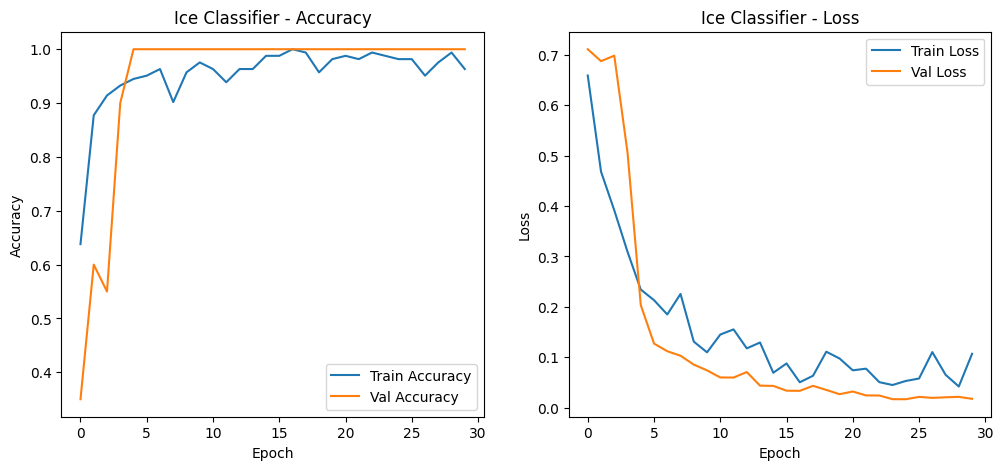

Evaluate Ice Model on test set:
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 1.0000 - loss: 0.0183 
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Confusion Matrix:
 [[ 8  0]
 [ 0 13]]
              precision    recall  f1-score   support

     sea_ice       1.00      1.00      1.00         8
      no_ice       1.00      1.00      1.00        13

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

=== Inference on leftover images ===


2025-04-10 13:43:33.997758: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


FileNotFoundError: [Errno 2] No such file or directory: 'data/leftover'

In [1]:
#############################
# FULL PIPELINE WITH OFFLINE ALIGNMENT (OLD -> NEW GEOMETRY),
# FINAL CROPPING, & MASK OVERLAY – IN‐MEMORY PROCESSING
# Incorporates fixes so that:
#  - "After date-based crop" truly happens first,
#  - Then alignment references the new reference at full resolution,
#  - Then the final bounding box is applied,
#  - Finally, we downsample to IMG_SIZE.
#############################

import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtTiny
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras import Model

#############################
# 1) GLOBAL PARAMETERS
#############################
CUTOFF_NEW_FORMAT = datetime(2016, 6, 5)
# A final bounding box, applied AFTER alignment, to remove leftover edges/frames.
# Negative right/bottom => offset from the image's right/bottom.
FINAL_COMMON_BOX = (129, 47, -14, -122)
IMG_SIZE = (224, 224)  # Final model input resolution

# Our reference paths: one old, one new
OLD_REF_PATH = "data/satellite/aqua/2012/20120828_AQUA.jpg"  # Pre-2016
NEW_REF_PATH = "data/satellite/aqua/2020/20200717_AQUA.jpg"  # Post-2016

TRAIN_IN = "data/train"       # subfolders: sea_ice / no_ice / cloudy
LEFTOVER_DIR = "data/leftover"

#############################
# 2) CROPPING FUNCTIONS
#############################
def parse_date_from_filename(filename):
    """
    Extract YYYYMMDD from the start of the filename (e.g. 20120828_AQUA.jpg -> datetime(2012,8,28)).
    """
    base = os.path.basename(filename)
    match = re.match(r'(\d{8})', base)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    return None

def choose_date_crop_box(w, h, file_date):
    """
    If old (<2016-06-05): (0, 200, 1200, 1030), else (110,272, w-437, h-113).
    """
    if file_date is None:
        return None
    if file_date < CUTOFF_NEW_FORMAT:
        return (0, 200, 1200, 1030)
    else:
        left = 110
        top = 272
        right = w - 437
        bottom = h - 113
        if right <= left or bottom <= top:
            return None
        return (left, top, right, bottom)

def date_based_crop(pil_img, file_date):
    """
    Convert to RGB, apply date-based crop at full resolution.
    """
    pil_img = pil_img.convert("RGB")
    w, h = pil_img.size
    box = choose_date_crop_box(w, h, file_date)
    if box is None:
        return pil_img
    return pil_img.crop(box)

def final_common_crop(pil_img, final_box=FINAL_COMMON_BOX):
    """
    A final bounding box for removing leftover edges AFTER alignment.
    Negative right/bottom => offset from the image's right/bottom edges.
    """
    w, h = pil_img.size
    left, top, right, bottom = final_box
    if right < 0:
        right = w + right
    if bottom < 0:
        bottom = h + bottom
    left   = max(0, left)
    top    = max(0, top)
    right  = min(right, w)
    bottom = min(bottom, h)
    if right <= left or bottom <= top:
        return pil_img
    return pil_img.crop((left, top, right, bottom))

def date_and_final_crop_pil(pil_img, file_date):
    """
    Applies the date-based crop followed by the final common crop to the given PIL image.
    Both operations are performed at the image's full resolution.
    """
    cropped = date_based_crop(pil_img, file_date)
    # return final_common_crop(cropped, FINAL_COMMON_BOX)
    return cropped

def get_pipeline_states_with_mask(image_path, H, new_ref_width, new_ref_height, water_mask):
    """
    Processes the input image through several stages:
      - Original (resized to IMG_SIZE)
      - After date-based crop (full resolution, then downsampled)
      - After alignment (if applicable) and downsampled
      - After final common crop (full resolution, then downsampled)
    For each state, also creates a version with the water mask overlaid.
    Returns two lists: one for the raw states and one for the masked states.
    """
    date_obj = parse_date_from_filename(image_path)
    
    # Load full-resolution image
    original_full = Image.open(image_path).convert("RGB")
    original_resized = original_full.resize(IMG_SIZE)
    
    # State 1: After date-based crop
    date_cropped = date_based_crop(original_full, date_obj)
    state_date_crop = date_cropped.resize(IMG_SIZE)
    
    # State 2: After alignment (only if image is old and H is provided)
    if H is not None and date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
        # Get the date-cropped image (full resolution)
        aligned_full = date_cropped
        # Process H: convert to float32 and make sure it is 3x3.
        H_mod = np.asarray(H, dtype=np.float32)
        if H_mod.size == 6:
            H_mod = H_mod.reshape((2, 3))
            H_mod = np.vstack([H_mod, np.array([0, 0, 1], dtype=np.float32)])
        elif H_mod.size == 9:
            H_mod = H_mod.reshape((3, 3))
        else:
            raise ValueError("Unexpected shape for H: " + str(H_mod.shape))
        # Warp the date-cropped full res image to the new reference geometry:
        bgr = cv2.cvtColor(np.array(aligned_full), cv2.COLOR_RGB2BGR)
        warped = cv2.warpPerspective(bgr, H_mod, (new_ref_width, new_ref_height), flags=cv2.INTER_LINEAR)
        state_aligned = Image.fromarray(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)).resize(IMG_SIZE)
    else:
        state_aligned = state_date_crop.copy()

    # State 3: After final common crop (applied on the aligned image)
    state_final = final_common_crop(state_aligned, FINAL_COMMON_BOX).resize(IMG_SIZE)
    
    # Prepare lists of states and their masked versions
    states = [original_resized, state_date_crop, state_aligned, state_final]
    def overlay_mask(img):
        return apply_mask_overlay(img, water_mask, alpha=0.5)
    masked_states = [overlay_mask(s) for s in states]
    
    return states, masked_states

def visualize_pipeline_states_with_mask(image_path, H, new_ref_width, new_ref_height, water_mask):
    """
    Displays a 2-row grid: the top row contains the intermediate pipeline states,
    and the bottom row shows the corresponding states with the water mask applied.
    """
    states, masked_states = get_pipeline_states_with_mask(image_path, H, new_ref_width, new_ref_height, water_mask)
    titles = ["Original Resized", "After Date Crop", "After Alignment", "After Final Crop"]
    
    fig, axs = plt.subplots(2, len(states), figsize=(4 * len(states), 8))
    for i in range(len(states)):
        axs[0, i].imshow(states[i])
        axs[0, i].set_title(titles[i])
        axs[0, i].axis("off")
        axs[1, i].imshow(masked_states[i])
        axs[1, i].set_title(titles[i] + " + Mask")
        axs[1, i].axis("off")
    plt.suptitle("Intermediate Pipeline States With Water Mask Overlay")
    plt.show()

#############################
# 3) ECC ALIGNMENT
#############################
def ecc_align_images(template_img, input_img, warp_mode=cv2.MOTION_AFFINE,
                     number_of_iterations=5000, termination_eps=1e-10):
    """
    Aligns 'input_img' to 'template_img' via ECC.
    Both images must be the same size. We'll do it at full resolution.
    Returns (aligned PIL image, warp_matrix).
    """
    if template_img.size != input_img.size:
        raise ValueError("ECC requires the same size for template & input. Resize or unify them first.")
    
    template_gray = cv2.cvtColor(np.array(template_img), cv2.COLOR_RGB2GRAY).astype(np.float32)
    input_gray    = cv2.cvtColor(np.array(input_img),    cv2.COLOR_RGB2GRAY).astype(np.float32)
    
    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        warp_matrix = np.eye(3,3, dtype=np.float32)
    else:
        warp_matrix = np.eye(2,3, dtype=np.float32)

    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, number_of_iterations, termination_eps)
    try:
        _, warp_matrix = cv2.findTransformECC(template_gray, input_gray, warp_matrix,
                                              warp_mode, criteria)
    except cv2.error as e:
        print("ECC alignment failed:", e)
        return input_img, None
    
    w, h = template_img.size
    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        aligned = cv2.warpPerspective(np.array(input_img), warp_matrix, (w,h),
                                      flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    else:
        aligned = cv2.warpAffine(np.array(input_img), warp_matrix, (w,h),
                                 flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    return Image.fromarray(aligned), warp_matrix

#############################
# 4) LOADING THE WATER MASK
#############################
def load_water_mask(mask_path, final_size=(224,224)):
    """
    Loads the mask from a new image (water=255, land=0).
    We do the final common crop at full resolution, then downsample to final_size.
    This ensures it lines up with the final processed images.
    """
    with Image.open(mask_path) as m:
        m = m.convert("L")
        # final crop at full resolution
        m = final_common_crop(m, FINAL_COMMON_BOX)
        # then scale to final model resolution
        m = m.resize(final_size)
        arr = np.array(m, dtype=np.float32)/255.0
    return arr

#############################
# 5) MAIN IMAGE PROCESSING
#############################
def process_training_image(fp_str, H, new_ref_width, new_ref_height, water_mask=None, apply_mask=False):
    """
    Full pipeline for a single training image, in memory:
      1. Opens the image at full resolution.
      2. Applies the date-based crop (full resolution).
      3. If the image is old (date < cutoff) and H is provided, warps the image to the new
         reference geometry (new_ref_width, new_ref_height).
      4. Applies the final common crop at full resolution.
      5. Downsamples to IMG_SIZE.
      6. Optionally overlays the water mask.
    Returns the final processed PIL image.
    """
    date_obj = parse_date_from_filename(fp_str)
    pil_img = Image.open(fp_str).convert("RGB")
    
    # Step 1 & 2: Date-based crop (full resolution).
    date_cropped = date_based_crop(pil_img, date_obj)
    
    # Step 3: If the image is old and H is provided, warp it.
    if H is not None and date_obj is not None and date_obj < CUTOFF_NEW_FORMAT:
        # Convert H to a NumPy array of type float32
        H_mod = np.asarray(H, dtype=np.float32)
        # Check the number of elements in H_mod to determine if it's affine (6 elements) or full (9 elements)
        if H_mod.size == 6:
            # Reshape to 2x3 then convert to 3x3 by adding the [0, 0, 1] row
            H_mod = H_mod.reshape((2, 3))
            H_mod = np.vstack([H_mod, np.array([0, 0, 1], dtype=np.float32)])
        elif H_mod.size == 9:
            H_mod = H_mod.reshape((3, 3))
        else:
            raise ValueError("Unexpected shape for H: " + str(H_mod.shape))
        
        bgr = cv2.cvtColor(np.array(date_cropped), cv2.COLOR_RGB2BGR)
        warped = cv2.warpPerspective(bgr, H_mod, (new_ref_width, new_ref_height), flags=cv2.INTER_LINEAR)
        after_align = Image.fromarray(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    else:
        after_align = date_cropped


    
    # Step 4: Apply the final common crop (still at full resolution).
    final_img = final_common_crop(after_align, FINAL_COMMON_BOX)
    
    # Step 5: Downsample to IMG_SIZE.
    final_img = final_img.resize(IMG_SIZE)
    
    # Step 6: Optionally overlay the water mask.
    if apply_mask and water_mask is not None:
        final_img = apply_mask_overlay(final_img, water_mask, alpha=0.5)
    
    return final_img


def apply_mask_overlay(img, water_mask, alpha=0.5):
    """
    Overlays water_mask on 'img' by alpha blending. 
    water_mask is a float array [0..1], shape (224,224).
    """
    mask_img = Image.fromarray((water_mask*255).astype(np.uint8)).convert("RGB")
    mask_img = mask_img.resize(img.size)
    return Image.blend(img, mask_img, alpha)

#############################
# 6) TF DATASET PIPELINE
#############################
def load_image_for_training(fp, lbl, H, new_w, new_h, water_mask=None, apply_mask=False):
    """
    Called inside tf.py_function. Returns arr, label as numpy types.
    """
    fp_str = fp.numpy().decode("utf-8")
    # Full pipeline
    out_img = process_training_image(fp_str, H, new_w, new_h, water_mask, apply_mask)
    arr = np.array(out_img, dtype=np.float32)/255.0
    return arr, lbl.numpy()

def build_dataset(filepaths, labels, H, new_w, new_h, water_mask=None, apply_mask=False,
                  batch_size=8, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
    
    def map_func(fp, lbl):
        arr, lab = tf.py_function(func=load_image_for_training,
                                  inp=[fp, lbl, H, new_w, new_h, water_mask, apply_mask],
                                  Tout=[tf.float32, tf.int32])
        arr.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
        lab.set_shape(())
        return arr, lab
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return ds

#############################
# 7) MODEL BUILDING
#############################
def build_classifier(base_name="efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True):
    if base_name.lower() == "efficientnetv2":
        base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_name.lower() == "convnext":
        base = ConvNeXtTiny(weights="imagenet", include_top=False, input_shape=(224,224,3))
    else:
        raise ValueError("Unknown base_name:", base_name)
    base.trainable = full_fine_tune
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(base.input, out)
    model.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

#############################
# 8) EVALUATION UTILS
#############################
def evaluate_model_on_test(model, test_ds, class_names):
    all_labels = []
    all_preds = []
    for imgs, lbls in test_ds:
        preds = model.predict(imgs)
        preds_class = np.argmax(preds, axis=1)
        all_labels.extend(lbls.numpy())
        all_preds.extend(preds_class)
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)
    print(classification_report(all_labels, all_preds, target_names=class_names))

def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

#############################
# 9) CLASSIFYING NEW IMAGES
#############################
def classify_new_image(image_path, H, new_w, new_h, model, water_mask=None, apply_mask=False):
    """
    Reuses process_training_image at full resolution, then downsampling, to produce an
    array that is fed to the model. Returns predicted label index.
    """
    proc_img = process_training_image(image_path, H, new_w, new_h, water_mask, apply_mask)
    arr = np.array(proc_img, dtype=np.float32)/255.0
    inp = np.expand_dims(arr, axis=0)
    preds = model.predict(inp)
    return np.argmax(preds, axis=1)[0]

def visualize_prediction(image_path, H, new_w, new_h, model, water_mask=None, apply_mask=False):
    lbl_idx = classify_new_image(image_path, H, new_w, new_h, model, water_mask, apply_mask)
    # Show the final cropped+downsized version
    proc_img = process_training_image(image_path, H, new_w, new_h, water_mask, apply_mask)
    plt.figure(figsize=(5,5))
    plt.imshow(proc_img)
    plt.title(f"Predicted Label: {lbl_idx}")
    plt.axis('off')
    plt.show()

def visualize_mask_alignment(image_path, water_mask):
    # Just shows the final combined crop => downsample => overlay
    date_obj = parse_date_from_filename(image_path)
    full_img = Image.open(image_path).convert("RGB")
    # minimal pipeline: date-based + final crop => then resize
    combined = date_and_final_crop_pil(full_img, date_obj)
    combined = combined.resize(IMG_SIZE)
    base_arr = np.array(combined, dtype=np.float32)/255.0
    if water_mask is not None:
        mask_3d = np.expand_dims(water_mask, axis=-1)
        masked_arr = base_arr * mask_3d
    else:
        masked_arr = base_arr
    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(base_arr)
    axs[0].set_title("Final Cropped + Resized")
    axs[0].axis('off')
    if water_mask is not None:
        axs[1].imshow(water_mask, cmap='gray')
        axs[1].set_title("Water Mask")
    else:
        axs[1].text(0.5,0.5,"No Mask",ha='center', va='center')
    axs[1].axis('off')
    axs[2].imshow(masked_arr)
    axs[2].set_title("Applied Mask")
    axs[2].axis('off')
    plt.show()

#############################
# 10) HOMOGRAPHY BETWEEN REF IMAGES
#############################
def compute_ref_homography(old_ref_path, new_ref_path):
    """
    1) Do date+final crop on both references at *full resolution*.
    2) Then unify them to the same size for ECC alignment (the new reference's final cropped size).
    3) Compute ECC => returns warp matrix and the new reference's dimension.
    """
    old_date = parse_date_from_filename(old_ref_path)
    new_date = parse_date_from_filename(new_ref_path)
    
    old_full = Image.open(old_ref_path).convert("RGB")
    new_full = Image.open(new_ref_path).convert("RGB")
    
    # date-based crop => final crop, at full res
    old_cropped = date_and_final_crop_pil(old_full, old_date)
    new_cropped = date_and_final_crop_pil(new_full, new_date)
    
    # unify dimension for ECC => pick the new_cropped size as the "master"
    W, H = new_cropped.size
    
    # Resize old => new's dimension
    old_resized = old_cropped.resize((W,H))
    new_resized = new_cropped  # already (W,H)
    
    # ECC
    aligned, warp_matrix = ecc_align_images(new_resized, old_resized,
                                            warp_mode=cv2.MOTION_AFFINE)
    return warp_matrix, (W, H)

#############################
# 11) MAIN ORCHESTRATION
#############################
def main():
    # A) Compute homography referencing the new reference
    print("=== Computing Homography referencing the new reference (full res) ===")
    try:
        H, (new_w, new_h) = compute_ref_homography(OLD_REF_PATH, NEW_REF_PATH)
    except Exception as e:
        print("Homography computation failed:", e)
        return
    
    # B) Visual test of date+final cropping
    print("=== Quick Crop Visualization ===")
    for path in [OLD_REF_PATH, NEW_REF_PATH]:
        pil_img = Image.open(path).convert("RGB")
        date_obj = parse_date_from_filename(path)
        combined = date_and_final_crop_pil(pil_img, date_obj)
        print(f"{path} => final size after date+common crop = {combined.size}")
    
    # C) Load the water mask
    print("=== Loading Water Mask ===")
    water_mask = load_water_mask("data/satellite/aqua/mask/mask_AQUA.jpg", final_size=IMG_SIZE)

    print("=== Visualizing Intermediate Pipeline States With Water Mask Overlay ===")
    # Visualize using the old reference image as an example.
    visualize_pipeline_states_with_mask(OLD_REF_PATH, H, new_w, new_h, water_mask)

    
    # D) Build dataframes for cloud & ice
    print("=== Building DataFrames from TRAIN_IN ===")
    def build_two_step_data(base_dir):
        subs = ["sea_ice", "no_ice", "cloudy"]
        cpaths, clabels = [], []
        ipaths, ilabels = [], []
        for sf in subs:
            fullp = os.path.join(base_dir, sf)
            for fn in os.listdir(fullp):
                if fn.lower().endswith((".jpg",".png")):
                    fp = os.path.join(fullp, fn)
                    # cloud
                    if sf=="cloudy":
                        cpaths.append(fp); clabels.append(1)
                    else:
                        cpaths.append(fp); clabels.append(0)
                    # ice
                    if sf=="sea_ice":
                        ipaths.append(fp); ilabels.append(0)
                    elif sf=="no_ice":
                        ipaths.append(fp); ilabels.append(1)
        df_cloud = pd.DataFrame({"filepath":cpaths, "label":clabels})
        df_ice   = pd.DataFrame({"filepath":ipaths,   "label":ilabels})
        return df_cloud, df_ice
    
    def split_df(df, frac_train=0.8, frac_val=0.1):
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)
        n = len(df)
        n_train = int(frac_train*n)
        n_val   = int(0.1*n)
        df_train = df.iloc[:n_train]
        df_val   = df.iloc[n_train:n_train+n_val]
        df_test  = df.iloc[n_train+n_val:]
        return df_train, df_val, df_test
    
    df_cloud, df_ice = build_two_step_data(TRAIN_IN)
    train_cloud, val_cloud, test_cloud = split_df(df_cloud)
    train_ice,   val_ice,   test_ice   = split_df(df_ice)
    
    # E) Build TF Datasets
    print("=== Building TF Datasets (in memory pipeline) ===")
    def map_func_cloud(fp, lbl):
        # We do the entire pipeline in memory
        fp_str = fp.numpy().decode("utf-8")
        img = process_training_image(fp_str, H, new_w, new_h, water_mask, apply_mask=True)
        arr = np.array(img, dtype=np.float32)/255.0
        return arr, lbl.numpy()
    
    def build_ds(filepaths, labels, shuffle=True, batch=8):
        ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
        if shuffle:
            ds = ds.shuffle(len(filepaths), reshuffle_each_iteration=True)
        
        def _mapper(fp, lab):
            arr, lb = tf.py_function(func=map_func_cloud, inp=[fp, lab],
                                     Tout=[tf.float32, tf.int32])
            arr.set_shape((IMG_SIZE[0], IMG_SIZE[1],3))
            lb.set_shape(())
            return arr, lb
        
        ds = ds.map(_mapper, num_parallel_calls=tf.data.experimental.AUTOTUNE)
        ds = ds.batch(batch).prefetch(tf.data.experimental.AUTOTUNE)
        return ds
    
    train_cloud_ds = build_ds(train_cloud["filepath"].tolist(), train_cloud["label"].tolist(), True, 8)
    val_cloud_ds   = build_ds(val_cloud["filepath"].tolist(),   val_cloud["label"].tolist(), False,8)
    test_cloud_ds  = build_ds(test_cloud["filepath"].tolist(),  test_cloud["label"].tolist(),False,8)
    
    # F) Train Cloud Model
    print("=== Train Cloud Model ===")
    cloud_model = build_classifier("efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True)
    # early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    cloud_checkpoint = ModelCheckpoint("best_cloud_model.keras",
                             monitor="val_loss",
                             verbose=1,
                             save_best_only=True,
                             mode="min")
    hist_cloud = cloud_model.fit(train_cloud_ds, validation_data=val_cloud_ds, epochs=30,
                                #  callbacks=[early_stop, checkpoint]
                                 callbacks=[cloud_checkpoint]
                                 )

    plot_training_history(hist_cloud, "Cloud Classifier")
    print("Evaluate Cloud Model on test set:")
    cloud_model.evaluate(test_cloud_ds)
    evaluate_model_on_test(cloud_model, test_cloud_ds, ["clear","cloudy"])
     
    # G) Train Ice Model
    print("=== Train Ice Model ===")
    def map_func_ice(fp, lbl):
        fp_str = fp.numpy().decode("utf-8")
        img = process_training_image(fp_str, H, new_w, new_h, water_mask, apply_mask=True)
        arr = np.array(img,dtype=np.float32)/255.0
        return arr, lbl.numpy()
    
    def build_ice_ds(filepaths, labels, shuffle=True,batch=8):
        ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
        if shuffle:
            ds = ds.shuffle(len(filepaths))
        def _map_ice(fp, lb):
            ar, l = tf.py_function(func=map_func_ice, inp=[fp, lb],
                                   Tout=[tf.float32, tf.int32])
            ar.set_shape((IMG_SIZE[0], IMG_SIZE[1],3))
            l.set_shape(())
            return ar,l
        ds = ds.map(_map_ice,num_parallel_calls=tf.data.experimental.AUTOTUNE)
        ds = ds.batch(batch).prefetch(tf.data.experimental.AUTOTUNE)
        return ds
    
    train_ice_ds = build_ice_ds(train_ice["filepath"].tolist(), train_ice["label"].tolist(), True, 8)
    val_ice_ds   = build_ice_ds(val_ice["filepath"].tolist(),   val_ice["label"].tolist(),   False,8)
    test_ice_ds  = build_ice_ds(test_ice["filepath"].tolist(),  test_ice["label"].tolist(),  False,8)
    
    ice_model = build_classifier("efficientnetv2", num_classes=2, lr=1e-5, full_fine_tune=True)
    ice_checkpoint = ModelCheckpoint("best_ice_model.keras",
                             monitor="val_loss",
                             verbose=1,
                             save_best_only=True,
                             mode="min")
    hist_ice = ice_model.fit(train_ice_ds, validation_data=val_ice_ds, epochs=30,
                             callbacks=[ice_checkpoint]
                            #  callbacks=[early_stop, checkpoint]
                             )
    plot_training_history(hist_ice, "Ice Classifier")
    print("Evaluate Ice Model on test set:")
    ice_model.evaluate(test_ice_ds)
    evaluate_model_on_test(ice_model, test_ice_ds, ["sea_ice","no_ice"])
    
    # H) Inference on leftover images
    print("=== Inference on leftover images ===")
    leftover_files = [os.path.join(LEFTOVER_DIR,f)
                      for f in os.listdir(LEFTOVER_DIR)
                      if f.lower().endswith(".jpg")]
    for lf in leftover_files:
        cloud_lbl = classify_new_image(lf, H, new_w, new_h, cloud_model, water_mask=None, apply_mask=False)
        if cloud_lbl == 1:
            result = "Cloudy"
        else:
            ice_lbl = classify_new_image(lf, H, new_w, new_h, ice_model, water_mask=None, apply_mask=False)
            result = "Sea Ice" if (ice_lbl==0) else "No Ice"
        print(f"{lf} => {result}")
    
    # I) Visualization
    example_path = NEW_REF_PATH
    visualize_prediction(example_path, H, new_w, new_h, cloud_model, water_mask=None, apply_mask=False)
    visualize_mask_alignment(example_path, water_mask)

    print("=== Pipeline Complete ===")

if __name__ == "__main__":
    main()


=== Computing Homography referencing the new reference (full res) ===
=== Quick Crop Visualization ===
data/satellite/aqua/2012/20120828_AQUA.jpg => final size after date+common crop = (1200, 830)
data/satellite/aqua/2020/20200717_AQUA.jpg => final size after date+common crop = (1193, 830)
=== Loading Water Mask ===
=== Visualizing Intermediate Pipeline States With Water Mask Overlay ===


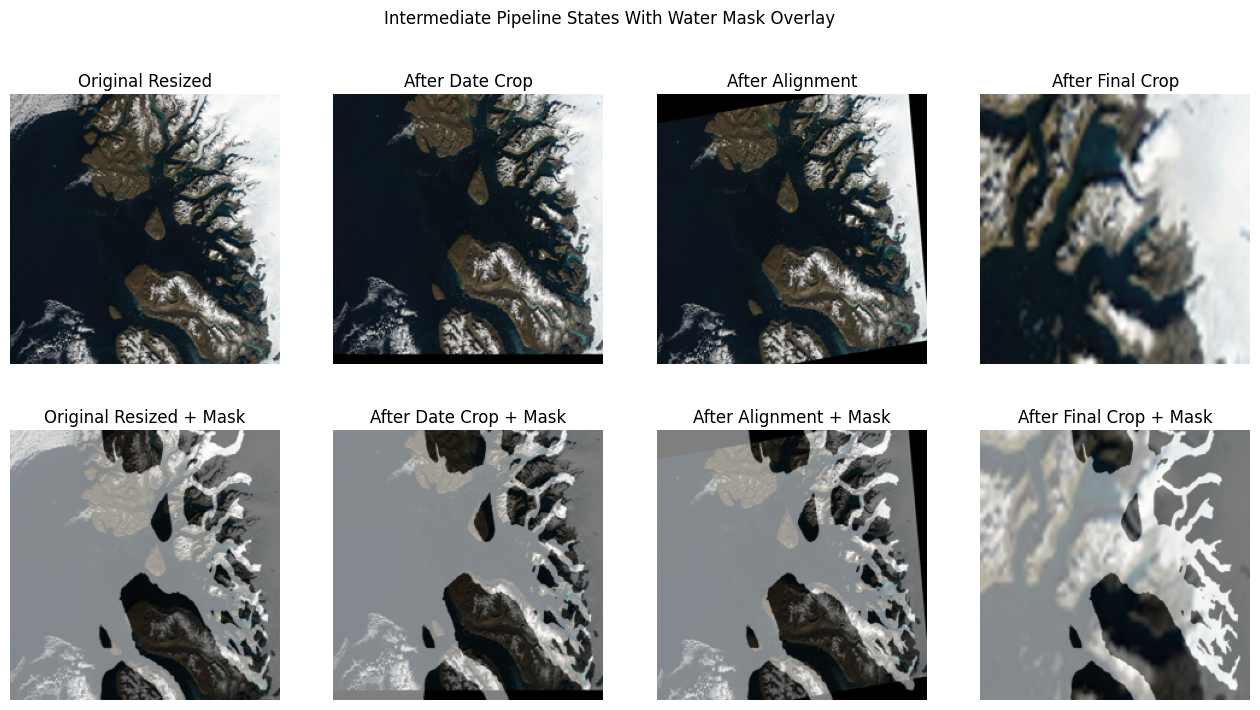

=== Building DataFrames from TRAIN_IN ===
=== Building TF Datasets (in memory pipeline) ===
=== Train Cloud Model ===
Epoch 1/30


KeyboardInterrupt: 